# Time Series Analysis — Complete Guide

**A comprehensive notebook covering theory, math, and Python code for every core topic in Time Series Analysis.**

---

**Table of Contents**
1. Introduction to Time Series
2. Time Series Data Handling (Python)
3. Exploratory Analysis & Visualization
4. Stationarity — The Foundation
5. Autocorrelation & Partial Autocorrelation
6. Smoothing Techniques (Family 1)
7. Classical Forecasting Models — AR, MA, ARMA, ARIMA, SARIMA (Family 2)
8. Curve-Fitting / Additive Models — Prophet, VAR (Family 3)
9. Machine Learning Models — Random Forest, XGBoost (Family 4)
10. Deep Learning — Sequential Modeling with LSTM (Family 5)
11. Model Evaluation & Validation — Across All 5 Families
12. Summary

In [2]:
# Install required packages (run once)
%pip install -q pandas numpy matplotlib seaborn statsmodels scikit-learn pmdarima prophet xgboost torch

import warnings
warnings.filterwarnings('ignore')

# --- Data Science & Visualization ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import lag_plot

# --- Statistical Modeling (statsmodels) ---
from statsmodels.datasets import co2
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.api import VAR

# --- ML Models ---
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

# --- Time Series Specialized ---
import pmdarima as pm
from prophet import Prophet

# --- Deep Learning (PyTorch) ---
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# --- Plot Settings ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print("All packages loaded successfully!")

Note: you may need to restart the kernel to use updated packages.
All packages loaded successfully!


# 1. Introduction to Time Series

---


## 1.1 What is a Time Series?

A **time series** is a sequence of data points collected or recorded at successive, equally spaced points in time.

Mathematically, a time series is a set of observations:

$$\{y_t : t = 1, 2, 3, \ldots, T\}$$

where $y_t$ is the value at time $t$, and $T$ is the total number of observations.

## 1.2 Components of a Time Series

Every time series can be decomposed into four components:

$$y_t = T_t + S_t + C_t + \epsilon_t \quad \text{(Additive)}$$

$$y_t = T_t \times S_t \times C_t \times \epsilon_t \quad \text{(Multiplicative)}$$

| Component | Symbol | Description |
|---|---|---|
| **Trend** | $T_t$ | Long-term increase or decrease |
| **Seasonality** | $S_t$ | Regular, fixed-period patterns (e.g., monthly, weekly) |
| **Cyclicity** | $C_t$ | Long-term oscillations without fixed period (business cycles) |
| **Noise / Irregularity** | $\epsilon_t$ | Random, unpredictable fluctuations |


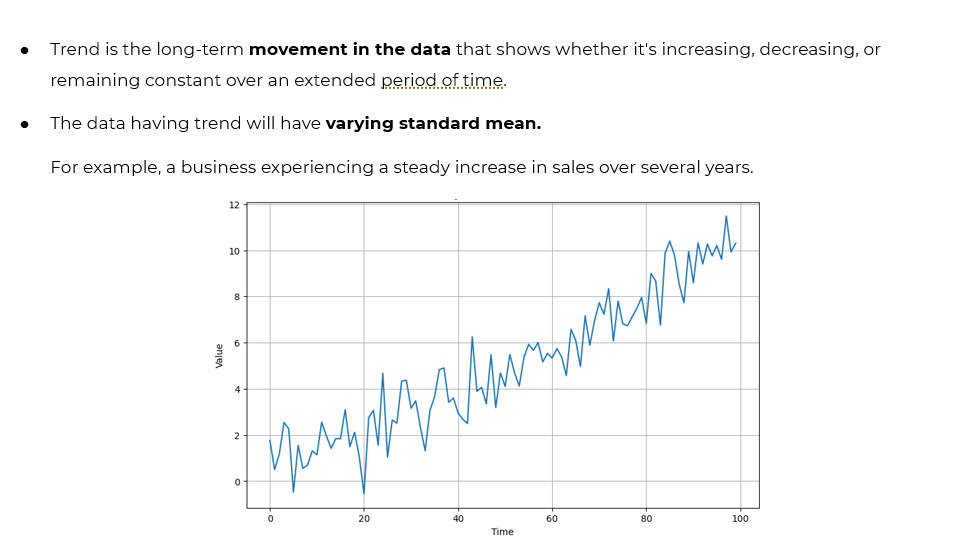
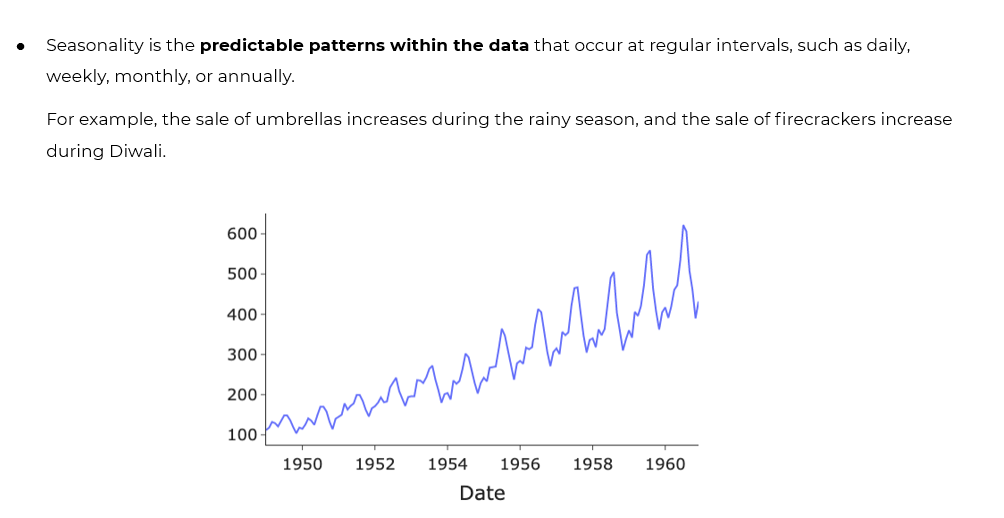
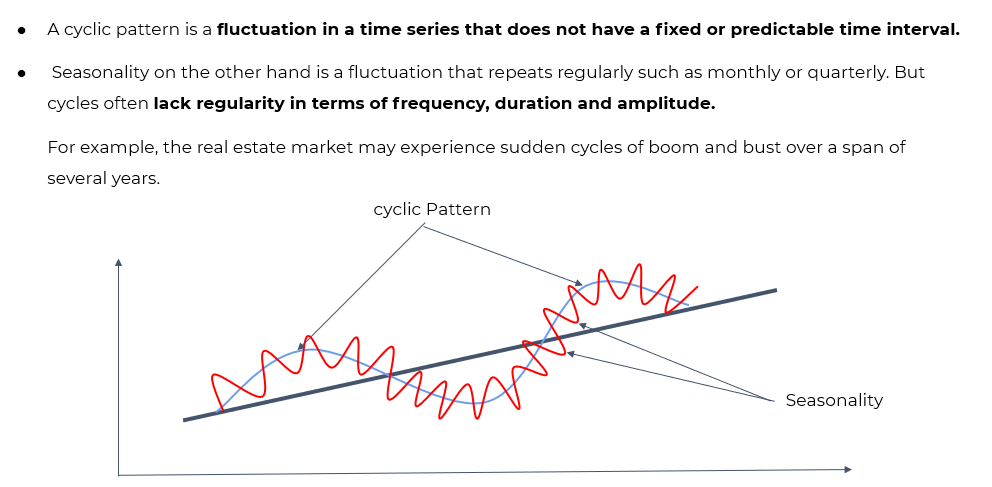


### When to use Additive vs Multiplicative?
- **Additive**: When seasonal fluctuations are roughly constant regardless of the level of the series
- **Multiplicative**: When seasonal fluctuations grow proportionally with the level of the series

In [3]:
# 1.3 Example: Visualizing a Time Series and its Components

from statsmodels.datasets import co2
from statsmodels.tsa.seasonal import seasonal_decompose

# Load Mauna Loa CO2 dataset
data = co2.load().data
data = data.ffill()  # fill missing values
print(f"Dataset shape: {data.shape}")
print(f"Date range: {data.index[0]} to {data.index[-1]}")
data.head(10)

Dataset shape: (2284, 1)
Date range: 1958-03-29 00:00:00 to 2001-12-29 00:00:00


,co2
1958-03-29,316.1
1958-04-05,317.3
1958-04-12,317.6
1958-04-19,317.5
1958-04-26,316.4
1958-05-03,316.9
1958-05-10,316.9
1958-05-17,317.5
1958-05-24,317.9
1958-05-31,317.9


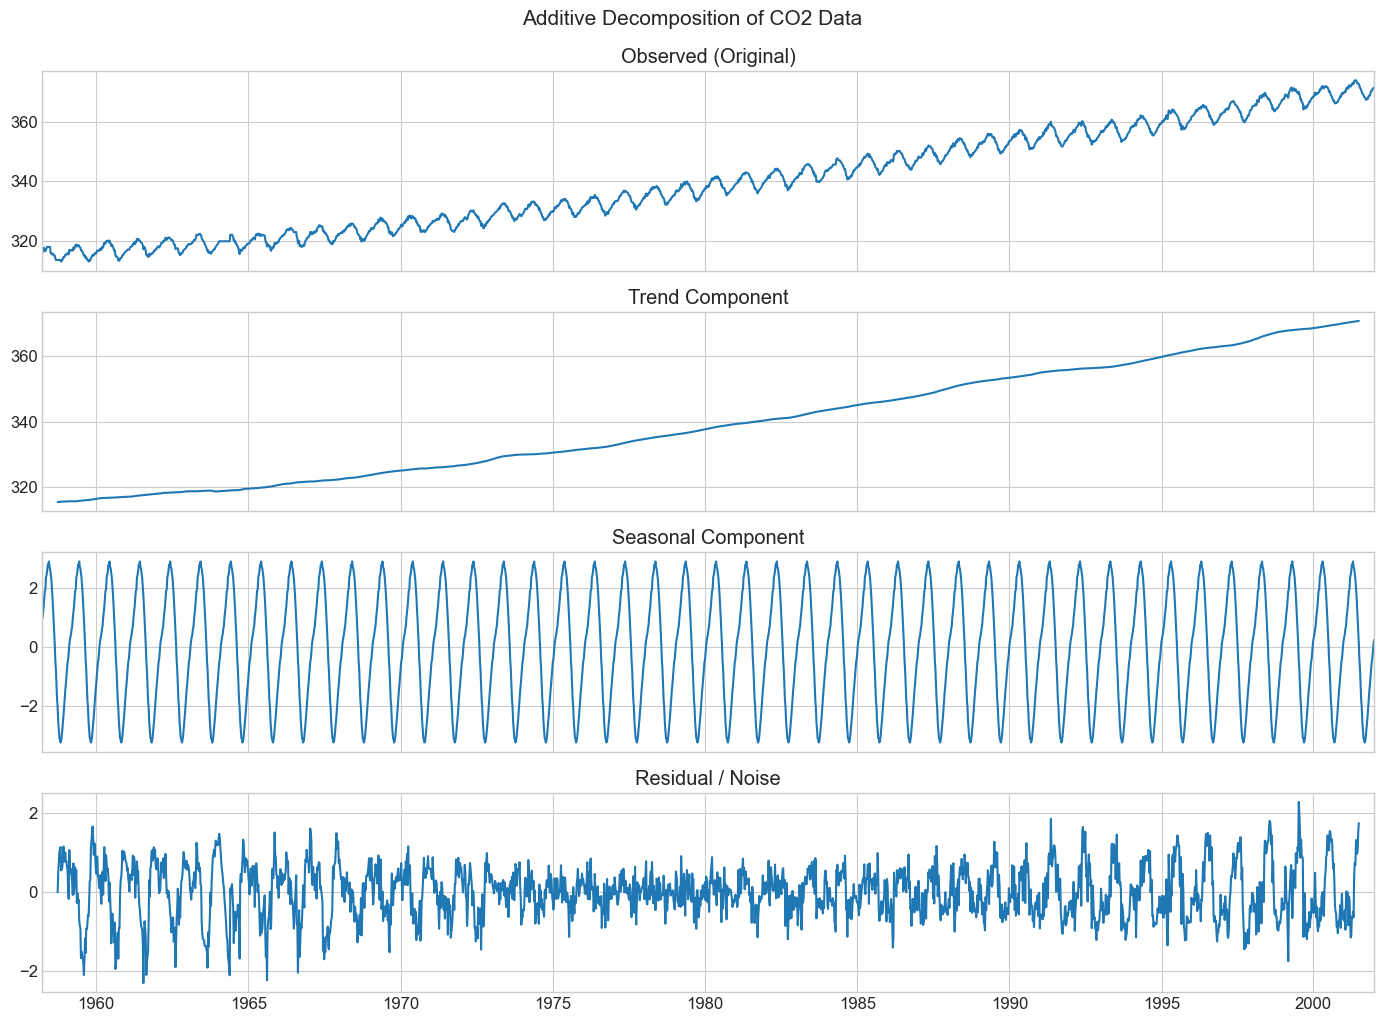

In [4]:
# Decompose into Trend, Seasonality, and Residual
result = seasonal_decompose(data['co2'], model='additive', period=52)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
result.observed.plot(ax=axes[0], title='Observed (Original)')
result.trend.plot(ax=axes[1], title='Trend Component')
result.seasonal.plot(ax=axes[2], title='Seasonal Component')
result.resid.plot(ax=axes[3], title='Residual / Noise')
plt.tight_layout()
plt.suptitle('Additive Decomposition of CO2 Data', y=1.02, fontsize=15)
plt.show()

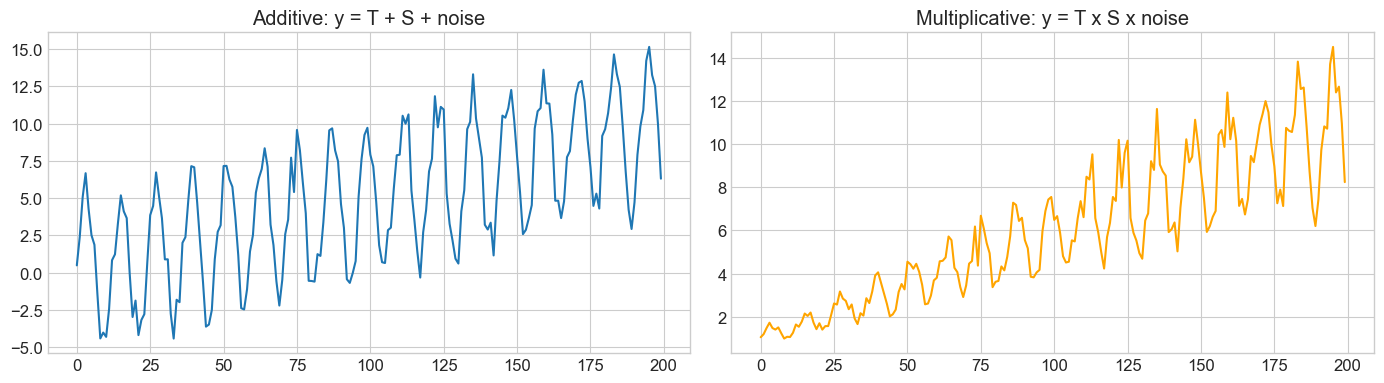

In [5]:
# 1.4 Example: Synthetic Time Series with known components

np.random.seed(42)
t = np.arange(0, 200)

trend = 0.05 * t                               # Linear trend
seasonality = 5 * np.sin(2 * np.pi * t / 12)   # 12-period seasonality
noise = np.random.normal(0, 1, 200)             # Random noise
y_additive = trend + seasonality + noise
y_multiplicative = (1 + trend) * (1 + 0.3 * np.sin(2 * np.pi * t / 12)) * (1 + 0.1 * noise)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(t, y_additive)
axes[0].set_title('Additive: y = T + S + noise')
axes[1].plot(t, y_multiplicative, color='orange')
axes[1].set_title('Multiplicative: y = T x S x noise')
plt.tight_layout()
plt.show()

## 1.5 The Five Families of Time Series Methods

Every forecasting method you'll encounter falls into one of these five families.

---

### Family 1 — Smoothing Methods (SES, Holt's, Holt-Winters)

**Philosophy:** "Track the pattern as it evolves using weighted averages."

- No math model of the data-generating process — just adaptively follow the level, trend, and season
- Parameters (α, β, γ) control how fast to react to new data
- No stationarity required, no preprocessing
- Output: point forecasts only (no proper confidence intervals)
- Works with very little data (even 1 year of monthly data)

**Analogy:** Driving by looking at the road — "I see the road curving right, so I'll steer right."

---

### Family 2 — Classical Statistical Models (AR, MA, ARMA, ARIMA, SARIMA)

**Philosophy:** "The data follows a mathematical equation — find that equation."

- Assumes each value is a function of past values + past errors: $y_t = \phi y_{t-1} + \theta \varepsilon_{t-1} + \varepsilon_t$
- Requires stationary data (must difference and/or log-transform first)
- Output: point forecasts + confidence intervals + residual diagnostics + AIC/BIC for model comparison
- Needs more data (2+ seasonal cycles for SARIMA)
- Rigorous — you can test if the model captured everything (Ljung-Box test on residuals)

**Analogy:** Driving by building a physics model of the car — "Given road curvature, speed, and friction coefficient, the optimal steering angle is 12.4°."

---

### Family 3 — Curve-Fitting / Additive Models (Prophet, BATS, TBATS)

**Philosophy:** "Decompose the series into smooth curves for trend, seasonality, and holidays — then add them up."

- Prophet fits: $y(t) = g(t) + s(t) + h(t) + \varepsilon_t$ where $g$ = piecewise linear/logistic trend, $s$ = Fourier seasonality (sine/cosine waves), $h$ = holiday effects
- Built specifically FOR time series — it *knows* about trend, seasonality, holidays
- Handles multiple seasonalities natively (daily + weekly + yearly)
- Handles missing data and outliers gracefully
- No stationarity needed, no manual preprocessing
- Gives confidence intervals (via Bayesian posterior sampling)
- Automatically detects changepoints (where the trend shifts)

**Analogy:** Driving with a GPS designed for this specific road — it knows where the curves are, where the speed bumps are (holidays), and adjusts the route accordingly.

---

### Family 4 — Machine Learning (XGBoost, LightGBM, Random Forest)

**Philosophy:** "Turn the time series into a table of features and treat it as a regular regression problem."

- Has **zero concept of time** — you manually create features: lag_1, lag_12, rolling_mean_7, month, day_of_week, is_holiday, temperature, etc.
- The model just sees rows and columns — it doesn't know or care that the data came from a time series
- Extremely flexible — can incorporate any external variable (weather, promotions, competitor prices) as just another column
- No stationarity needed
- No confidence intervals (but you can approximate with quantile regression)
- Feature engineering is everything — the model is only as good as the features you create

**Analogy:** Driving with Waze — it doesn't understand physics or road design. It just learned from millions of past trips that "at this location, at this time, in this weather, people slow down." Pure pattern matching from tabular data.

---

### Family 5 — Deep Learning (LSTM, GRU, Transformer, Temporal Fusion Transformer)

**Philosophy:** "Feed raw sequences to a neural network — let it learn the temporal patterns itself."

- You feed in a window of raw past values; the network learns what matters
- No manual feature engineering — the architecture (memory cells in LSTM, attention in Transformers) discovers temporal dependencies automatically
- Can learn across **many related series simultaneously** (e.g., sales of 10,000 products together — patterns in one product help predict another)
- Data hungry — needs thousands+ of data points to train well, often requires GPU
- Least interpretable — black box

**Analogy:** A self-driving car — it learned from millions of hours of video and sensor data. It drives well, but can't explain why it turned left. You just trust the neural network.

---

### Side-by-Side Comparison

| | Smoothing | Classical (ARIMA) | Curve-Fitting (Prophet) | ML (XGBoost) | Deep Learning (LSTM, Transformer) |
|---|---|---|---|---|---|
| **Core idea** | Weighted averages | Stochastic process equation | Decompose into smooth curves | Tabular regression on engineered features | Sequence-to-sequence neural networks |
| **Knows it's time series?** | Yes | Yes | Yes | No — just sees rows & columns | Yes — architecture is sequential |
| **Stationarity needed?** | No | Yes | No | No | No |
| **Feature engineering** | None | None (pick p,d,q) | None (auto-detects) | Critical — you build all features | None — network learns them |
| **Confidence intervals** | No | Yes | Yes (Bayesian) | No (approximate only) | Some (e.g., TFT) |
| **Residual diagnostics** | No | Yes (Ljung-Box, ACF) | Limited | No | No |
| **Handles holidays** | No | No | Yes (natively) | Yes (as a feature column) | Can learn if encoded |
| **Multiple seasonalities** | No (one period) | No (one period) | Yes (daily + weekly + yearly) | Yes (as feature columns) | Yes |
| **External variables** | No | SARIMAX can | Yes (regressors) | Yes (naturally — just add columns) | Yes |
| **Missing data** | Breaks | Breaks | Handles it | Needs imputation | Needs imputation |
| **Data needed** | Little (1 year OK) | Moderate (2+ cycles) | Moderate (hundreds) | Moderate (hundreds) | Lots (thousands+, GPU) |
| **Many related series** | Each separately | Each separately | Each separately | Each separately | Learns across all together |
| **Interpretability** | High | High | Medium | Medium (SHAP values) | Low (black box) |
| **Setup effort** | 2 min | 20 min | 5 min | 30 min (feature engineering) | Hours (architecture, GPU) |

### NOTE — Holt-Winters and Prophet Both "Decompose" — But Differently

Both break the series into trend + seasonality, but the approach is completely different:

| | Holt-Winters | Prophet |
|---|---|---|
| **How it decomposes** | Adaptively tracks level, trend, season with exponentially weighted averages — updates step by step as new data arrives | Fits smooth mathematical curves (piecewise linear trend + Fourier sine/cosine seasonality + holiday indicators) to the entire dataset at once |
| **Additive vs Multiplicative** | Built-in: `seasonal='add'` or `seasonal='mul'` — handles multiplicative natively | Additive only by default (can log-transform for multiplicative) |
| **Number of seasonal periods** | **One** (e.g., 12 months) | **Multiple** simultaneously (daily + weekly + yearly) |
| **Holidays** | Cannot handle | Built-in — pass a dataframe of holiday dates |
| **Changepoints** | Trend changes smoothly via $\beta$ | Auto-detects **abrupt** trend shifts (e.g., product launch, COVID) |
| **Missing data** | Breaks | Handles gracefully |
| **Confidence intervals** | No (or very crude) | Yes (Bayesian posterior sampling) |
| **One-liner** | "Track and update" — online/adaptive | "Fit smooth curves" — batch/curve-fitting |

**When HW still wins over Prophet:** Less than 2 years of data, simple single-season pattern, no holidays, need a quick 2-line forecast.

### When to Use What

```
Is the data clean with one seasonal pattern and < 1000 points?
├── YES → Smoothing (quick baseline) → SARIMA (if you need confidence intervals)
└── NO  →
    Multiple seasonalities or holidays?
    ├── YES, structured patterns  → Prophet (built for this)
    ├── YES, + external variables → XGBoost (add any column you want)
    └── 100K+ rows or many related series → Deep Learning (LSTM / Transformer)
```

# 2. Time Series Data Handling in Python

---
## 2.1 DateTime Parsing & Indexing

Pandas provides powerful datetime support. The key function is `pd.to_datetime()` and setting a `DatetimeIndex`.

**Key concepts:**
- `pd.to_datetime()` — parse strings to datetime
- `df.set_index()` — set datetime column as index
- `pd.date_range()` — create regular date sequences
- Frequency strings: `'D'` (daily), `'W'` (weekly), `'M'` (month-end), `'MS'` (month-start), `'Q'` (quarterly), `'Y'` (yearly)

## 2.2 Resampling & Frequency Conversion

**Downsampling** (higher to lower frequency): e.g., daily to monthly using `.resample('M').mean()`

**Upsampling** (lower to higher frequency): e.g., monthly to daily using `.resample('D').ffill()`

In [30]:
# Load the classic Air Passengers dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
df.columns = ['Passengers']
df.index.freq = 'MS'  # Set frequency to Month Start

print(f"Shape: {df.shape}")
print(f"Index type: {type(df.index)}")
print(f"Frequency: {df.index.freq}")
print(f"Date range: {df.index[0]} to {df.index[-1]}")
df.head()

Shape: (144, 1)
Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Frequency: <MonthBegin>
Date range: 1949-01-01 00:00:00 to 1960-12-01 00:00:00


,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


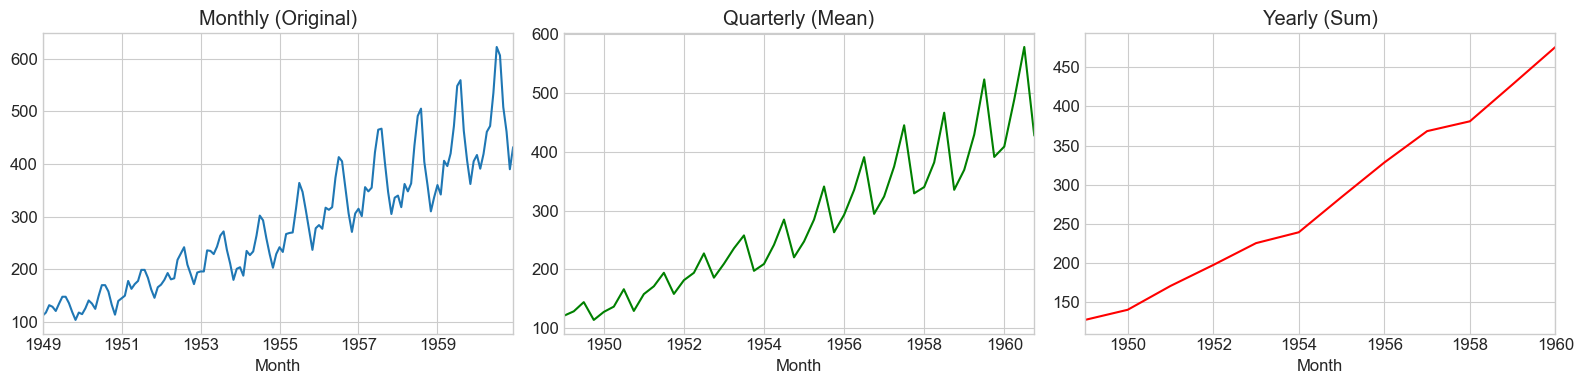

In [33]:


# Downsample: Monthly -> Quarterly (mean)
# Takes the 144 monthly data points and downsamples to quarterly by averaging every 3 months into one value. 
# QE = quarter-end
df_quarterly = df.resample('QE').mean()

# Downsample: Monthly -> Yearly (sum)
# Downsamples to yearly by summing all 12 months into one annual total. YE = year-end
df_yearly = df.resample('YE').mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df.plot(ax=axes[0], title='Monthly (Original)', legend=False)
df_quarterly.plot(ax=axes[1], title='Quarterly (Mean)', legend=False, color='green')
df_yearly.plot(ax=axes[2], title='Yearly (Sum)', legend=False, color='red')
plt.tight_layout()
plt.show()

## 2.3 Handling missing timestamps

Original (with gaps):
2023-01-01    10
2023-01-02    12
2023-01-04    15
2023-01-07    20
2023-01-08    22
dtype: int64

After reindex + linear interpolation:
2023-01-01    10.000000
2023-01-02    12.000000
2023-01-03    13.500000
2023-01-04    15.000000
2023-01-05    16.666667
2023-01-06    18.333333
2023-01-07    20.000000
2023-01-08    22.000000
Freq: D, dtype: float64


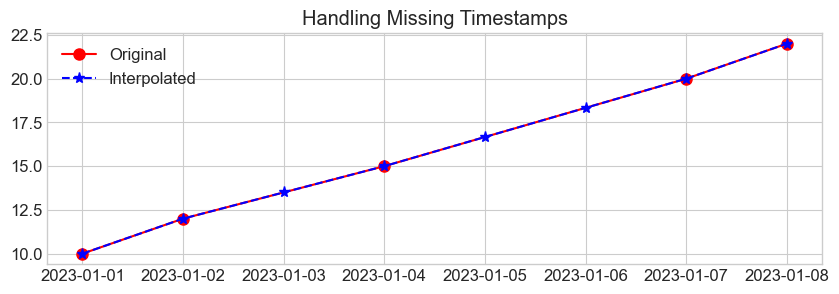

In [8]:


# Create data with gaps
dates = pd.to_datetime(['2023-01-01', '2023-01-02', '2023-01-04', '2023-01-07', '2023-01-08'])
values = [10, 12, 15, 20, 22]
ts = pd.Series(values, index=dates)

print("Original (with gaps):")
print(ts)

# Reindex to fill gaps, then interpolate:

# ts.reindex(full_range) — Creates a complete daily date range (Jan 1–8) and inserts NaN for the missing dates. Now the series has 8 entries instead of 5.

# .interpolate(method='linear') — Fills the NaN gaps by drawing a straight line between known points:

# Jan 3 gets ~13.5 (halfway between 12 and 15)
# Jan 5 gets ~16.67, Jan 6 gets ~18.33 (evenly spaced between 15 and 20)

full_range = pd.date_range(ts.index.min(), ts.index.max(), freq='D')
ts_full = ts.reindex(full_range)
ts_interpolated = ts_full.interpolate(method='linear')

print("\nAfter reindex + linear interpolation:")
print(ts_interpolated)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(ts.index, ts.values, 'ro-', label='Original', markersize=8)
ax.plot(ts_interpolated.index, ts_interpolated.values, 'b*--', label='Interpolated', markersize=8)
ax.legend()
ax.set_title('Handling Missing Timestamps')
plt.show()

### Other methiods to handle missing data in time series include:

In [9]:

# - Forward fill (ffill): Propagates last valid observation forward.
# - Backward fill (bfill): Propagates next valid observation backward.
# - Rolling Window (Moving Average): Smooths the series by averaging over a fixed window of past observations.Example: ts.fillna(ts.rolling(window=3, min_periods=1).mean())
# - Seasonal Fill (Same Period Last Cycle): Fills missing values using the value from the same period in the previous cycle (e.g., same month last year for monthly data). Example: ts.fillna(ts.shift(12))
# - Mean/Median/Mode imputation: Fills missing values with the overall mean, median, or mode of the series. Example: ts.fillna(ts.mean())
# - Exponential Weighted Fill: Gives more weight to recent values than a simple rolling mean.. Example: ts.fillna(ts.ewm(span=3, adjust=False).mean())

---
# 3. Exploratory Analysis & Visualization

Before modeling, we **must** visually inspect the data. Key plots:

1. **Line plot** — overall pattern
2. **Seasonal plot** — overlay same period across years
3. **Box plot by period** — distribution per month/quarter
4. **Rolling statistics** — moving mean & std to check stationarity visually
5. **Decomposition** — separate trend, seasonality, residual

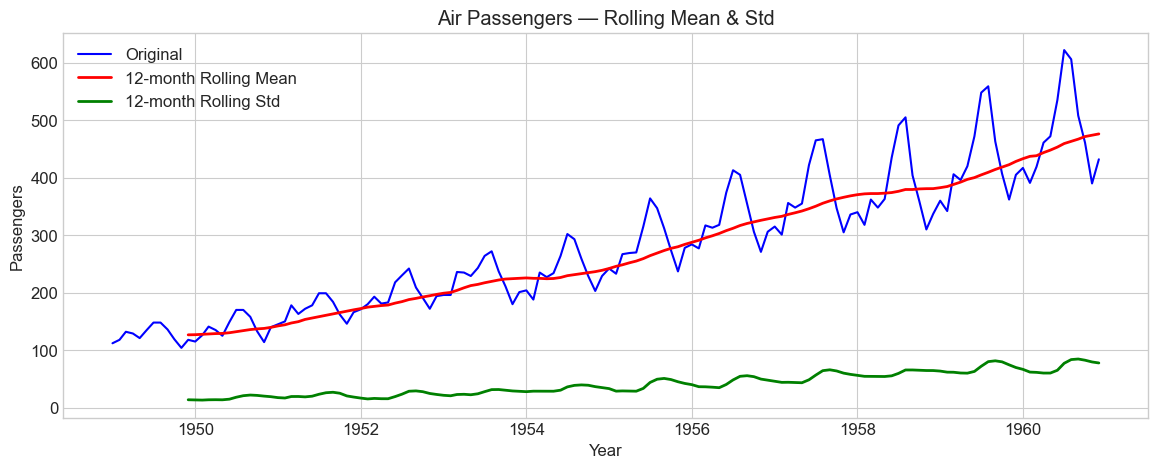

Observation: Both rolling mean and std are INCREASING -> Non-stationary series


In [10]:
# 3.1 Line plot with rolling statistics

rolling_mean = df['Passengers'].rolling(window=12).mean()
rolling_std = df['Passengers'].rolling(window=12).std()

plt.figure(figsize=(14, 5))
plt.plot(df['Passengers'], label='Original', color='blue')
plt.plot(rolling_mean, label='12-month Rolling Mean', color='red', linewidth=2)
plt.plot(rolling_std, label='12-month Rolling Std', color='green', linewidth=2)
plt.legend()
plt.title('Air Passengers — Rolling Mean & Std')
plt.xlabel('Year')
plt.ylabel('Passengers')
plt.show()

print("Observation: Both rolling mean and std are INCREASING -> Non-stationary series")

### Observations — 3.1 Rolling Statistics

- **Rolling Mean (red)** rises steadily from ~150 in 1949 to ~400 in 1960 — clear **upward trend**. The series is not fluctuating around a constant level.
- **Rolling Std (green)** also increases from ~20 to ~80 — the **variance is growing** over time. Monthly fluctuations in 1960 are much larger than in 1949.
- **Both increasing → the series is non-stationary** in both mean AND variance. This means:
  - We'll need **differencing** (to remove the trend) before fitting ARIMA
  - We'll need a **log transform** (to stabilize the growing variance) before differencing
  - Smoothing methods (Holt-Winters) and Prophet can handle this natively without preprocessing

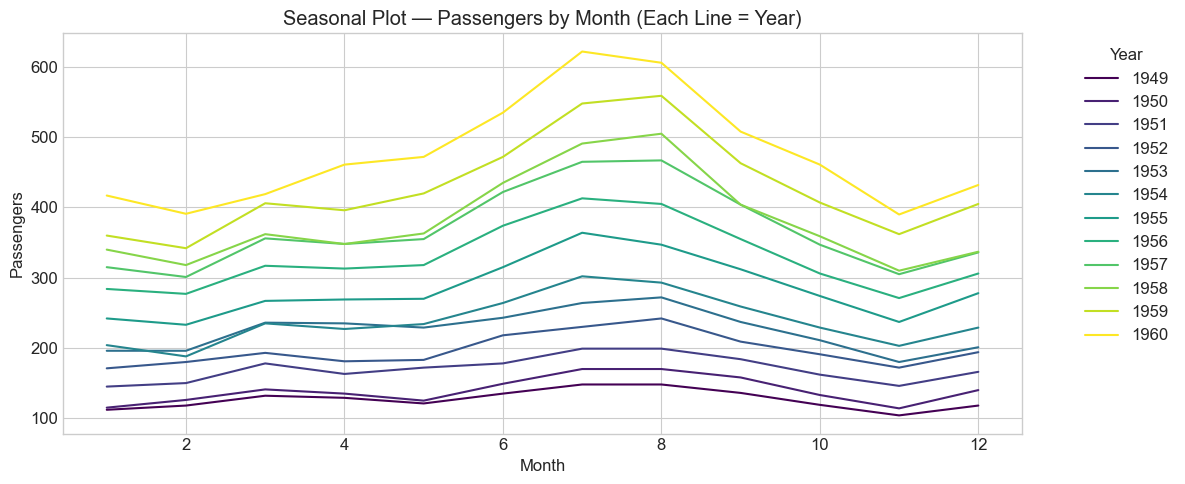

In [11]:
# 3.2 Seasonal plot — same month across different years

df_pivot = df.copy()
df_pivot['Year'] = df_pivot.index.year
df_pivot['Month'] = df_pivot.index.month

pivot = df_pivot.pivot(index='Month', columns='Year', values='Passengers')
pivot.plot(figsize=(12, 5), colormap='viridis')
plt.title('Seasonal Plot — Passengers by Month (Each Line = Year)')
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [45]:
np.var(df_pivot[df_pivot.Month == 1]['Passengers'])

9357.020833333334

In [42]:
np.var(df_pivot[df_pivot.Month == 7]['Passengers'])

22545.222222222223

In [40]:
df_pivot[df_pivot.Month == 7]

,Passengers,Year,Month
Month,,,
1949-07-01,148,1949,7
1950-07-01,170,1950,7
1951-07-01,199,1951,7
1952-07-01,230,1952,7
1953-07-01,264,1953,7
1954-07-01,302,1954,7
1955-07-01,364,1955,7
1956-07-01,413,1956,7
1957-07-01,465,1957,7


### Observations — 3.2 Seasonal Plot

- Each line represents one year. All 12 lines follow the **same shape**: dip in winter (months 1–3), rise in spring, peak in summer (months 7–8), and drop in fall.
- The shape is consistent every year — this confirms **strong yearly seasonality with period m=12**.
- The lines shift **upward** each year (1949 at the bottom, 1960 at the top) — this confirms the **upward trend** seen in 3.1.
- The **gap between lines widens** as we go from winter to summer — in 1949 the summer peak is ~150, but in 1960 it's ~600. This means the seasonal amplitude is **growing proportionally with the level** → **multiplicative seasonality**, not additive.
- **Implication for modeling:** Use `seasonal='mul'` in Holt-Winters, or apply `log()` before ARIMA to handle the multiplicative pattern.

> **NOTE — Why `seasonal='mul'` or `log()` ?**
>
> Multiplicative seasonality means the peaks grow with the level. Two ways to handle this:
>
> **Option 1 — Holt-Winters with `seasonal='mul'`:** Handles it natively. The forecast equation is $\hat{y} = (\ell + h \cdot b) \times s$ — it multiplies the seasonal factor, so if the base doubles, peaks automatically double too. No preprocessing needed.
>
> **Option 2 — ARIMA with `log()` first:** ARIMA only does addition internally — it can't multiply. The trick: $\log(T \times S) = \log(T) + \log(S)$. Taking the log converts multiplicative → additive. Fit ARIMA on `log(data)`, forecast in log space, then `exp()` back. That's why Section 7.9 uses `train_log = np.log(passengers)` and `np.exp(result.forecast(h))`.

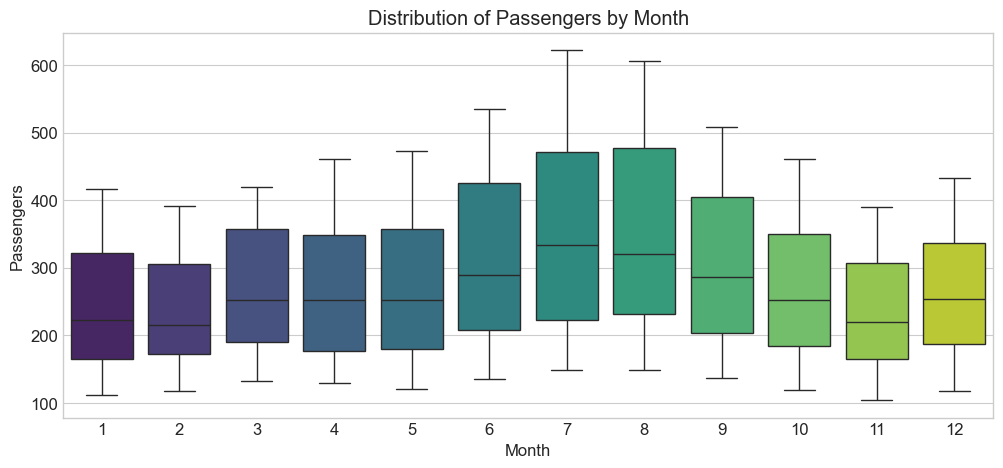

Observation: Clear seasonality — peak in months 7-8 (July-August)


In [13]:
# 3.3 Box plot by month — distribution across months

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df_pivot, x='Month', y='Passengers', ax=ax, palette='viridis')
plt.title('Distribution of Passengers by Month')
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.show()

print("Observation: Clear seasonality — peak in months 7-8 (July-August)")

### Observations — 3.3 Box Plot by Month

- **Peak months: July (7) and August (8)** — highest median passengers, widest boxes. These are summer travel months.
- **Trough months: November (11) and February (2)** — lowest median, narrow boxes. Off-season for air travel.
- **Box height increases from month 1 to month 7** — the IQR (interquartile range) grows as passenger counts grow, confirming the **multiplicative variance** pattern.
- **Outliers (dots above whiskers):** Most visible in peak months — some years had exceptionally high summer traffic. These could be due to post-war travel boom acceleration.
- **Practical insight:** If you're forecasting airline capacity, you need ~2–3x more seats in July vs February. The gap between peak and trough is not constant — it **widens each year** (multiplicative).
- **For modeling:** The growing spread in the boxes across months means the residual variance depends on the level → another signal that **multiplicative decomposition** or **log transform** is needed.

--- 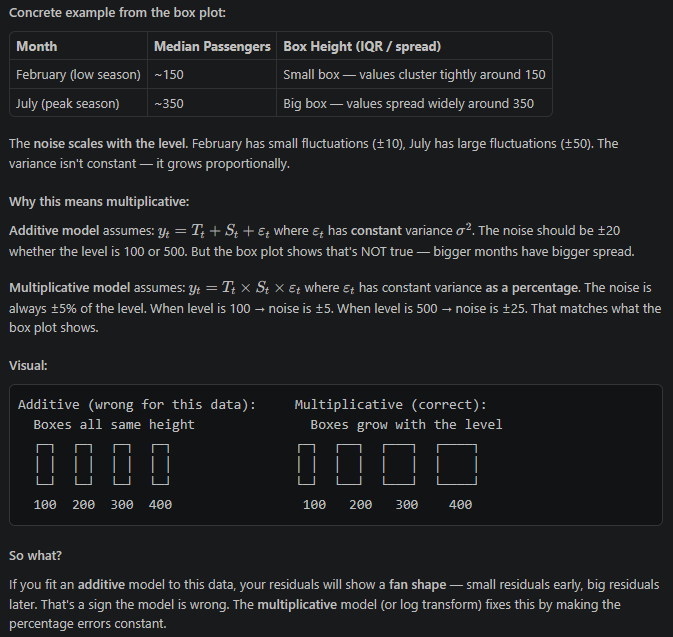

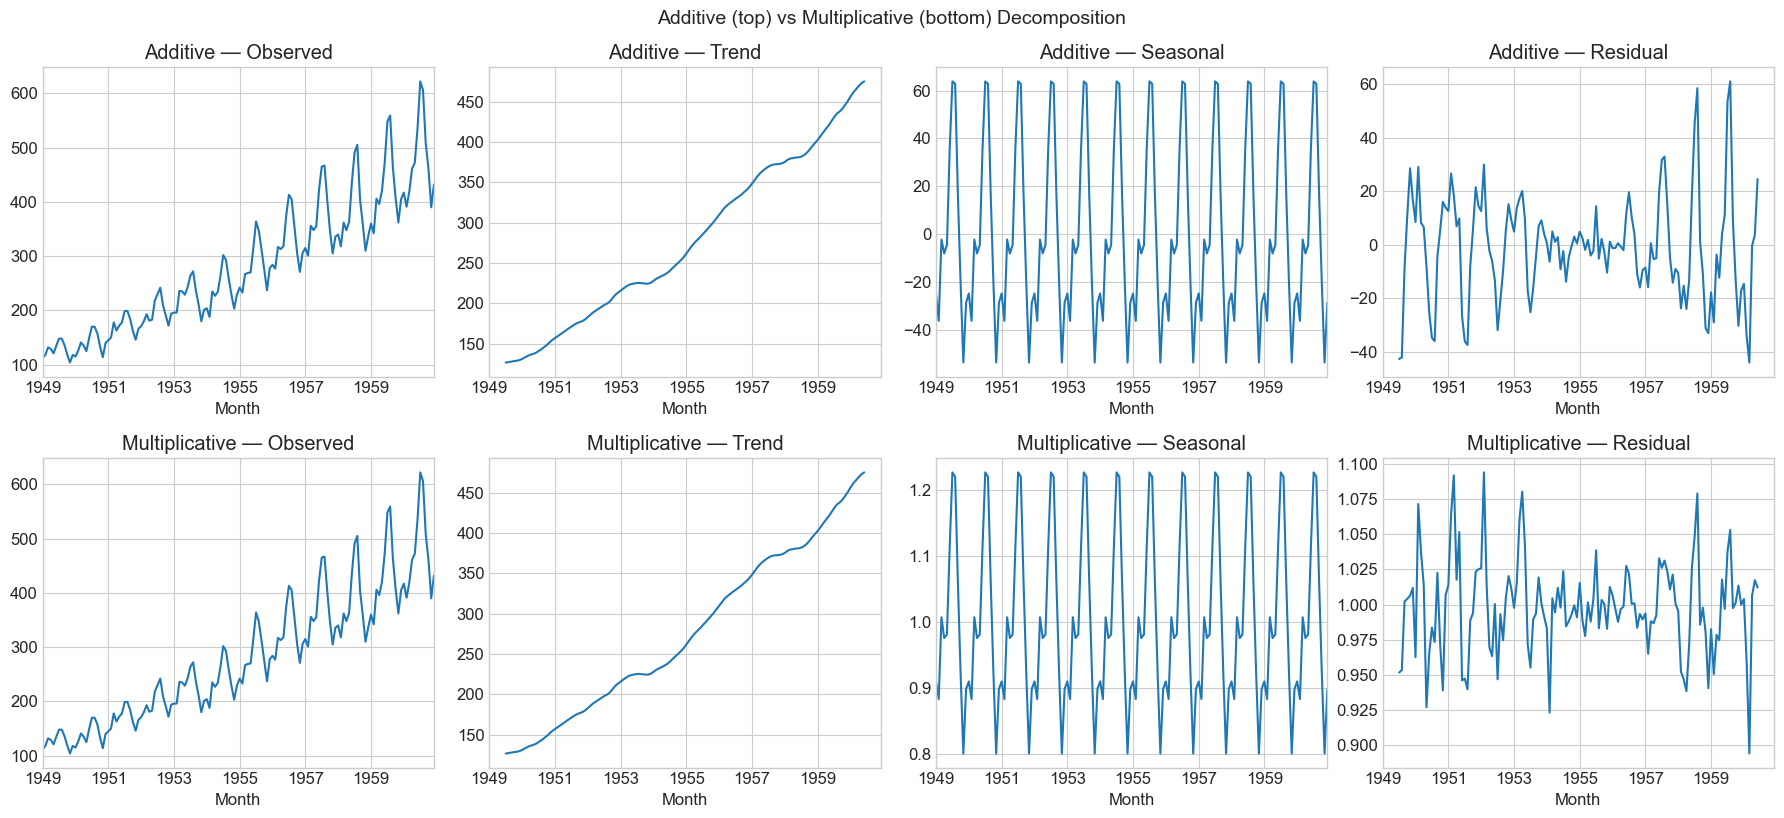

For Air Passengers: Multiplicative is better because seasonal swings grow with the level.


In [14]:
# 3.4 Additive vs Multiplicative Decomposition

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, model in enumerate(['additive', 'multiplicative']):
    result = seasonal_decompose(df['Passengers'], model=model, period=12)
    result.observed.plot(ax=axes[i][0])
    axes[i][0].set_title(f'{model.title()} — Observed')
    result.trend.plot(ax=axes[i][1])
    axes[i][1].set_title(f'{model.title()} — Trend')
    result.seasonal.plot(ax=axes[i][2])
    axes[i][2].set_title(f'{model.title()} — Seasonal')
    result.resid.plot(ax=axes[i][3])
    axes[i][3].set_title(f'{model.title()} — Residual')

plt.tight_layout()
plt.suptitle('Additive (top) vs Multiplicative (bottom) Decomposition', y=1.02, fontsize=14)
plt.show()

print("For Air Passengers: Multiplicative is better because seasonal swings grow with the level.")

In [34]:
df

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


### Observations — 3.4 Additive vs Multiplicative Decomposition

**Additive (top row):**
- **Trend:** Smooth upward curve from ~100 to ~400 — captures the long-term growth correctly.
- **Seasonal:** Fixed-amplitude oscillations — same height peaks every year (~±20). This is wrong — the real peaks grow over time.
- **Residual:** Shows a clear **fan-shaped pattern** — residuals are small early on and grow larger later. This means the additive model is leaving systematic structure in the residuals. **Bad sign — the model hasn't captured the growing variance.**

**Multiplicative (bottom row):**
- **Trend:** Same smooth upward curve.
- **Seasonal:** Oscillations as a **ratio** (e.g., 1.2 = 20% above base). The amplitude stays constant as a percentage — this correctly captures that July is always ~20% above baseline, regardless of whether the baseline is 100 or 400.
- **Residual:** Much more **random and uniform** — no fan shape, no obvious pattern. This means the multiplicative model captured the structure well.

**Verdict:** Multiplicative decomposition is clearly better for Air Passengers because:
1. The seasonal pattern grows proportionally with the level (summer peak is 30 passengers in 1949 but 120 in 1960)
2. The multiplicative residuals are closer to white noise
3. The additive residuals still have structure → the model missed something

**Rule of thumb:** If the seasonal swings grow as the series level grows → multiplicative. If they stay roughly the same height → additive.

# 4. Stationarity — The Foundation

---


## 4.1 What is Stationarity?

A time series is **stationary** if its statistical properties (mean, variance, autocorrelation) do not change over time.

### Strict (Strong) Stationarity
The joint distribution of $(y_{t_1}, y_{t_2}, \ldots, y_{t_k})$ is the same as $(y_{t_1+h}, y_{t_2+h}, \ldots, y_{t_k+h})$ for all $h$.

Example: If you grab any 30-day window from your data, the histogram should look exactly the same regardless of which 30 days you pick.

### Weak (Second-Order) Stationarity
A more practical definition — a process is weakly stationary if:

1. **Constant mean:** $E[y_t] = \mu$ for all $t$
2. **Constant variance:** $\text{Var}(y_t) = \sigma^2$ for all $t$
3. **Covariance depends only on lag:** $\text{Cov}(y_t, y_{t+h}) = \gamma(h)$, depends only on $h$, not $t$

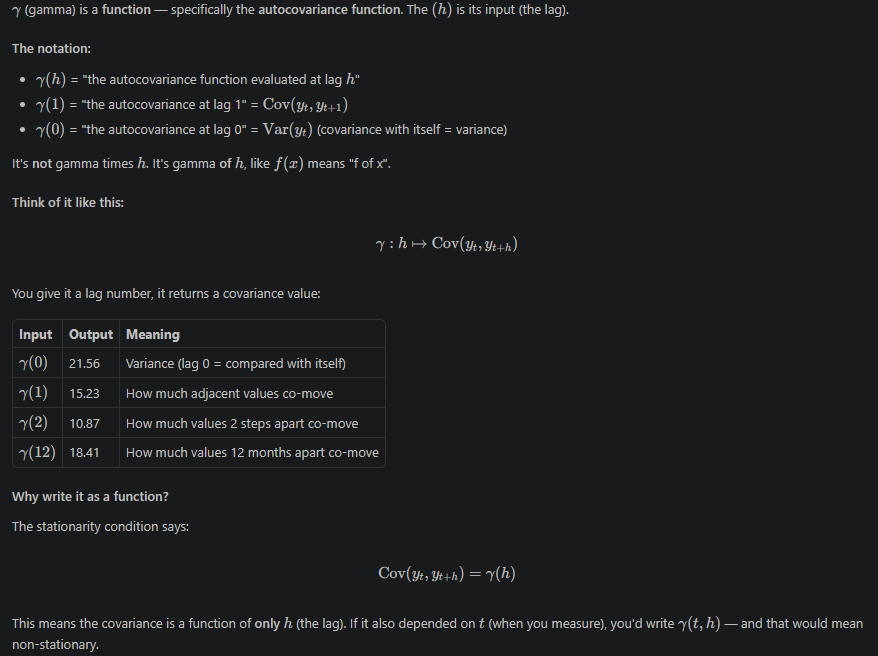

Writing γ(h) with just one argument is shorthand for: "this value depends only on the gap, not on the position in time."

## 4.2 Why Does Stationarity Matter?

Most classical time series models (AR, MA, ARMA, ARIMA) **assume stationarity**. Here's why — and what goes wrong without it:

### 4.2.1 Models learn ONE set of rules — stationarity guarantees those rules don't change

When you fit an AR(1) model $y_t = c + \phi y_{t-1} + \epsilon_t$, you're estimating a single $\phi$ from the data. This $\phi$ captures the relationship "how much does yesterday's value predict today's?"

- **Stationary data:** This relationship is the **same everywhere** in the series. $\phi$ estimated from 2020 data works equally well for 2023 data. The model is valid.
- **Non-stationary data:** The relationship **changes over time**. The $\phi$ you estimated is an average of a changing relationship — it doesn't accurately represent any specific time period. Your forecasts will be wrong.

**Analogy:** Imagine fitting a line $y = mx + b$ to data where the slope keeps changing. You'd get some average slope that doesn't match any part of the data.

### 4.2.2 Mean and variance must be constant for parameter estimation to work

AR/MA models estimate parameters using autocorrelation $\rho_k$. Recall:

$$\rho_k = \frac{\text{Cov}(y_t, y_{t-k})}{\text{Var}(y_t)}$$

This formula **assumes** $\text{Var}(y_t)$ is the same everywhere. If variance is growing (like in Air Passengers), then:
- $\rho_k$ computed from the first half of the data ≠ $\rho_k$ from the second half
- ACF/PACF plots become unreliable → you pick wrong $p$ and $q$ → wrong model

### 4.2.3 Non-stationary data causes "spurious regression"

Two completely unrelated non-stationary series (e.g., global temperature and number of pirates) can show a very high correlation ($R^2 > 0.9$) simply because both have trends. The model thinks there's a strong relationship when there's actually none. With stationary data, this problem disappears — only genuine correlations survive.

### 4.2.4 Forecasts explode without stationarity

In a stationary AR(1) with $|\phi| < 1$, forecasts naturally **decay back to the mean** — they're stable and bounded. In a non-stationary series (e.g., random walk where $\phi = 1$), forecast uncertainty **grows without limit** — the confidence interval widens to infinity. The forecast becomes useless.

### 4.2.5 Summary — What breaks without stationarity

| What breaks | Why | Example |
|---|---|---|
| **Parameter estimates** | $\phi$ and $\theta$ are averages of a changing relationship — meaningless | AR(1) on trending stock prices gives unstable $\phi$ |
| **ACF / PACF** | Autocorrelation formula assumes constant variance | ACF of Air Passengers shows slow decay because of trend, not because it's AR |
| **Model selection** | Wrong ACF/PACF → wrong $p$, $q$ | You might pick AR(5) when the real issue is just a trend |
| **Forecasts** | Predictions diverge, confidence intervals blow up | Random walk forecast: "next year is anywhere between 0 and infinity" |
| **Hypothesis tests** | t-tests and F-tests assume stationary errors; with non-stationarity, p-values are wrong | Spurious regression: unrelated series appear significantly correlated |

## 4.3 Statistical Tests

### Augmented Dickey-Fuller (ADF) Test

Tests the null hypothesis that a **unit root** is present (i.e., series is non-stationary).

The model tested is:

$$\Delta y_t = \alpha + \beta t + \gamma y_{t-1} + \sum_{i=1}^{p} \delta_i \Delta y_{t-i} + \epsilon_t$$

- $H_0$: $\gamma = 0$ — Unit root exists — **Non-stationary**
- $H_1$: $\gamma < 0$ — No unit root — **Stationary**

**Decision:** If p-value < 0.05, reject $H_0$ — Series is stationary.

### KPSS Test

Tests the **opposite** hypothesis:

- $H_0$: Series is **stationary**
- $H_1$: Series is **non-stationary**

**Decision:** If p-value < 0.05, reject $H_0$ — Series is non-stationary.

**Best practice**: Use both ADF and KPSS together for confirmation.

| ADF Result | KPSS Result | Conclusion |
|---|---|---|
| Stationary | Stationary | Confirmed stationary |
| Non-stationary | Non-stationary | Confirmed non-stationary |
| Stationary | Non-stationary | Trend-stationary (needs detrending) |
| Non-stationary | Stationary | Difference-stationary (needs differencing) |

## 4.4 Techniques to Achieve Stationarity

1. **Differencing**: $y'_t = y_t - y_{t-1}$ (first-order differencing)
2. **Second-order differencing**: $y''_t = y'_t - y'_{t-1}$
3. **Log transform**: $y'_t = \log(y_t)$ — stabilizes variance
4. **Log + Differencing**: $y'_t = \log(y_t) - \log(y_{t-1})$ (approx. returns / growth rate)
5. **Detrending**: Subtract a fitted trend (e.g., linear regression)

In [15]:
# 4.5 Stationarity tests on Air Passengers

from statsmodels.tsa.stattools import adfuller, kpss

def stationarity_report(series, name='Series'):
    """Run ADF and KPSS tests and print a clear report."""
    
    # ADF Test
    adf_result = adfuller(series.dropna(), autolag='AIC')
    adf_stat, adf_p = adf_result[0], adf_result[1]
    
    # KPSS Test
    kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
    kpss_stat, kpss_p = kpss_result[0], kpss_result[1]
    
    print(f"{'='*50}")
    print(f" Stationarity Report: {name}")
    print(f"{'='*50}")
    print(f" ADF Test Statistic:  {adf_stat:.4f}")
    print(f" ADF p-value:         {adf_p:.6f}")
    print(f" ADF Conclusion:      {'Stationary' if adf_p < 0.05 else 'Non-Stationary'}")
    print(f"{'_'*50}")
    print(f" KPSS Test Statistic: {kpss_stat:.4f}")
    print(f" KPSS p-value:        {kpss_p:.4f}")
    print(f" KPSS Conclusion:     {'Stationary' if kpss_p >= 0.05 else 'Non-Stationary'}")
    print(f"{'='*50}\n")

# Test the original series
stationarity_report(df['Passengers'], 'Original Air Passengers')

 Stationarity Report: Original Air Passengers
 ADF Test Statistic:  0.8154
 ADF p-value:         0.991880
 ADF Conclusion:      Non-Stationary
__________________________________________________
 KPSS Test Statistic: 1.6513
 KPSS p-value:        0.0100
 KPSS Conclusion:     Non-Stationary



### Interpretation — 4.5 Stationarity Tests on Original Air Passengers

**ADF Test:**
- p-value ≈ 0.99 (way above 0.05) → **fail to reject** $H_0$ (unit root exists) → **Non-Stationary**
- The positive ADF statistic confirms the series has strong trend/growth — far from anything stationary

**KPSS Test:**
- p-value ≈ 0.01 (below 0.05) → **reject** $H_0$ (stationarity) → **Non-Stationary**
- Confirms the mean is not constant over time

**Both tests agree: the original Air Passengers series is non-stationary.**

| Test | Null Hypothesis | Result | Meaning |
|---|---|---|---|
| ADF | Series has a unit root (non-stationary) | p=0.99 → fail to reject | Can't conclude stationarity — trend dominates |
| KPSS | Series is stationary | p=0.01 → reject | Stationarity rejected — mean and variance are changing |

**Why it's non-stationary** (connecting to Section 3):
- The rolling mean in 3.1 rises from ~150 to ~400 → **mean is not constant**
- The rolling std grows from ~20 to ~80 → **variance is not constant**
- The ADF/KPSS tests just **confirm statistically** what we saw visually

**What to do next:** Apply `log()` (to stabilize variance) + differencing (to remove trend) → then re-run these tests until both say "stationary." That's exactly what Section 4.6 does.

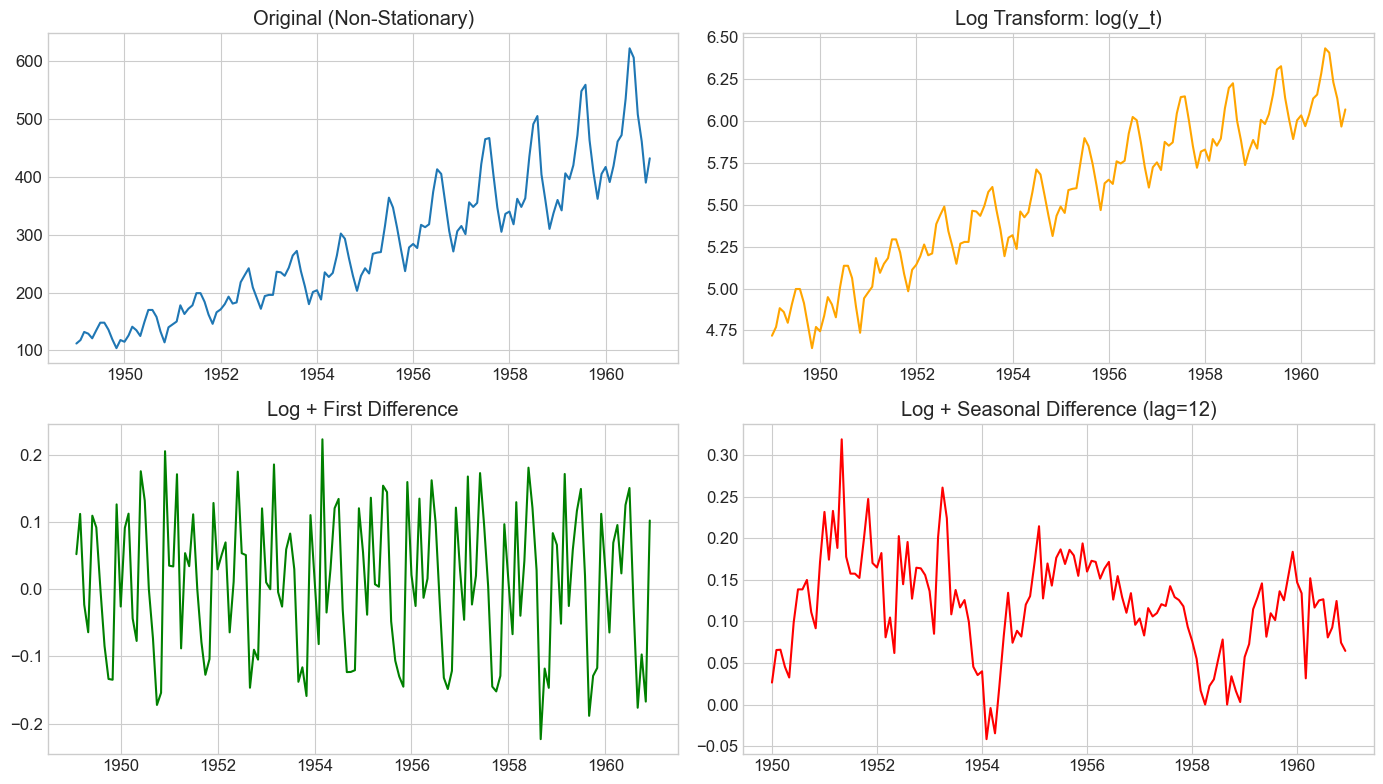

 Stationarity Report: Log Transform
 ADF Test Statistic:  -1.7170
 ADF p-value:         0.422367
 ADF Conclusion:      Non-Stationary
__________________________________________________
 KPSS Test Statistic: 1.6687
 KPSS p-value:        0.0100
 KPSS Conclusion:     Non-Stationary

 Stationarity Report: Log + First Difference
 ADF Test Statistic:  -2.7171
 ADF p-value:         0.071121
 ADF Conclusion:      Non-Stationary
__________________________________________________
 KPSS Test Statistic: 0.0383
 KPSS p-value:        0.1000
 KPSS Conclusion:     Stationary

 Stationarity Report: Log + Seasonal Difference (lag=12)
 ADF Test Statistic:  -2.7096
 ADF p-value:         0.072396
 ADF Conclusion:      Non-Stationary
__________________________________________________
 KPSS Test Statistic: 0.2918
 KPSS p-value:        0.1000
 KPSS Conclusion:     Stationary



In [16]:
# 4.6 Making the series stationary step-by-step

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Original
axes[0, 0].plot(df['Passengers'])
axes[0, 0].set_title('Original (Non-Stationary)')

# Log Transform — stabilizes variance
df['log_passengers'] = np.log(df['Passengers'])
axes[0, 1].plot(df['log_passengers'], color='orange')
axes[0, 1].set_title('Log Transform: log(y_t)')

# First Differencing of log — removes trend
df['log_diff'] = df['log_passengers'].diff()
axes[1, 0].plot(df['log_diff'].dropna(), color='green')
axes[1, 0].set_title('Log + First Difference')

# Seasonal Differencing (lag=12) — removes seasonality
df['log_seasonal_diff'] = df['log_passengers'].diff(12)
axes[1, 1].plot(df['log_seasonal_diff'].dropna(), color='red')
axes[1, 1].set_title('Log + Seasonal Difference (lag=12)')

plt.tight_layout()
plt.show()

# Test each transformation
stationarity_report(df['log_passengers'].dropna(), 'Log Transform')
stationarity_report(df['log_diff'].dropna(), 'Log + First Difference')
stationarity_report(df['log_seasonal_diff'].dropna(), 'Log + Seasonal Difference (lag=12)')

# 5. Autocorrelation & Partial Autocorrelation

---


## 5.1 Autocorrelation Function (ACF)

The **autocorrelation** at lag $k$ measures the linear correlation between $y_t$ and $y_{t-k}$:

$$\rho_k = \frac{\text{Cov}(y_t, y_{t-k})}{\text{Var}(y_t)} = \frac{\gamma_k}{\gamma_0}$$

where:
- $\gamma_k = \text{Cov}(y_t, y_{t-k})$ is the autocovariance at lag $k$
- $\gamma_0 = \text{Var}(y_t)$ is the variance
- $\rho_k$ = autocorrelation at lag k

What it is: A tool that measures how much a time series is correlated with itself at different time gaps (lags).

What "autocorrelation" means: "Auto" = self. So it's the correlation of a series with a delayed copy of itself.



**Properties:**
- $\rho_0 = 1$ always (correlation with itself)
- $-1 \leq \rho_k \leq 1$
- For a stationary process, $\rho_k = \rho_{-k}$ (symmetric)

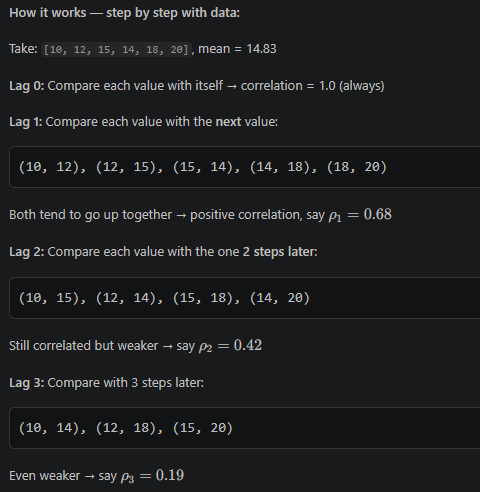

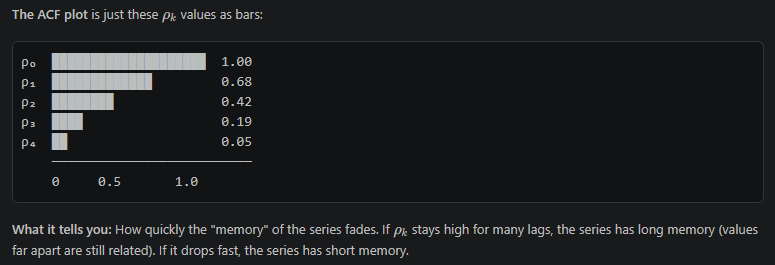


## 5.2 Partial Autocorrelation Function (PACF)

The **partial autocorrelation** at lag $k$ is the correlation between $y_t$ and $y_{t-k}$ **after removing** the linear effect of the intermediate lags $y_{t-1}, y_{t-2}, \ldots, y_{t-k+1}$.

Mathematically, it is the last coefficient $\phi_{kk}$ in the regression:

$$y_t = \phi_{k1} y_{t-1} + \phi_{k2} y_{t-2} + \cdots + \phi_{kk} y_{t-k} + \epsilon_t$$

**Intuition:**
- ACF shows **total** correlation (direct + indirect)
- PACF shows **direct** correlation only (removes intermediaries)

## 5.3 ACF vs PACF:

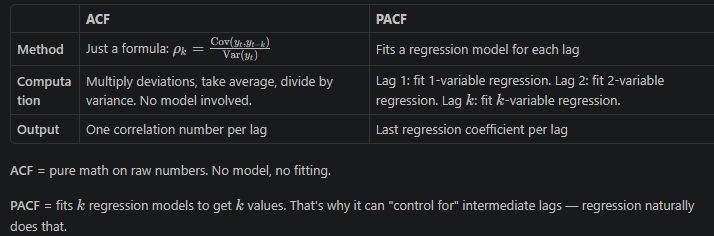

Also, ACF has both direct and indirect relation between the data opoints but ACF doesn't "choose" to show both — it's just a consequence of how covariance works on real data

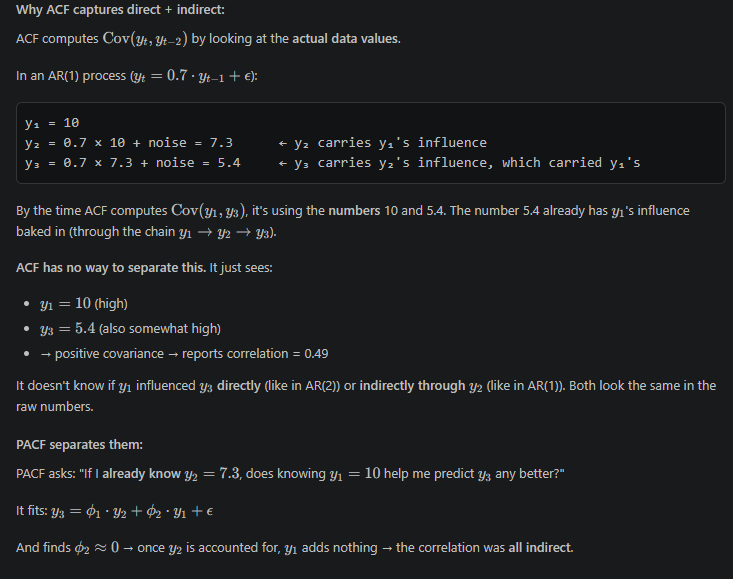

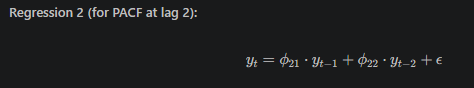

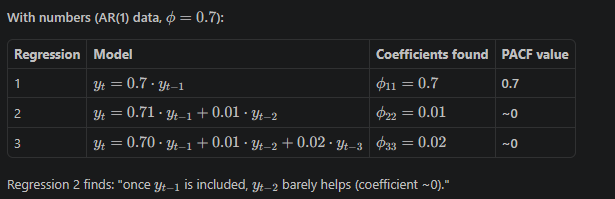


Analogy:
ACF = checking if students' grades are correlated with their grandparents' education.
→ Answer: yes (ρ = 0.4). But is it direct? Or because educated grandparents raised educated parents who helped the students?

PACF = checking the same thing after controlling for parents' education.
→ Answer: ~0. The correlation was entirely through the parents (indirect).


## 5.4 Using ACF/PACF for Model Identification

| Pattern in ACF | Pattern in PACF | Suggested Model |
|---|---|---|
| Tails off (decays slowly) | Cuts off after lag $p$ | **AR(p)** |
| Cuts off after lag $q$ | Tails off (decays slowly) | **MA(q)** |
| Tails off | Tails off | **ARMA(p,q)** |
| Significant spike at seasonal lags | — | Seasonal component needed |

### Confidence Bands
Values outside the 95% confidence band ($\pm 1.96 / \sqrt{n}$) are statistically significant.

Data (monthly sales): [10, 12, 15, 14, 18, 20, 19, 22, 25, 24]
n = 10
Mean (ȳ) = 17.9

STEP 1: Compute γ₀ (Variance)
  Deviations from mean:  ['-7.9', '-5.9', '-2.9', '-3.9', '+0.1', '+2.1', '+1.1', '+4.1', '+7.1', '+6.1']
  Squared deviations:    ['62.41', '34.81', '8.41', '15.21', '0.01', '4.41', '1.21', '16.81', '50.41', '37.21']
  γ₀ = sum / n = 230.90 / 10 = 23.09

STEP 2: Compute γ₁ (Autocovariance at lag 1)
  Pair up each value with the NEXT value:
  t    y_t      y_{t+1}    (y_t-ȳ)      (y_{t+1}-ȳ)    Product
  ────────────────────────────────────────────────────────────
  0    10       12         -7.9         -5.9           46.61
  1    12       15         -5.9         -2.9           17.11
  2    15       14         -2.9         -3.9           11.31
  3    14       18         -3.9         0.1            -0.39
  4    18       20         0.1          2.1            0.21
  5    20       19         2.1          1.1            2.31
  6    19       22         1.1          4.1       

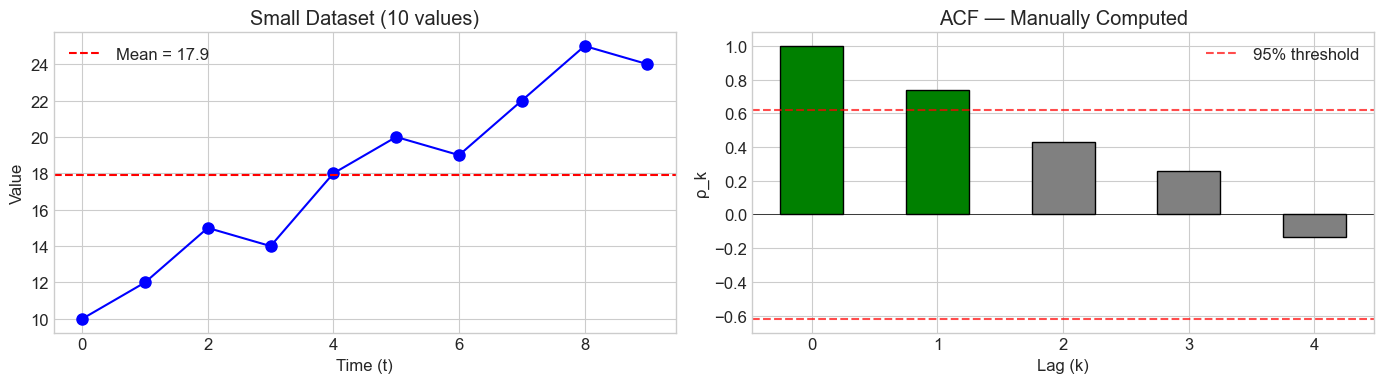

Green bars = significant, Gray bars = not significant (could be noise)


In [17]:
# ============================================================
# 5.1 Example: ACF Step-by-Step on a Small Dataset
# ============================================================
# Let's compute ACF by hand so the formula γ_k / γ_0 becomes concrete.

import numpy as np
import matplotlib.pyplot as plt

# A small time series: monthly sales
data = [10, 12, 15, 14, 18, 20, 19, 22, 25, 24]
y = np.array(data, dtype=float)
n = len(y)
mean = y.mean()

print(f"Data (monthly sales): {data}")
print(f"n = {n}")
print(f"Mean (ȳ) = {mean:.1f}")
print()

# ── Step 1: Compute γ₀ (Variance) ──
# γ₀ = (1/n) × Σ(y_t - ȳ)²
deviations = y - mean
squared_devs = deviations ** 2
gamma_0 = np.mean(squared_devs)

print("STEP 1: Compute γ₀ (Variance)")
print(f"  Deviations from mean:  {[f'{d:+.1f}' for d in deviations]}")
print(f"  Squared deviations:    {[f'{d:.2f}' for d in squared_devs]}")
print(f"  γ₀ = sum / n = {sum(squared_devs):.2f} / {n} = {gamma_0:.2f}")
print()

# ── Step 2: Compute γ₁ (Autocovariance at lag 1) ──
# γ₁ = (1/n) × Σ(y_t - ȳ)(y_{t+1} - ȳ)  for t = 0..n-2
print("STEP 2: Compute γ₁ (Autocovariance at lag 1)")
print(f"  Pair up each value with the NEXT value:")
print(f"  {'t':<4} {'y_t':<8} {'y_{t+1}':<10} {'(y_t-ȳ)':<12} {'(y_{t+1}-ȳ)':<14} {'Product'}")
print(f"  {'─'*60}")
products_1 = []
for t in range(n - 1):
    dev_t = y[t] - mean
    dev_t1 = y[t + 1] - mean
    prod = dev_t * dev_t1
    products_1.append(prod)
    print(f"  {t:<4} {y[t]:<8.0f} {y[t+1]:<10.0f} {dev_t:<12.1f} {dev_t1:<14.1f} {prod:.2f}")

gamma_1 = np.mean(products_1)
rho_1 = gamma_1 / gamma_0
print(f"\n  γ₁ = sum of products / n = {sum(products_1):.2f} / {n} = {gamma_1:.4f}")
print(f"  ρ₁ = γ₁ / γ₀ = {gamma_1:.4f} / {gamma_0:.2f} = {rho_1:.4f}")
print()

# ── Step 3: Compute ACF for lags 0 to 4 ──
print("STEP 3: ACF for all lags")
print(f"  {'Lag':<6} {'γ_k':<12} {'ρ_k = γ_k/γ₀':<18} {'Interpretation'}")
print(f"  {'─'*65}")
acf_values = []
for k in range(5):
    if k == 0:
        gamma_k = gamma_0
    else:
        gamma_k = np.mean((y[:n-k] - mean) * (y[k:] - mean))
    rho_k = gamma_k / gamma_0
    acf_values.append(rho_k)
    
    if k == 0:
        interp = "Always 1 (corr with itself)"
    elif abs(rho_k) > 0.5:
        interp = "Strong correlation"
    elif abs(rho_k) > 0.3:
        interp = "Moderate correlation"
    else:
        interp = "Weak correlation"
    print(f"  {k:<6} {gamma_k:<12.4f} {rho_k:<18.4f} {interp}")

# ── Step 4: Plot the ACF as a bar chart ──
print(f"\n  Significance threshold: ±1.96/√{n} = ±{1.96/np.sqrt(n):.3f}")
print(f"  Values beyond this threshold are statistically significant.\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: the original data
axes[0].plot(range(n), y, 'bo-', markersize=8)
axes[0].axhline(y=mean, color='red', linestyle='--', label=f'Mean = {mean:.1f}')
axes[0].set_title('Small Dataset (10 values)')
axes[0].set_xlabel('Time (t)')
axes[0].set_ylabel('Value')
axes[0].legend()

# Right: the ACF bar chart
lags = range(5)
colors = ['green' if abs(v) > 1.96/np.sqrt(n) else 'gray' for v in acf_values]
axes[1].bar(lags, acf_values, color=colors, edgecolor='black', width=0.5)
axes[1].axhline(y=1.96/np.sqrt(n), color='red', linestyle='--', alpha=0.7, label='95% threshold')
axes[1].axhline(y=-1.96/np.sqrt(n), color='red', linestyle='--', alpha=0.7)
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].set_title('ACF — Manually Computed')
axes[1].set_xlabel('Lag (k)')
axes[1].set_ylabel('ρ_k')
axes[1].set_xticks(lags)
axes[1].legend()

plt.tight_layout()
plt.show()

print("Green bars = significant, Gray bars = not significant (could be noise)")

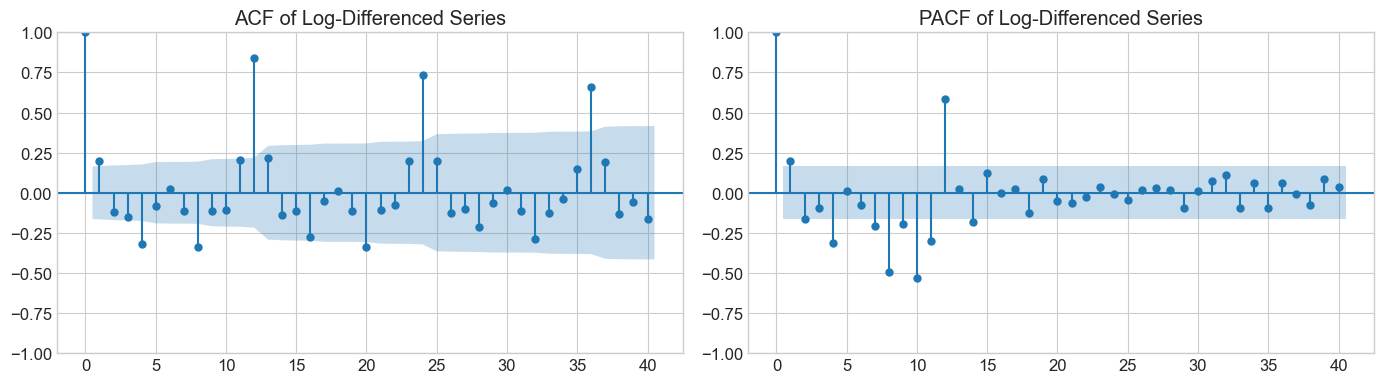


Interpretation:
- ACF: Significant spike at lag 12 -> strong seasonal autocorrelation
- PACF: Significant spike at lag 1, then cuts off -> suggests AR(1) component
- Seasonal spikes at 12, 24 -> seasonal AR or MA terms needed



In [18]:
# 5.4 ACF and PACF plots

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Use the log-differenced (stationary) series
stationary_series = df['log_diff'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(stationary_series, lags=40, ax=axes[0], title='ACF of Log-Differenced Series')
plot_pacf(stationary_series, lags=40, ax=axes[1], method='ywm', title='PACF of Log-Differenced Series')
plt.tight_layout()
plt.show()

print("""
Interpretation:
- ACF: Significant spike at lag 12 -> strong seasonal autocorrelation
- PACF: Significant spike at lag 1, then cuts off -> suggests AR(1) component
- Seasonal spikes at 12, 24 -> seasonal AR or MA terms needed
""")

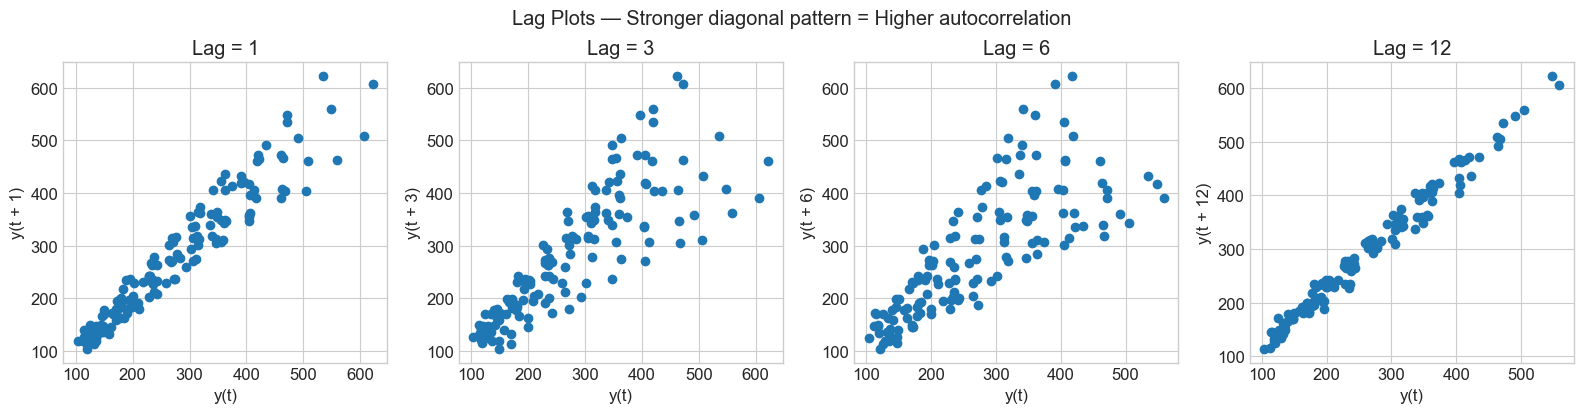

In [19]:
# 5.5 Lag plot — visual check of autocorrelation

from pandas.plotting import lag_plot

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, lag in enumerate([1, 3, 6, 12]):
    lag_plot(df['Passengers'], lag=lag, ax=axes[i])
    axes[i].set_title(f'Lag = {lag}')

plt.tight_layout()
plt.suptitle('Lag Plots — Stronger diagonal pattern = Higher autocorrelation', y=1.03)
plt.show()

### Interpreting the Lag Plots

A **lag plot** plots $y_t$ (value at time $t$) on the x-axis vs $y_{t-k}$ (value $k$ steps later) on the y-axis. It is a quick visual test for autocorrelation.

**How to read it:**
- **Tight diagonal line (↗)** → Strong positive autocorrelation at that lag
- **Scattered cloud / no pattern** → No autocorrelation (random / independent)
- **Tighter the cluster around the diagonal, stronger the correlation**

**Observations for Air Passengers:**

| Lag | Pattern | Interpretation |
|---|---|---|
| **Lag 1** | Very tight diagonal | Strong positive autocorrelation — consecutive months are highly correlated ($\rho_1 \approx 0.95$). If this month is high, next month is very likely high too. |
| **Lag 3** | Diagonal but slightly wider spread | Still strong autocorrelation, but weaker than lag 1. Values 3 months apart are still related. |
| **Lag 6** | Wider spread, possible curvature | Weaker autocorrelation — 6 months apart often means opposite seasons (e.g., Jan vs Jul), so the linear relationship weakens. |
| **Lag 12** | Tighter diagonal again | Strong seasonal autocorrelation — same month in different years are highly correlated (e.g., Jul 1950 ≈ Jul 1951). This confirms the **12-month seasonality**. |

**Key takeaway:** The lag-12 plot being nearly as tight as lag-1 is a strong signal that a **seasonal model** (e.g., SARIMA with $m=12$) is needed.

# 6. Family 1: Smoothing Techniques

---


Smoothing methods are the **simplest forecasting techniques**. They reduce noise and highlight patterns.

## 6.1 Simple Moving Average (SMA)

The SMA over a window of $k$ periods:

$$\hat{y}_t = \frac{1}{k} \sum_{i=0}^{k-1} y_{t-i} = \frac{y_t + y_{t-1} + \cdots + y_{t-k+1}}{k}$$

- Equal weights to all $k$ past observations
- Larger $k$ means smoother but more lag
- Does **not** handle trend or seasonality well

## 6.2 Weighted Moving Average (WMA)

$$\hat{y}_t = \frac{\sum_{i=0}^{k-1} w_i \cdot y_{t-i}}{\sum_{i=0}^{k-1} w_i}$$

where $w_0 > w_1 > \cdots > w_{k-1}$ — more recent observations get higher weights.

### How are the weights decided?

There's no single formula — weights are a **design choice**, not estimated from data. Three common approaches:

**Method 1: Linear Weights** (most common)

Assign weights proportional to recency. For $k = 4$:

| Position | $y_t$ (newest) | $y_{t-1}$ | $y_{t-2}$ | $y_{t-3}$ (oldest) |
|---|---|---|---|---|
| Weight | 4 | 3 | 2 | 1 |
| Normalized | 4/10 | 3/10 | 2/10 | 1/10 |

$$\hat{y} = \frac{4 \cdot y_t + 3 \cdot y_{t-1} + 2 \cdot y_{t-2} + 1 \cdot y_{t-3}}{10}$$

**Method 2: Custom / Domain-Driven Weights**

Set weights based on business knowledge. Example — a retail manager forecasting daily sales knows weekends matter more:

| Mon | Tue | Wed | Thu | Fri | Sat | Sun |
|---|---|---|---|---|---|---|
| 1 | 1 | 1 | 1 | 1 | 3 | 3 |

**Method 3: Exponentially Decaying Weights**

Each weight is a fixed fraction of the previous: $w_i = \alpha^i$ (e.g., $\alpha = 0.5$ → weights: 1.0, 0.5, 0.25, 0.125, ...). Recent values dominate, old values fade fast. This is essentially what **SES (Section 6.3)** does — SES is a WMA with exponential weights extended to infinity.

> **Note:** WMA is a smoothing technique, not a forecasting model. The weights are chosen, not optimized. For actual forecasting, SES/Holt-Winters are preferred because their weights are **automatically optimized** to minimize error.

---

## 6.3 Simple Exponential Smoothing (SES)

**Use when:** Data has **no trend** and **no seasonality** — just noisy values fluctuating around a roughly constant level.

### The Core Idea

SMA gives **equal weight** to all past values. But intuitively, yesterday's sales tell you more about tomorrow than sales from 6 months ago. SES fixes this by giving **exponentially decreasing weights** — recent values matter most, older values fade away.

### The Formula

$$\hat{y}_{t+1} = \alpha \cdot y_t + (1 - \alpha) \cdot \hat{y}_t$$

In plain English:

$$\text{Next forecast} = \alpha \times \text{What actually happened} + (1-\alpha) \times \text{What I predicted last time}$$

- $\alpha \in (0, 1)$ is the **smoothing parameter** — it controls how much you trust new data vs your old forecast.

### Intuition for α

| $\alpha$ | Meaning | Analogy |
|---|---|---|
| **α = 0.9** (high) | 90% weight on latest actual, 10% on old forecast | "I mostly trust what just happened" — reactive, jittery |
| **α = 0.1** (low) | 10% weight on latest actual, 90% on old forecast | "I mostly trust my previous estimate" — smooth, slow to change |

### Worked Example (α = 0.5)

Suppose daily ice cream sales: $y_1=100, \ y_2=120, \ y_3=110$

Start with $\hat{y}_1 = y_1 = 100$ (initialize forecast = first observation).

| Step | Formula | Calculation | Forecast |
|---|---|---|---|
| Forecast for day 2 | $\hat{y}_2 = 0.5 \times y_1 + 0.5 \times \hat{y}_1$ | $0.5 \times 100 + 0.5 \times 100$ | **100** |
| Forecast for day 3 | $\hat{y}_3 = 0.5 \times y_2 + 0.5 \times \hat{y}_2$ | $0.5 \times 120 + 0.5 \times 100$ | **110** |
| Forecast for day 4 | $\hat{y}_4 = 0.5 \times y_3 + 0.5 \times \hat{y}_3$ | $0.5 \times 110 + 0.5 \times 110$ | **110** |

### Why "Exponential"?

Let's unroll the recursion step by step to see where the exponential weights come from.

Start with: $\hat{y}_{t+1} = \alpha y_t + (1-\alpha) \hat{y}_t$

**Unroll step 1:** Replace $\hat{y}_t$ with its own formula $\hat{y}_t = \alpha y_{t-1} + (1-\alpha)\hat{y}_{t-1}$:

$$\hat{y}_{t+1} = \alpha y_t + (1-\alpha)\big[\alpha y_{t-1} + (1-\alpha)\hat{y}_{t-1}\big]$$
$$= \alpha y_t + \alpha(1-\alpha) y_{t-1} + (1-\alpha)^2 \hat{y}_{t-1}$$

**Unroll step 2:** Replace $\hat{y}_{t-1}$ the same way:

$$= \alpha y_t + \alpha(1-\alpha) y_{t-1} + (1-\alpha)^2\big[\alpha y_{t-2} + (1-\alpha)\hat{y}_{t-2}\big]$$
$$= \alpha y_t + \alpha(1-\alpha) y_{t-1} + \alpha(1-\alpha)^2 y_{t-2} + (1-\alpha)^3 \hat{y}_{t-2}$$

**The pattern is clear — keep unrolling and you get:**

$$\hat{y}_{t+1} = \alpha y_t + \alpha(1-\alpha) y_{t-1} + \alpha(1-\alpha)^2 y_{t-2} + \alpha(1-\alpha)^3 y_{t-3} + \cdots$$

Each past observation gets weight $\alpha(1-\alpha)^k$ where $k$ = how far back it is. Since $(1-\alpha) < 1$, raising it to higher powers makes it **shrink exponentially** — hence the name.

**With $\alpha = 0.5$:**

| Observation | Weight formula | Weight value | % of total |
|---|---|---|---|
| $y_t$ (today) | $\alpha$ | 0.5 | 50% |
| $y_{t-1}$ (yesterday) | $\alpha(1-\alpha)$ | 0.25 | 25% |
| $y_{t-2}$ (2 days ago) | $\alpha(1-\alpha)^2$ | 0.125 | 12.5% |
| $y_{t-3}$ (3 days ago) | $\alpha(1-\alpha)^3$ | 0.0625 | 6.25% |
| ... | ... | → 0 | → 0 |

Today gets half the weight, yesterday gets a quarter, and old data fades fast. That's exponential decay.

### Limitation — SES Forecasts a Flat Line

SES works fine for **fitting past data** — because it uses actual values $y_t$ which pull the forecast along. But when forecasting future values, there are no more actuals. Watch what happens:

**Forecasting step 1** (one step ahead — $y_{T}$ is still known):

$$\hat{y}_{T+1} = \alpha \cdot y_T + (1-\alpha) \cdot \hat{y}_T \quad \text{← uses real data, works fine}$$

**Forecasting step 2** (two steps ahead — $y_{T+1}$ doesn't exist yet, so we substitute $\hat{y}_{T+1}$):

$$\hat{y}_{T+2} = \alpha \cdot \hat{y}_{T+1} + (1-\alpha) \cdot \hat{y}_{T+1} = \underbrace{(\alpha + 1 - \alpha)}_{= 1} \cdot \hat{y}_{T+1} = \hat{y}_{T+1}$$

**The forecast feeds on itself.** $\alpha + (1-\alpha) = 1$, so you're multiplying the same number by 1. It never changes:

$$\hat{y}_{T+2} = \hat{y}_{T+3} = \hat{y}_{T+4} = \cdots = \text{flat line forever}$$

**The root cause:** SES knows WHERE the series is (the level) but not WHERE IT'S GOING (the trend). Without new actual data to drag it upward, the forecast just sits still. → That's why we need Holt's method, which adds a trend term $b_t$ so that $\hat{y}_{T+h} = \ell_T + h \cdot b_T$ — the forecast keeps climbing even without new data.

### How to Find the Optimal α

There are two approaches:

#### Method 1: Manual Selection

You pick α based on intuition or domain knowledge:

| α value | Behavior | Use when |
|---|---|---|
| 0.1 – 0.3 | Smooth, slow to react | Data is noisy, underlying level is stable |
| 0.4 – 0.6 | Balanced | General purpose |
| 0.7 – 0.9 | Reactive, tracks changes fast | Data has real shifts you want to capture quickly |

You can try a few values, plot the fitted curves, and eyeball which one tracks the data best. Quick but subjective.

#### Method 2: Automatic Optimization (what `statsmodels` does)

The algorithm finds the α that **minimizes the Sum of Squared Errors (SSE)** using a numerical solver (L-BFGS-B). Here's exactly what happens:

**Step 1 — Generate forecasts with a trial α** (e.g., α = 0.1):

Run through the entire dataset using $\hat{y}_t = \alpha y_{t-1} + (1-\alpha)\hat{y}_{t-1}$, starting with $\hat{y}_1 = y_1$. This produces a forecast for every data point.

**Step 2 — Compute SSE** (the loss function):

$$\text{SSE}(\alpha) = \sum_{t=1}^{n}(y_t - \hat{y}_t)^2$$

**Step 3 — Use calculus to find the direction and step size:**

- **Gradient** (1st derivative $\frac{d(\text{SSE})}{d\alpha}$): tells the solver **which direction** to move α. If gradient is negative → increase α to reduce error.
- **Hessian** (2nd derivative $\frac{d^2(\text{SSE})}{d\alpha^2}$): tells the solver **how far to jump**. The Newton Step is:

$$\text{Step} = \frac{\text{Gradient}}{\text{Hessian}}$$

Steep curvature → small careful step. Flat curvature → big confident jump.

**Step 4 — Line search** (validation before committing):

Before jumping to the new α, the solver samples a few points along the path and fits a parabola (quadratic interpolation). It jumps to the bottom of that parabola — a more precise landing than the raw Newton step.

**Step 5 — Boundary check:**

α is constrained to $[0, 1]$. If the step suggests α = 1.05, L-BFGS-B clips it to 1.0.

**Step 6 — Convergence:**

Repeat steps 1–5. Stop when the change in SSE between iterations is smaller than a tiny threshold (e.g., $10^{-8}$). The final α is your **optimal alpha**.

```python
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# Method 1: Manual
model_manual = SimpleExpSmoothing(data).fit(smoothing_level=0.3, optimized=False)

# Method 2: Automatic (default — runs the full optimization above)
model_auto = SimpleExpSmoothing(data).fit()
print(f"Optimal alpha: {model_auto.params['smoothing_level']:.4f}")
```

---

## 6.4 Double Exponential Smoothing (Holt's Method)

**Use when:** Data has a **trend** (going up or down) but **no seasonality**.

### The Problem SES Can't Solve

If sales grow by ~10 units every month, SES will always lag behind because it has no concept of "things are going up." Holt's method fixes this by tracking **two things separately**:

1. **Level ($\ell_t$):** Where is the series RIGHT NOW? (the current base value)
2. **Trend ($b_t$):** How much is it CHANGING per period? (the slope)

### The Two Equations

**Level equation:**
$$\ell_t = \alpha \cdot y_t + (1 - \alpha)(\ell_{t-1} + b_{t-1})$$

In plain English:
$$\text{Current level} = \alpha \times \text{Actual value} + (1-\alpha) \times \text{Where I expected to be}$$

- $\ell_{t-1} + b_{t-1}$ = "last level + last trend" = where you *expected* to be right now
- This blends actual observation with expectation — same idea as SES, but now expectations include the trend

**Trend equation:**
$$b_t = \beta(\ell_t - \ell_{t-1}) + (1 - \beta) b_{t-1}$$

In plain English:
$$\text{Current trend} = \beta \times \text{Observed change in level} + (1-\beta) \times \text{Previous trend estimate}$$

- $\ell_t - \ell_{t-1}$ = how much the level actually moved this period
- This blends the newly observed slope with the old trend estimate

**Forecast h steps ahead:**
$$\hat{y}_{t+h} = \ell_t + h \cdot b_t$$

"Start from current level, add trend × number of steps." This gives a **sloped line** (not flat like SES).

### Worked Example

Monthly revenue: $y_1 = 100, \ y_2 = 112, \ y_3 = 121$. Use $\alpha = 0.6, \ \beta = 0.5$.

**Initialize:** $\ell_1 = 100, \ b_1 = 12$ (first trend = $y_2 - y_1$, or a reasonable guess)

| $t$ | $y_t$ | Level $\ell_t$ | Trend $b_t$ | Explanation |
|---|---|---|---|---|
| 1 | 100 | 100 | 12 | Starting values |
| 2 | 112 | $0.6 \times 112 + 0.4 \times (100+12) = \mathbf{112}$ | $0.5 \times (112-100) + 0.5 \times 12 = \mathbf{12}$ | Level jumped to 112, trend confirmed at 12 |
| 3 | 121 | $0.6 \times 121 + 0.4 \times (112+12) = \mathbf{122.2}$ | $0.5 \times (122.2-112) + 0.5 \times 12 = \mathbf{11.1}$ | Level ~122, trend slightly slowed to 11.1 |

**Forecast month 4:** $\hat{y}_4 = 122.2 + 1 \times 11.1 = \mathbf{133.3}$

**Forecast month 5:** $\hat{y}_5 = 122.2 + 2 \times 11.1 = \mathbf{144.4}$

Notice: unlike SES, the forecast is a **line going up**, not a flat number.

### Parameters α and β

| Parameter | Controls | High value | Low value |
|---|---|---|---|
| $\alpha$ | Level smoothing | Trusts latest data more (reactive level) | Trusts history more (smooth level) |
| $\beta$ | Trend smoothing | Trend adapts fast to changes | Trend changes slowly (stable slope) |

### How Are the Optimal Values of α, β, $\ell_0$, $b_0$ Found?

There are **4 unknowns** to find — not just 2. The smoothing parameters ($\alpha$, $\beta$) AND the initial states ($\ell_0$, $b_0$) are all optimized together by minimizing SSE in a 4-dimensional space.

The optimizer needs a **starting point** to begin the search. These are reasonable initial guesses (not final values — the optimizer will move them):

- $\ell_0 = y_1$ — "the series starts at the first observation"
- $b_0 = y_2 - y_1$ — "the initial slope is the change between the first two points"
- $\alpha = 0.1, \ \beta = 0.1$ — conservative starting smoothing values

From here, the optimizer iteratively adjusts all 4 values to find the combination that gives the smallest SSE.

#### The Objective Function

$$\text{SSE} = \sum_{t=1}^{n}(y_t - \hat{y}_t)^2, \quad \text{where } \hat{y}_t = \ell_{t-1} + b_{t-1}$$

#### The Gradient (how SSE reacts to each knob)

Since the equations are recursive (each level depends on the previous one), we use the chain rule to compute partial derivatives for all 4 variables.

**For smoothing parameters** ($\alpha$ and $\beta$) — the derivative ripples through time:

$$\frac{\partial \text{SSE}}{\partial \alpha} = \sum_{t=1}^{n} -2(y_t - \hat{y}_t)\left(\frac{\partial \ell_{t-1}}{\partial \alpha} + \frac{\partial b_{t-1}}{\partial \alpha}\right)$$

The inner term $\frac{\partial \ell_t}{\partial \alpha}$ is recursive (same domino effect as MA's θ):

$$\frac{\partial \ell_t}{\partial \alpha} = \underbrace{\big(y_t - (\ell_{t-1} + b_{t-1})\big)}_{\text{direct effect}} + \underbrace{(1-\alpha)\frac{\partial(\ell_{t-1} + b_{t-1})}{\partial \alpha}}_{\text{ripple from all past steps}}$$

A change in $\alpha$ at $t=1$ affects $\ell_1$, which affects $\ell_2$, which affects $\ell_3$... all the way to $\ell_n$. The derivative tracks this entire chain. Same logic applies for $\frac{\partial \text{SSE}}{\partial \beta}$.

**For initial states** ($\ell_0$ and $b_0$) — a nudge at $t=0$ echoes through every future forecast:

$$\frac{\partial \text{SSE}}{\partial \ell_0} = \sum_{t=1}^{n} -2(y_t - \hat{y}_t)\frac{\partial \hat{y}_t}{\partial \ell_0}$$

Since $\hat{y}_t$ is built from a chain of past levels and trends, $\frac{\partial \hat{y}_t}{\partial \ell_0}$ is a decaying weight based on $(1-\alpha)$ and $(1-\beta)$ — the influence of the initial guess fades over time but never fully disappears.

#### The Optimization Step

With the gradient vector $\nabla = \left[\frac{\partial \text{SSE}}{\partial \alpha}, \frac{\partial \text{SSE}}{\partial \beta}, \frac{\partial \text{SSE}}{\partial \ell_0}, \frac{\partial \text{SSE}}{\partial b_0}\right]$ and an approximate Hessian $H$ (matrix of second derivatives), the optimizer updates all 4 values simultaneously:

$$\theta_{\text{next}} = \theta_{\text{current}} - H^{-1}\nabla, \quad \text{where } \theta = [\alpha, \beta, \ell_0, b_0]$$

`statsmodels` uses **L-BFGS-B** which approximates $H^{-1}$ cheaply from past gradients instead of computing the full Hessian.

#### The Full Pipeline

```
1. Initialize: ℓ₀ = y₁, b₀ = y₂ − y₁, α = β = 0.1  (starting guesses)
                        ↓
2. Forward pass: compute all ŷ_t and SSE using current [α, β, ℓ₀, b₀]
                        ↓
3. Backward pass: compute all 4 partial derivatives (gradient vector)
                        ↓
4. Newton step: compute update direction using gradient + approximate Hessian
                        ↓
5. Line search: probe the path, fit a parabola, jump to its minimum
                        ↓
6. Boundary check: clip α, β to [0,1]; ℓ₀, b₀ unconstrained
                        ↓
7. Converged? (gradient ≈ 0?) ──NO──→ Go back to step 2
       │
      YES
       ↓
8. Return optimal [α̂, β̂, ℓ̂₀, b̂₀]
```

```python
from statsmodels.tsa.holtwinters import ExponentialSmoothing
model = ExponentialSmoothing(data, trend='add').fit()
print(f"α = {model.params['smoothing_level']:.4f}")
print(f"β = {model.params['smoothing_trend']:.4f}")
print(f"ℓ₀ = {model.params['initial_level']:.4f}")
print(f"b₀ = {model.params['initial_trend']:.4f}")
```

### Limitation

Holt's can follow a trend, but if your data has **repeating seasonal peaks** (e.g., summer spikes every year), it can't capture them. → That's why we need Holt-Winters.

### Why Holt's Doesn't Forecast a Flat Line Like SES

Both SES and Holt's use $y_t$ during **fitting**. The difference is what happens when you **forecast beyond the training data** — no more $y_t$ available.

**SES forecast — feeds on itself and collapses:**

$$\hat{y}_{T+1} = \alpha y_T + (1-\alpha)\hat{y}_T \quad \text{← uses real } y_T \text{, works fine}$$

$$\hat{y}_{T+2} = \alpha \hat{y}_{T+1} + (1-\alpha)\hat{y}_{T+1} = (\alpha + 1 - \alpha) \cdot \hat{y}_{T+1} = \hat{y}_{T+1} \quad \text{← feeds on itself, stuck}$$

Once you run out of actuals, $y_{T+1}$ doesn't exist so SES substitutes $\hat{y}_{T+1}$ — and $\alpha + (1-\alpha) = 1$, so it just multiplies by 1. The forecast stays frozen at one number forever.

**Holt's forecast — the trend keeps it moving:**

$$\hat{y}_{T+h} = \ell_T + h \cdot b_T$$

This equation **doesn't use $y_t$ at all**. Both $\ell_T$ and $b_T$ were already computed during training. The $h \cdot b_T$ term adds the trend at each step:

| $h$ | SES: $\hat{y} = \ell_T$ | Holt's: $\hat{y} = \ell_T + h \cdot b_T$ |
|---|---|---|
| 1 | 122 (stuck) | $122 + 1 \times 11 = 133$ |
| 2 | 122 (stuck) | $122 + 2 \times 11 = 144$ |
| 3 | 122 (stuck) | $122 + 3 \times 11 = 155$ |
| Pattern | **Flat line** | **Goes up by $b_T$ each step** |

**Why doesn't Holt's collapse?** Because SES has **one component** (level) — when forecasting, it just repeats it. Holt's has **two components** (level + trend) — the trend keeps adding $b_T$ each step, even without new data.

**Same logic for Holt-Winters** with three components:

$$\hat{y}_{T+h} = (\ell_T + h \cdot b_T) \times s_{T+h-m}$$

- $h \cdot b_T$ → line keeps going up (trend)
- $s_{T+h-m}$ → seasonal factor cycles through (July = 1.3×, Feb = 0.8×)

Even without new $y_t$ values, the forecast produces a **trending, seasonal curve** — not a flat line.

**Summary:** SES collapses because it only knows WHERE (level). Holt's doesn't collapse because it also knows HOW FAST (trend) — so it keeps moving. Holt-Winters adds WHICH SEASON — so it keeps oscillating too.

---

## 6.5 Triple Exponential Smoothing (Holt-Winters)

**Use when:** Data has **both a trend AND seasonality** (the most common real-world case).

### The Idea

Add a **third component** to track the seasonal pattern. Now we maintain:

1. **Level ($\ell_t$):** Base value (same as Holt's)
2. **Trend ($b_t$):** Slope (same as Holt's)
3. **Seasonality ($s_t$):** How much does this particular season (e.g., July) deviate from the base?

### Additive vs Multiplicative

- **Additive:** Seasonal effect is a **fixed number** added/subtracted. E.g., "July is always +50 passengers above the base."
- **Multiplicative:** Seasonal effect is a **multiplier**. E.g., "July is always 1.3× the base." Use this when seasonal swings grow with the level (Air Passengers!).

### Additive Holt-Winters Equations

**Level:** $\ell_t = \alpha (y_t - s_{t-m}) + (1-\alpha)(\ell_{t-1} + b_{t-1})$

→ Subtract the seasonal effect from actual data to see the "true" level. $m$ = seasonal period (e.g., 12 months).

**Trend:** $b_t = \beta(\ell_t - \ell_{t-1}) + (1-\beta) b_{t-1}$

→ Same as Holt's — track how fast the level is changing.

**Seasonality:** $s_t = \gamma(y_t - \ell_t) + (1-\gamma) s_{t-m}$

→ "How much did this month differ from the level?" Blend that with what this same month's seasonal factor was last year ($s_{t-m}$).

**Forecast h steps ahead:** $\hat{y}_{t+h} = \ell_t + h \cdot b_t + s_{t+h-m}$

→ Level + trend projection + seasonal effect for that specific future month.

### Simple Example (Additive, quarterly data, m=4)

Ice cream shop quarterly revenue. $m=4$ (4 quarters/year).

Suppose after processing the first year, we have:
- Level: $\ell = 100$ (base revenue)
- Trend: $b = 5$ (growing by 5 per quarter)
- Seasonal factors: Q1 = −20, Q2 = +10, Q3 = +30, Q4 = −20

**Forecasting next year:**

| Quarter | Calculation | Forecast |
|---|---|---|
| Q1 (h=1) | $100 + 1 \times 5 + (-20)$ | **85** |
| Q2 (h=2) | $100 + 2 \times 5 + (+10)$ | **120** |
| Q3 (h=3) | $100 + 3 \times 5 + (+30)$ | **145** |
| Q4 (h=4) | $100 + 4 \times 5 + (-20)$ | **100** |

The forecast rises (trend = +5/quarter) AND shows summer peaks (Q3 = +30). That's the power of Holt-Winters.

### Multiplicative Holt-Winters Equations

Same structure, but seasonality is a **ratio** instead of an offset:

**Level:** $\ell_t = \alpha \frac{y_t}{s_{t-m}} + (1-\alpha)(\ell_{t-1} + b_{t-1})$

→ Divide out the seasonal effect instead of subtracting.

**Trend:** $b_t = \beta(\ell_t - \ell_{t-1}) + (1-\beta) b_{t-1}$

→ Same as additive — track how fast the level is changing. (Trend equation is identical in both additive and multiplicative HW.)

**Seasonality:** $s_t = \gamma \frac{y_t}{\ell_t} + (1-\gamma) s_{t-m}$

→ Seasonal factor ≈ "actual / level" (e.g., 1.3 means 30% above base).

**Forecast:** $\hat{y}_{t+h} = (\ell_t + h \cdot b_t) \times s_{t+h-m}$

→ Multiply instead of add — so as the base grows, seasonal peaks grow proportionally.

### Parameters Summary

| Parameter | Controls | Typical range |
|---|---|---|
| $\alpha$ | How fast the **level** adapts | 0.1 – 0.3 for smooth data |
| $\beta$ | How fast the **trend** adapts | Often small (0.01 – 0.2) |
| $\gamma$ | How fast **seasonality** adapts | 0.05 – 0.3 |
| $m$ | Seasonal period | 12 (monthly), 4 (quarterly), 7 (daily with weekly cycle) |

In practice, these are **optimized automatically** by minimizing forecast error (statsmodels does this for you).

### How to Decide: Additive vs Multiplicative?

**The one question:** Do the seasonal peaks grow as the level grows?

- **YES → Multiplicative** (`seasonal='mul'`): seasonal effect is a ratio (e.g., July = 1.3× the base)
- **NO → Additive** (`seasonal='add'`): seasonal effect is a fixed offset (e.g., July = +50 above the base)

**Visual test:** Plot your data. If the peaks get taller over time → multiplicative. If they stay the same height → additive.

**Numeric test for Air Passengers:**

| Year | Peak | Trough | Seasonal Range (peak − trough) |
|---|---|---|---|
| 1949 | 148 | 104 | **44** |
| 1955 | 364 | 180 | **184** |
| 1960 | 622 | 390 | **232** |

Range grows from 44 → 232 as the level grows → **multiplicative**.

**What happens if you choose wrong?**

| Your choice | Data is actually additive | Data is actually multiplicative |
|---|---|---|
| `seasonal='add'` | Correct | **Underpredicts** peaks at high levels, **overpredicts** at low levels |
| `seasonal='mul'` | Slightly off but usually OK | Correct |

**Safe default:** If unsure, try both on a test set and compare MAE. Or just use **multiplicative** — it degrades more gracefully on additive data than vice versa.

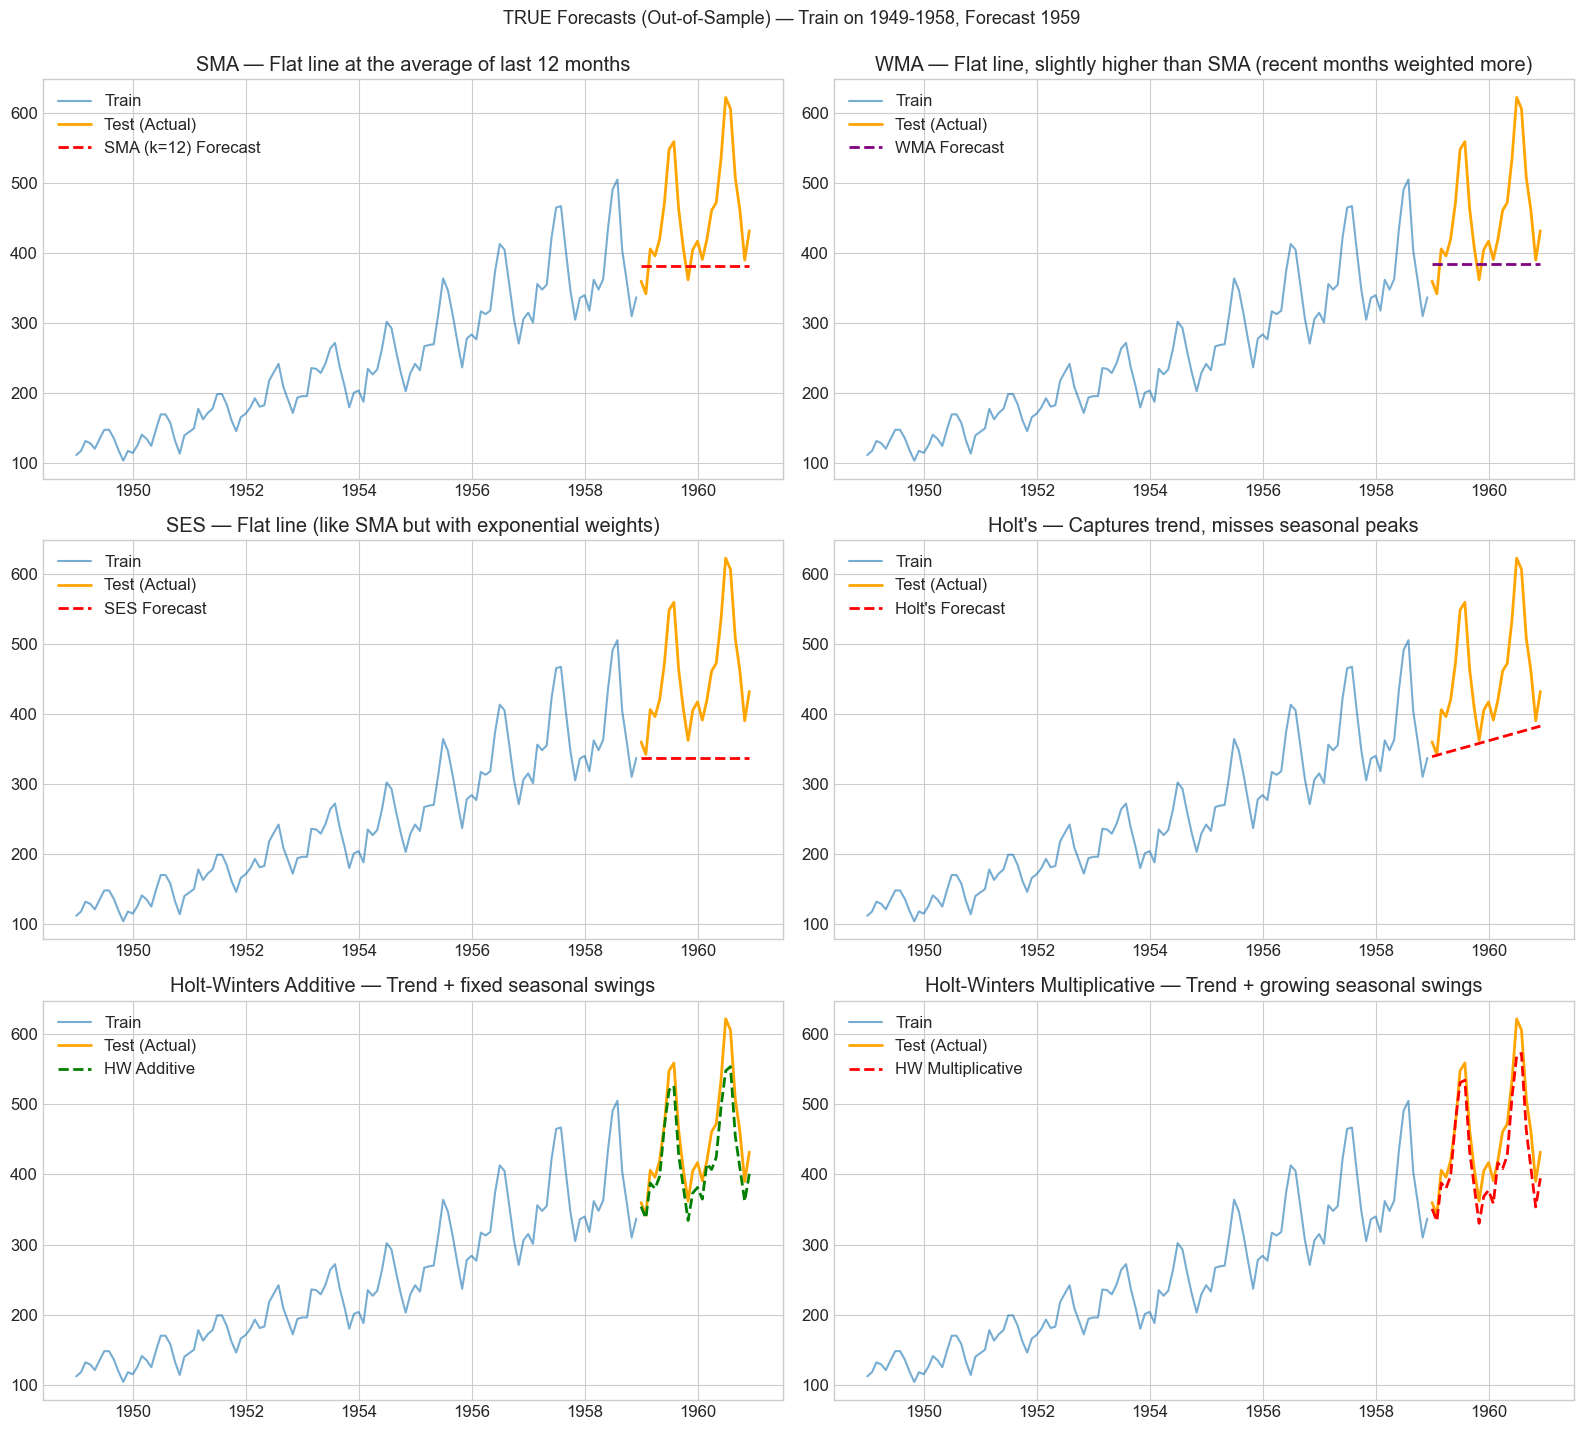

Model                               MAE     RMSE
────────────────────────────────────────────────
SMA (k=12)                        77.83   103.21
WMA (linear weights)              74.78   100.44
SES                              115.25   137.33
Holt's                            91.62   115.70
HW Additive                       31.08    35.76
HW Multiplicative                 28.98    32.49

SMA/WMA/SES all forecast FLAT LINES — they can't capture trend or seasonality.
HW Multiplicative wins because it captures trend + growing seasonal swings.


In [20]:
# 6.6 Smoothing Techniques — Actual Forecasts (Out-of-Sample)
# Train on 1949-1958, forecast on 1959 — this shows TRUE forecasting ability

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
df.columns = ['Passengers']
df.index.freq = 'MS'

passengers = df['Passengers']
train = passengers[:'1958']
test = passengers['1959':]
h = len(test)  # 12 months to forecast

fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# --- (a) SMA Forecast — repeats the last window average ---
k = 12  # 12-month window
sma_value = train.iloc[-k:].mean()  # average of last 12 months
sma_fc = pd.Series([sma_value] * h, index=test.index)

axes[0, 0].plot(train, label='Train', alpha=0.6)
axes[0, 0].plot(test, label='Test (Actual)', color='orange', linewidth=2)
axes[0, 0].plot(sma_fc, label=f'SMA (k={k}) Forecast', color='red', linestyle='--', linewidth=2)
axes[0, 0].legend()
axes[0, 0].set_title('SMA — Flat line at the average of last 12 months')

# --- (b) WMA Forecast — weighted average, more weight to recent ---
weights = np.arange(1, k + 1)  # linear weights: 1, 2, ..., 12
wma_value = np.average(train.iloc[-k:], weights=weights)
wma_fc = pd.Series([wma_value] * h, index=test.index)

axes[0, 1].plot(train, label='Train', alpha=0.6)
axes[0, 1].plot(test, label='Test (Actual)', color='orange', linewidth=2)
axes[0, 1].plot(wma_fc, label='WMA Forecast', color='purple', linestyle='--', linewidth=2)
axes[0, 1].legend()
axes[0, 1].set_title('WMA — Flat line, slightly higher than SMA (recent months weighted more)')

# --- (c) SES Forecast — FLAT LINE ---
ses_model = SimpleExpSmoothing(train).fit(optimized=True)
ses_fc = ses_model.forecast(h)

axes[1, 0].plot(train, label='Train', alpha=0.6)
axes[1, 0].plot(test, label='Test (Actual)', color='orange', linewidth=2)
axes[1, 0].plot(ses_fc, label='SES Forecast', color='red', linestyle='--', linewidth=2)
axes[1, 0].legend()
axes[1, 0].set_title('SES — Flat line (like SMA but with exponential weights)')

# --- (d) Holt's Forecast — TRENDING LINE, NO SEASONS ---
holt_model = ExponentialSmoothing(train, trend='add', seasonal=None).fit()
holt_fc = holt_model.forecast(h)

axes[1, 1].plot(train, label='Train', alpha=0.6)
axes[1, 1].plot(test, label='Test (Actual)', color='orange', linewidth=2)
axes[1, 1].plot(holt_fc, label="Holt's Forecast", color='red', linestyle='--', linewidth=2)
axes[1, 1].legend()
axes[1, 1].set_title("Holt's — Captures trend, misses seasonal peaks")

# --- (e) Holt-Winters Additive ---
hw_add_model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12).fit()
hw_add_fc = hw_add_model.forecast(h)

axes[2, 0].plot(train, label='Train', alpha=0.6)
axes[2, 0].plot(test, label='Test (Actual)', color='orange', linewidth=2)
axes[2, 0].plot(hw_add_fc, label='HW Additive', color='green', linestyle='--', linewidth=2)
axes[2, 0].legend()
axes[2, 0].set_title('Holt-Winters Additive — Trend + fixed seasonal swings')

# --- (f) Holt-Winters Multiplicative ---
hw_mul_model = ExponentialSmoothing(train, trend='add', seasonal='mul', seasonal_periods=12).fit()
hw_mul_fc = hw_mul_model.forecast(h)

axes[2, 1].plot(train, label='Train', alpha=0.6)
axes[2, 1].plot(test, label='Test (Actual)', color='orange', linewidth=2)
axes[2, 1].plot(hw_mul_fc, label='HW Multiplicative', color='red', linestyle='--', linewidth=2)
axes[2, 1].legend()
axes[2, 1].set_title('Holt-Winters Multiplicative — Trend + growing seasonal swings')

plt.tight_layout()
plt.suptitle('TRUE Forecasts (Out-of-Sample) — Train on 1949-1958, Forecast 1959', y=1.02, fontsize=13)
plt.show()

# --- Error comparison ---
from sklearn.metrics import mean_absolute_error, mean_squared_error

print(f"{'Model':<30} {'MAE':>8} {'RMSE':>8}")
print(f"{'─'*48}")
for name, fc in [('SMA (k=12)', sma_fc), ('WMA (linear weights)', wma_fc), ('SES', ses_fc),
                  ("Holt's", holt_fc), ('HW Additive', hw_add_fc), ('HW Multiplicative', hw_mul_fc)]:
    mae = mean_absolute_error(test, fc)
    rmse = np.sqrt(mean_squared_error(test, fc))
    print(f"{name:<30} {mae:>8.2f} {rmse:>8.2f}")
print(f"\nSMA/WMA/SES all forecast FLAT LINES — they can't capture trend or seasonality.")
print(f"HW Multiplicative wins because it captures trend + growing seasonal swings.")

### Observations — Smoothing Techniques Forecast (6.6)

Each model was trained on 1949–1958 and forecasted 1959 (unseen data):

**(a) SMA → Flat line at the average of last 12 months.** No concept of trend or seasonality — just a single number repeated. Slightly better than a random guess, but not by much.

**(b) WMA → Also flat, but slightly higher than SMA.** Because linear weights (1,2,...,12) give more weight to recent months which were higher. Still a flat line — WMA can't forecast trends either.

**(c) SES → Flat line (same problem).** Exponential weights instead of linear, but still collapses to a single value when forecasting beyond the training data. All three flat-line methods (SMA, WMA, SES) are equally bad at this.

**(d) Holt's → Straight trending line.** Captures the upward trend, but completely misses the seasonal peaks and dips. A smooth rising line through what should be a zig-zag.

**(e) Holt-Winters Additive → Trend + seasons, but fixed amplitude.** Captures both trend and seasonal shape, but peaks are all the same height — in reality later peaks are taller.

**(f) Holt-Winters Multiplicative → Best fit.** The forecast rises AND the seasonal swings grow proportionally. Lowest MAE and RMSE.

**Progression:** Flat line (SMA/WMA/SES) → trending line (Holt's) → trending + seasonal (HW). Each step adds one more component and reduces error.

# 7. Family 2: Classical Forecasting Models

---

## 7.1 White Noise

A time series $\{\epsilon_t\}$ is **white noise** if:

$$E[\epsilon_t] = 0, \quad \text{Var}(\epsilon_t) = \sigma^2, \quad \text{Cov}(\epsilon_t, \epsilon_s) = 0 \text{ for } t \neq s$$

White noise is the **building block** of all time series models.

## 7.2 Random Walk

$$y_t = y_{t-1} + \epsilon_t$$

A random walk is **non-stationary** (variance grows with time: $\text{Var}(y_t) = t\sigma^2$).

First differencing a random walk gives white noise: $\Delta y_t = \epsilon_t$.

## 7.3 AR(p) — AutoRegressive Model of order p

The current value depends linearly on its own past values:

$$y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \cdots + \phi_p y_{t-p} + \epsilon_t$$

Using the **backshift operator** $B$ (where $By_t = y_{t-1}$):

$$\Phi(B) y_t = c + \epsilon_t$$

where $\Phi(B) = 1 - \phi_1 B - \phi_2 B^2 - \cdots - \phi_p B^p$

**Stationarity condition for AR(1):** $|\phi_1| < 1$

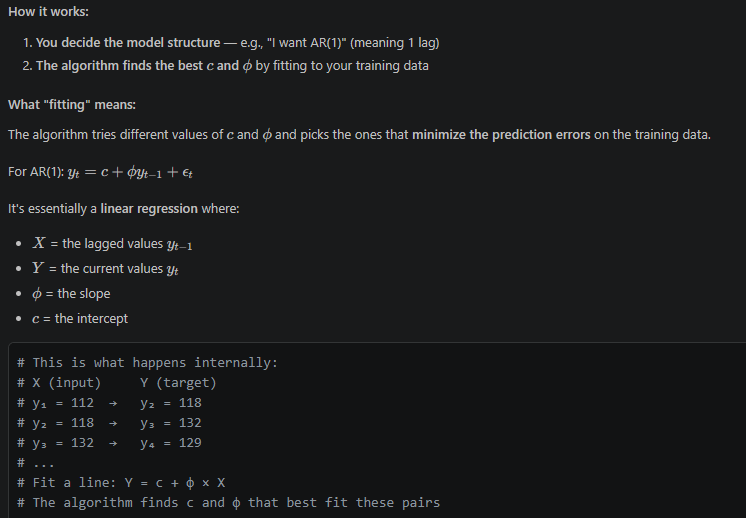

**How ACF and PACF help you choose p for AR ?**

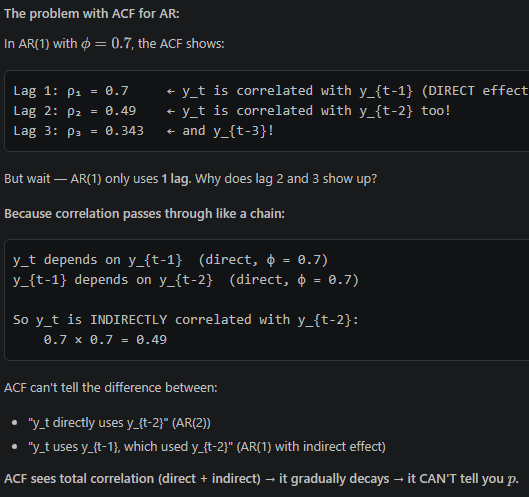

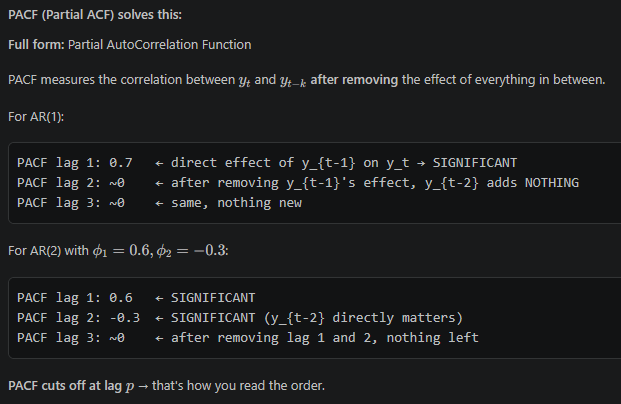


### Derivation: Mean and Variance of AR(1)

For $y_t = c + \phi y_{t-1} + \epsilon_t$:

**Mean:** Taking expectations: $E[y_t] = c + \phi E[y_{t-1}]$. Under stationarity $E[y_t] = \mu$:

$$\mu = c + \phi \mu \implies \mu = \frac{c}{1 - \phi}$$

**Variance:** $\text{Var}(y_t) = \phi^2 \text{Var}(y_{t-1}) + \sigma^2_\epsilon$. Under stationarity:

$$\sigma^2_y = \frac{\sigma^2_\epsilon}{1 - \phi^2}$$

**Autocorrelation:** $\rho_k = \phi^k$ (geometric decay)

**ACF/PACF signature:**
- ACF: Tails off 
- PACF: Cuts off after lag $p$

---

## 7.4 MA(q) — Moving Average Model of order q

### 7.4.1 What is MA?

The **Moving Average model** says: today's value is the long-run average **plus** today's random shock **plus** a weighted echo of recent past shocks.

It does **not** mean "moving average" like SMA (Section 6.1). The name is confusing — MA(q) is a regression on past **error terms**, not past values.

**Key property:** MA models are **always stationary**, regardless of parameter values (because they're a finite sum of white noise terms).

### 7.4.2 What Problem Does MA Solve?

Sometimes data has no trend, no seasonality — it just bounces around an average. But the bounces aren't fully random. When something unexpected happens (a "shock"), its effect **lingers for a few periods** then dies out.

**Example:** A restaurant gets a great review on Monday (shock). Tuesday and Wednesday get extra customers (echo of the shock). By Thursday, effect is gone. MA models exactly this pattern — **short-lived shock spillover**.

AR can't handle this well because AR models **momentum** (yesterday was high → today is probably high). MA models **shock echoes** (yesterday had a surprise → today still feels it).

### 7.4.3 The Model Equation

**MA(1):**

$$y_t = \mu + \epsilon_t + \theta_1 \cdot \epsilon_{t-1}$$

**MA(q) (general):**

$$y_t = \mu + \epsilon_t + \theta_1 \epsilon_{t-1} + \theta_2 \epsilon_{t-2} + \cdots + \theta_q \epsilon_{t-q}$$

**What each symbol means:**

| Symbol | What it is | Plain English |
|---|---|---|
| $y_t$ | Observed value at time $t$ | The number you see in your data |
| $\mu$ | Long-run mean of the series | If there were no shocks at all, every value would be $\mu$ |
| $\epsilon_t$ | Shock (error/innovation) at time $t$ | The surprise — how much $y_t$ deviated from what the model expected. Drawn from $N(0, \sigma^2)$ |
| $\theta_1$ | Coefficient for lag-1 shock | If $\theta_1 = 0.7$, then 70% of yesterday's surprise spills into today |
| $q$ | Order — how many past shocks matter | MA(1): only yesterday's shock. MA(2): yesterday's + day before's |

### 7.4.4 Where Do the Error Terms Come From?

In AR, you regress on past **observed values** ($y_{t-1}, y_{t-2}$) — easy to see in your data. In MA, you regress on past **errors** — but errors aren't directly in your data!

**The errors are computed iteratively.** Rearrange the MA(1) equation:

$$\epsilon_t = y_t - \mu - \theta_1 \cdot \epsilon_{t-1}$$

Start with $\epsilon_0 = 0$ (assume the first error is zero), then compute each subsequent error one by one.

**Worked example** with data $y = [12, 15, 11, 14, 13]$, $\mu = 13$, $\theta_1 = 0.5$:

| $t$ | $y_t$ | Formula: $\epsilon_t = y_t - \mu - \theta_1 \cdot \epsilon_{t-1}$ | Calculation | $\epsilon_t$ |
|---|---|---|---|---|
| 0 | — | Initialize | — | **0** |
| 1 | 12 | $12 - 13 - 0.5 \times 0$ | $12 - 13 - 0$ | **−1.0** |
| 2 | 15 | $15 - 13 - 0.5 \times (−1)$ | $15 - 13 + 0.5$ | **+2.5** |
| 3 | 11 | $11 - 13 - 0.5 \times 2.5$ | $11 - 13 - 1.25$ | **−3.25** |
| 4 | 14 | $14 - 13 - 0.5 \times (−3.25)$ | $14 - 13 + 1.625$ | **+2.625** |
| 5 | 13 | $13 - 13 - 0.5 \times 2.625$ | $13 - 13 - 1.3125$ | **−1.3125** |

**Verify — reconstruct $y_t$ from the model:**

| $t$ | $\hat{y}_t = \mu + \epsilon_t + \theta_1 \cdot \epsilon_{t-1}$ | Calculation | Result | Actual $y_t$ | ✓ |
|---|---|---|---|---|---|
| 1 | $13 + (−1) + 0.5 \times 0$ | $13 − 1 + 0$ | **12** | 12 | ✓ |
| 2 | $13 + 2.5 + 0.5 \times (−1)$ | $13 + 2.5 − 0.5$ | **15** | 15 | ✓ |
| 3 | $13 + (−3.25) + 0.5 \times 2.5$ | $13 − 3.25 + 1.25$ | **11** | 11 | ✓ |
| 4 | $13 + 2.625 + 0.5 \times (−3.25)$ | $13 + 2.625 − 1.625$ | **14** | 14 | ✓ |

The errors perfectly reconstruct the data — because they were derived from the data with those exact parameters.

### 7.4.5 How Is θ₁ Estimated? (The Only Unknown)

**What we know vs what we don't:**

| Thing | Known? | How |
|---|---|---|
| $\mu$ | **Yes** | $\hat{\mu} = \bar{y} = \frac{1}{T}\sum y_t$ — just the mean |
| $\theta_1$ | **No** — the ONE parameter to find | Minimize SSE (below) |
| $\epsilon_t$ | **Not a free variable** | Fully determined once $\mu$ and $\theta_1$ are fixed: $\epsilon_t = y_t - \mu - \theta_1 \cdot \epsilon_{t-1}$ |

**The goal:** Find the $\theta_1$ that makes total squared error smallest:

$$\hat{\theta}_1 = \arg\min_{\theta_1} \sum_{t=1}^{T} \epsilon_t^2$$

**Why no closed-form?** Each $\epsilon_t$ depends on $\epsilon_{t-1}$, which depends on $\theta_1$. This circular dependency makes SSE a nonlinear function of $\theta_1$. We must search numerically using gradient descent.

**The update rule:**

$$\theta_{1,\text{new}} = \theta_{1,\text{old}} - \eta \cdot \frac{\partial \text{SSE}}{\partial \theta_1}$$

If gradient is positive → decrease $\theta_1$. If negative → increase $\theta_1$. The optimizer chases the minimum.

---

#### Deriving the Gradient $\frac{\partial \text{SSE}}{\partial \theta_1}$

**Step A:** $\text{SSE} = \sum \epsilon_t^2$. By chain rule:

$$\frac{\partial \text{SSE}}{\partial \theta_1} = 2 \sum_{t=1}^{T} \epsilon_t \cdot \frac{\partial \epsilon_t}{\partial \theta_1}$$

We know $\epsilon_t$. We need $\frac{\partial \epsilon_t}{\partial \theta_1}$ — how much does each error shift when we nudge $\theta_1$?

**Step B:** Differentiate $\epsilon_t = y_t - \mu - \theta_1 \cdot \epsilon_{t-1}$ w.r.t. $\theta_1$:

- $y_t$ is data (constant) → derivative = 0
- $\mu$ is the mean (constant) → derivative = 0
- $\theta_1 \cdot \epsilon_{t-1}$ needs the **product rule** because BOTH depend on $\theta_1$ ($\epsilon_{t-1}$ changes when $\theta_1$ changes):

$$\frac{\partial}{\partial \theta_1}[\theta_1 \cdot \epsilon_{t-1}] = \underbrace{\epsilon_{t-1}}_{\text{differentiate } \theta_1} + \underbrace{\theta_1 \cdot \frac{\partial \epsilon_{t-1}}{\partial \theta_1}}_{\text{differentiate } \epsilon_{t-1}}$$

Therefore:

$$\boxed{\frac{\partial \epsilon_t}{\partial \theta_1} = -\epsilon_{t-1} - \theta_1 \cdot \frac{\partial \epsilon_{t-1}}{\partial \theta_1}}$$

**This is recursive.** To find how much $\epsilon_5$ shifts, you need how much $\epsilon_4$ shifted, which needs $\epsilon_3$'s shift, and so on. Start from $\frac{\partial \epsilon_0}{\partial \theta_1} = 0$ and compute forward.

**Why recursive? (Domino effect):** Changing $\theta_1$ doesn't change just one error — it triggers a chain reaction. $\epsilon_2$ shifts a little, which makes $\epsilon_3$ shift more (because it uses $\epsilon_2$), which makes $\epsilon_4$ shift even more. Each error's sensitivity has two parts:
- $-\epsilon_{t-1}$: the **direct** effect of nudging $\theta_1$
- $-\theta_1 \cdot \frac{\partial \epsilon_{t-1}}{\partial \theta_1}$: the **domino** from the previous error already having shifted

---

#### Full Working Example — 3 Rounds of Optimization

**Data:** $y = [12, 15, 11, 14, 13]$, $\mu = 13$, learning rate $\eta = 0.005$

**--- Round 1: $\theta_1 = 0.5$ (initial guess) ---**

**1a. Compute errors:**

| $t$ | $\epsilon_t = y_t - 13 - 0.5 \cdot \epsilon_{t-1}$ | $\epsilon_t$ |
|---|---|---|
| 0 | (initialize) | 0 |
| 1 | $12 - 13 - 0.5(0)$ | **−1.0** |
| 2 | $15 - 13 - 0.5(−1)$ | **+2.5** |
| 3 | $11 - 13 - 0.5(2.5)$ | **−3.25** |
| 4 | $14 - 13 - 0.5(−3.25)$ | **+2.625** |
| 5 | $13 - 13 - 0.5(2.625)$ | **−1.3125** |

$\text{SSE} = 1 + 6.25 + 10.56 + 6.89 + 1.72 = \mathbf{26.42}$

**1b. Compute recursive derivatives** ($D_t = \frac{\partial \epsilon_t}{\partial \theta_1}$):

| $t$ | $\epsilon_{t-1}$ | $D_{t-1}$ | $D_t = -\epsilon_{t-1} - 0.5 \cdot D_{t-1}$ | $D_t$ |
|---|---|---|---|---|
| 0 | — | — | (initialize) | **0** |
| 1 | 0 | 0 | $-0 - 0.5(0)$ | **0** |
| 2 | −1.0 | 0 | $-(-1) - 0.5(0) = 1$ | **+1.0** |
| 3 | +2.5 | +1.0 | $-(2.5) - 0.5(1) = -3$ | **−3.0** |
| 4 | −3.25 | −3.0 | $-(-3.25) - 0.5(-3) = 4.75$ | **+4.75** |
| 5 | +2.625 | +4.75 | $-(2.625) - 0.5(4.75) = -5$ | **−5.0** |

**1c. Compute gradient:**

| $t$ | $\epsilon_t$ | $D_t$ | $\epsilon_t \times D_t$ |
|---|---|---|---|
| 1 | −1.0 | 0 | 0 |
| 2 | +2.5 | +1.0 | +2.5 |
| 3 | −3.25 | −3.0 | +9.75 |
| 4 | +2.625 | +4.75 | +12.47 |
| 5 | −1.3125 | −5.0 | +6.56 |

$$\frac{\partial \text{SSE}}{\partial \theta_1} = 2 \times 31.28 = +62.56$$

**1d. Update:** $\theta_1 = 0.5 - 0.005 \times 62.56 = \mathbf{0.187}$

Gradient was positive → decreased $\theta_1$. ✓

**--- Round 2: $\theta_1 = 0.187$ ---**

**2a. Recompute errors:**

| $t$ | $\epsilon_t = y_t - 13 - 0.187 \cdot \epsilon_{t-1}$ | $\epsilon_t$ |
|---|---|---|
| 1 | $12 - 13 - 0.187(0)$ | **−1.0** |
| 2 | $15 - 13 - 0.187(−1)$ | **+2.187** |
| 3 | $11 - 13 - 0.187(2.187)$ | **−2.409** |
| 4 | $14 - 13 - 0.187(−2.409)$ | **+1.451** |
| 5 | $13 - 13 - 0.187(1.451)$ | **−0.271** |

$\text{SSE} = 1 + 4.78 + 5.80 + 2.11 + 0.07 = \mathbf{13.76}$ — dropped from 26.42!

**2b. Recursive derivatives:**

| $t$ | $D_t = -\epsilon_{t-1} - 0.187 \cdot D_{t-1}$ | $D_t$ |
|---|---|---|
| 0 | (initialize) | **0** |
| 1 | $-0 - 0.187(0)$ | **0** |
| 2 | $-(-1) - 0.187(0)$ | **+1.0** |
| 3 | $-(2.187) - 0.187(1)$ | **−2.374** |
| 4 | $-(-2.409) - 0.187(-2.374)$ | **+2.854** |
| 5 | $-(1.451) - 0.187(2.854)$ | **−1.985** |

**2c. Gradient:**

$$\frac{\partial \text{SSE}}{\partial \theta_1} = 2 \times (0 + 2.187 + 5.72 + 4.14 + 0.54) = +25.18$$

**2d. Update:** $\theta_1 = 0.187 - 0.005 \times 25.18 = \mathbf{0.061}$

Still positive gradient → keep decreasing $\theta_1$. ✓

**--- Round 3: $\theta_1 = 0.061$ ---**

| $t$ | $\epsilon_t = y_t - 13 - 0.061 \cdot \epsilon_{t-1}$ | $\epsilon_t$ |
|---|---|---|
| 1 | $12 - 13 - 0.061(0)$ | **−1.0** |
| 2 | $15 - 13 - 0.061(−1)$ | **+2.061** |
| 3 | $11 - 13 - 0.061(2.061)$ | **−2.126** |
| 4 | $14 - 13 - 0.061(−2.126)$ | **+1.130** |
| 5 | $13 - 13 - 0.061(1.130)$ | **−0.069** |

$\text{SSE} = 1 + 4.25 + 4.52 + 1.28 + 0.005 = \mathbf{11.05}$

**--- Convergence Summary ---**

| Round | $\theta_1$ | SSE | Gradient | Action |
|---|---|---|---|---|
| 1 | 0.500 | 26.42 | +62.56 | ← decrease |
| 2 | 0.187 | 13.76 | +25.18 | ← decrease |
| 3 | 0.061 | 11.05 | (smaller) | ← decrease |
| ... | ... | ... | ... | ... |
| Final | ≈ 0.0 | ≈ 10.0 | ≈ 0 | **Stop** |

The optimizer converges when the gradient ≈ 0 (flat — you're at the bottom of the SSE curve). In this example, $\hat{\theta}_1 \approx 0$ means the data doesn't have significant shock-echo behavior — plain noise around the mean.

### 7.4.5.1 Optimization Methods Comparison

| Method | How it works | Speed | Used in practice? |
|---|---|---|---|
| **Grid search** | Try many values of $\theta_1$ (e.g., −1.0, −0.9, ..., +1.0) | Very slow, brute force | No (too slow) |
| **Gradient descent** | Follow the slope downhill with fixed step size | Moderate, many small steps | Rarely for time series |
| **Newton's method** | Uses slope AND curvature (2nd derivative) to jump directly near the minimum: $\theta_{\text{new}} = \theta_{\text{old}} - \frac{f'(\theta)}{f''(\theta)}$ | Fast, fewer steps | Sometimes |
| **L-BFGS** | Approximates Newton's without computing the full second derivative matrix | Fast + memory efficient | **Yes — this is what `statsmodels` uses** |

**Newton's method intuition:** Gradient descent only knows "go left" or "go right." Newton's also knows "how far to jump" — if the curvature is steep, take a small step; if it's flat, take a big step.

**Convergence:** The optimizer stops when SSE barely changes between rounds (< 1e-8) and the gradient is near zero. Typically **10–50 iterations** for MA(1).

### 7.4.5.2 Summary: The Full Parameter Estimation Pipeline

```
1. Compute μ = mean(y)  ← just arithmetic, done
                    ↓
2. Initialize θ₁ = 0
                    ↓
3. Compute all ε_t iteratively: ε_t = y_t − μ − θ₁·ε_{t-1}
                    ↓
4. Compute SSE = Σ ε_t²
                    ↓
5. Compute gradient ∂SSE/∂θ₁
                    ↓
6. Update θ₁ using L-BFGS step
                    ↓
7. Converged? ──NO──→ Go back to step 3
       │
      YES
       ↓
8. Return final μ (already known), θ̂₁, σ̂² = SSE/T
```

In Python — all of this happens in two lines:
```python
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(data, order=(0,0,1))  # (p=0, d=0, q=1) = MA(1)
result = model.fit()                 # runs the full pipeline above
print(result.params)                 # gives you μ (≈ mean) and θ̂₁
```

### 7.4.6 Using ACF to Find the Order $q$

This is the **signature property** of MA models. In MA(q), the ACF **cuts off** sharply after lag $q$.

**Why?** In MA(1): $y_t = \mu + \epsilon_t + \theta_1 \epsilon_{t-1}$

- $y_t$ and $y_{t-1}$ share the term $\epsilon_{t-1}$ → they're correlated → ACF at lag 1 ≠ 0
- $y_t$ and $y_{t-2}$ share **no** common $\epsilon$ term → uncorrelated → ACF at lag 2 = 0

**Mathematically for MA(1):**

$$\rho_1 = \frac{\theta_1}{1 + \theta_1^2}, \qquad \rho_k = 0 \text{ for all } k \geq 2$$

With $\theta_1 = 0.5$: $\rho_1 = \frac{0.5}{1 + 0.25} = \frac{0.5}{1.25} = 0.4$ → ACF shows 0.4 at lag 1, then zero. Clean cutoff.

**How to read the ACF plot to pick $q$:**

| ACF pattern | Model | $q$ |
|---|---|---|
| One significant spike at lag 1, then all within blue bands | MA(1) | 1 |
| Significant spikes at lags 1 and 2, then within bands | MA(2) | 2 |
| Significant spikes at lags 1, 2, 3, then drops | MA(3) | 3 |
| Gradual decay (doesn't cut off cleanly) | **Not MA** — probably AR or ARMA | — |

### 7.4.7 AR vs MA — Side by Side

| Aspect | AR(1): $y_t = c + \phi y_{t-1} + \epsilon_t$ | MA(1): $y_t = \mu + \epsilon_t + \theta \epsilon_{t-1}$ |
|---|---|---|
| **Depends on** | Past **values** ($y_{t-1}$) | Past **errors** ($\epsilon_{t-1}$) |
| **Memory** | Infinite — effect of a shock decays geometrically but never fully dies | Finite — shock affects exactly $q$ future periods, then gone |
| **ACF** | Tails off (slow decay) | **Cuts off** after lag $q$ |
| **PACF** | **Cuts off** after lag $p$ | Tails off (slow decay) |
| **Stationarity** | Only if $\|\phi\| < 1$ | **Always** stationary (any $\theta$) |
| **Forecasts** | Gradually decay toward the mean | Snap to the mean after $q$ steps |
| **Analogy** | Momentum: "yesterday was high → today probably high" | Shock echo: "yesterday had a surprise → today still feels it" |
| **Real example** | Stock returns — yesterday's momentum carries over | Call center — a product outage causes extra calls for 1–2 days, then fades |

---

## 7.5 ARMA(p, q)

Combines AR and MA:

$$y_t = c + \sum_{i=1}^{p} \phi_i y_{t-i} + \epsilon_t + \sum_{j=1}^{q} \theta_j \epsilon_{t-j}$$

$$\Phi(B) y_t = c + \Theta(B) \epsilon_t$$

**Requires stationarity!**


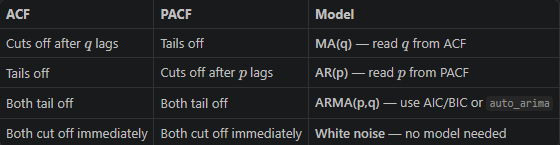

## 7.6 ARIMA(p, d, q)

**A**uto**R**egressive **I**ntegrated **M**oving **A**verage.

The "I" stands for **Integration** (differencing):

$$\Phi(B)(1-B)^d y_t = c + \Theta(B) \epsilon_t$$

- $p$ = order of AR (from PACF)
- $d$ = number of differences needed for stationarity
- $q$ = order of MA (from ACF)

### How to choose p, d, q?

1. **d**: Difference until stationary (ADF test, usually $d \in \{0, 1, 2\}$)
2. **p**: Look at PACF of differenced series — lag where it cuts off
3. **q**: Look at ACF of differenced series — lag where it cuts off
4. **Alternatively**: Use AIC/BIC — lower is better

$$\text{AIC} = -2\ln(\hat{L}) + 2k$$
$$\text{BIC} = -2\ln(\hat{L}) + k\ln(n)$$

where $\hat{L}$ = maximized likelihood, $k$ = number of parameters, $n$ = sample size.

## 7.7 SARIMA(p, d, q)(P, D, Q, m)

Extends ARIMA with **seasonal** components:

$$\Phi_p(B) \tilde{\Phi}_P(B^m)(1-B)^d(1-B^m)^D y_t = c + \Theta_q(B) \tilde{\Theta}_Q(B^m) \epsilon_t$$

- $(p, d, q)$: Non-seasonal orders
- $(P, D, Q)$: Seasonal orders
- $m$: Seasonal period (e.g., 12 for monthly, 4 for quarterly)

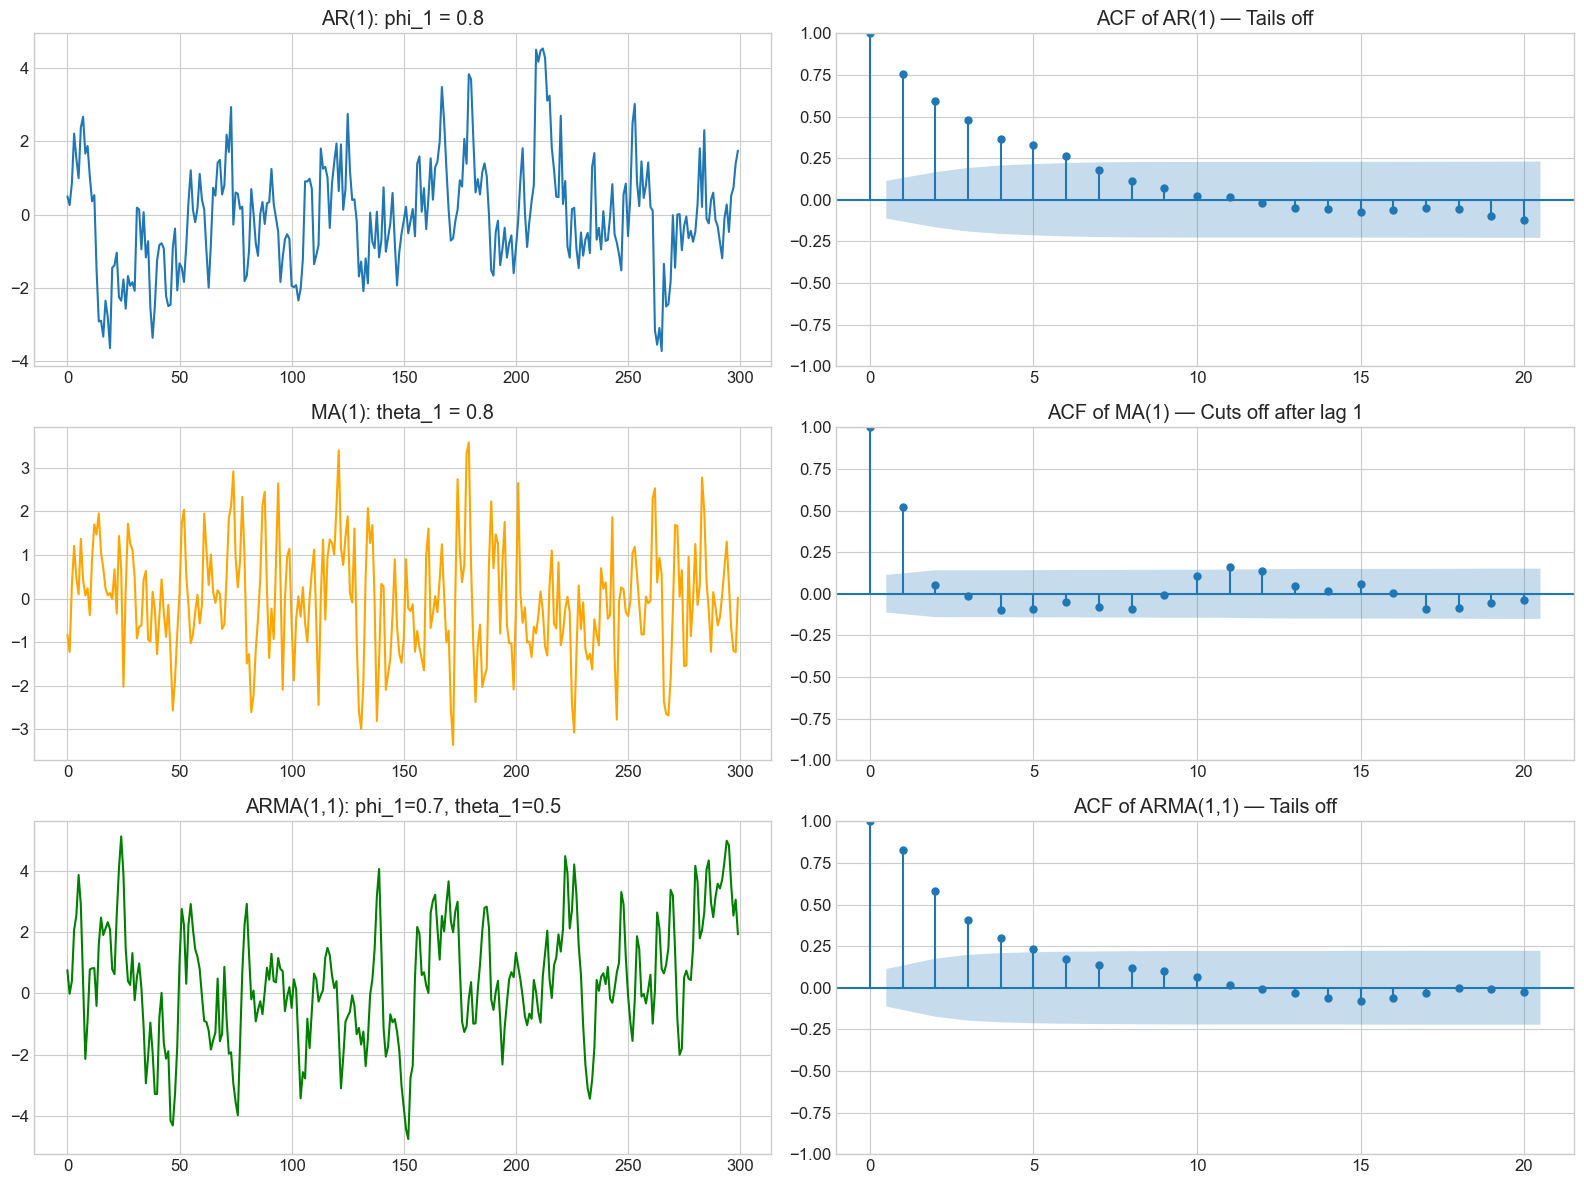

In [21]:
# 7.8 Simulating AR, MA, ARMA processes

from statsmodels.tsa.arima_process import ArmaProcess

np.random.seed(42)

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# AR(1): y_t = 0.8 * y_{t-1} + e_t
ar1 = ArmaProcess(ar=[1, -0.8], ma=[1]).generate_sample(300)
axes[0, 0].plot(ar1)
axes[0, 0].set_title('AR(1): phi_1 = 0.8')
plot_acf(ar1, lags=20, ax=axes[0, 1], title='ACF of AR(1) — Tails off')

# MA(1): y_t = e_t + 0.8 * e_{t-1}
ma1 = ArmaProcess(ar=[1], ma=[1, 0.8]).generate_sample(300)
axes[1, 0].plot(ma1, color='orange')
axes[1, 0].set_title('MA(1): theta_1 = 0.8')
plot_acf(ma1, lags=20, ax=axes[1, 1], title='ACF of MA(1) — Cuts off after lag 1')

# ARMA(1,1): y_t = 0.7*y_{t-1} + e_t + 0.5*e_{t-1}
arma11 = ArmaProcess(ar=[1, -0.7], ma=[1, 0.5]).generate_sample(300)
axes[2, 0].plot(arma11, color='green')
axes[2, 0].set_title('ARMA(1,1): phi_1=0.7, theta_1=0.5')
plot_acf(arma11, lags=20, ax=axes[2, 1], title='ACF of ARMA(1,1) — Tails off')

plt.tight_layout()
plt.show()

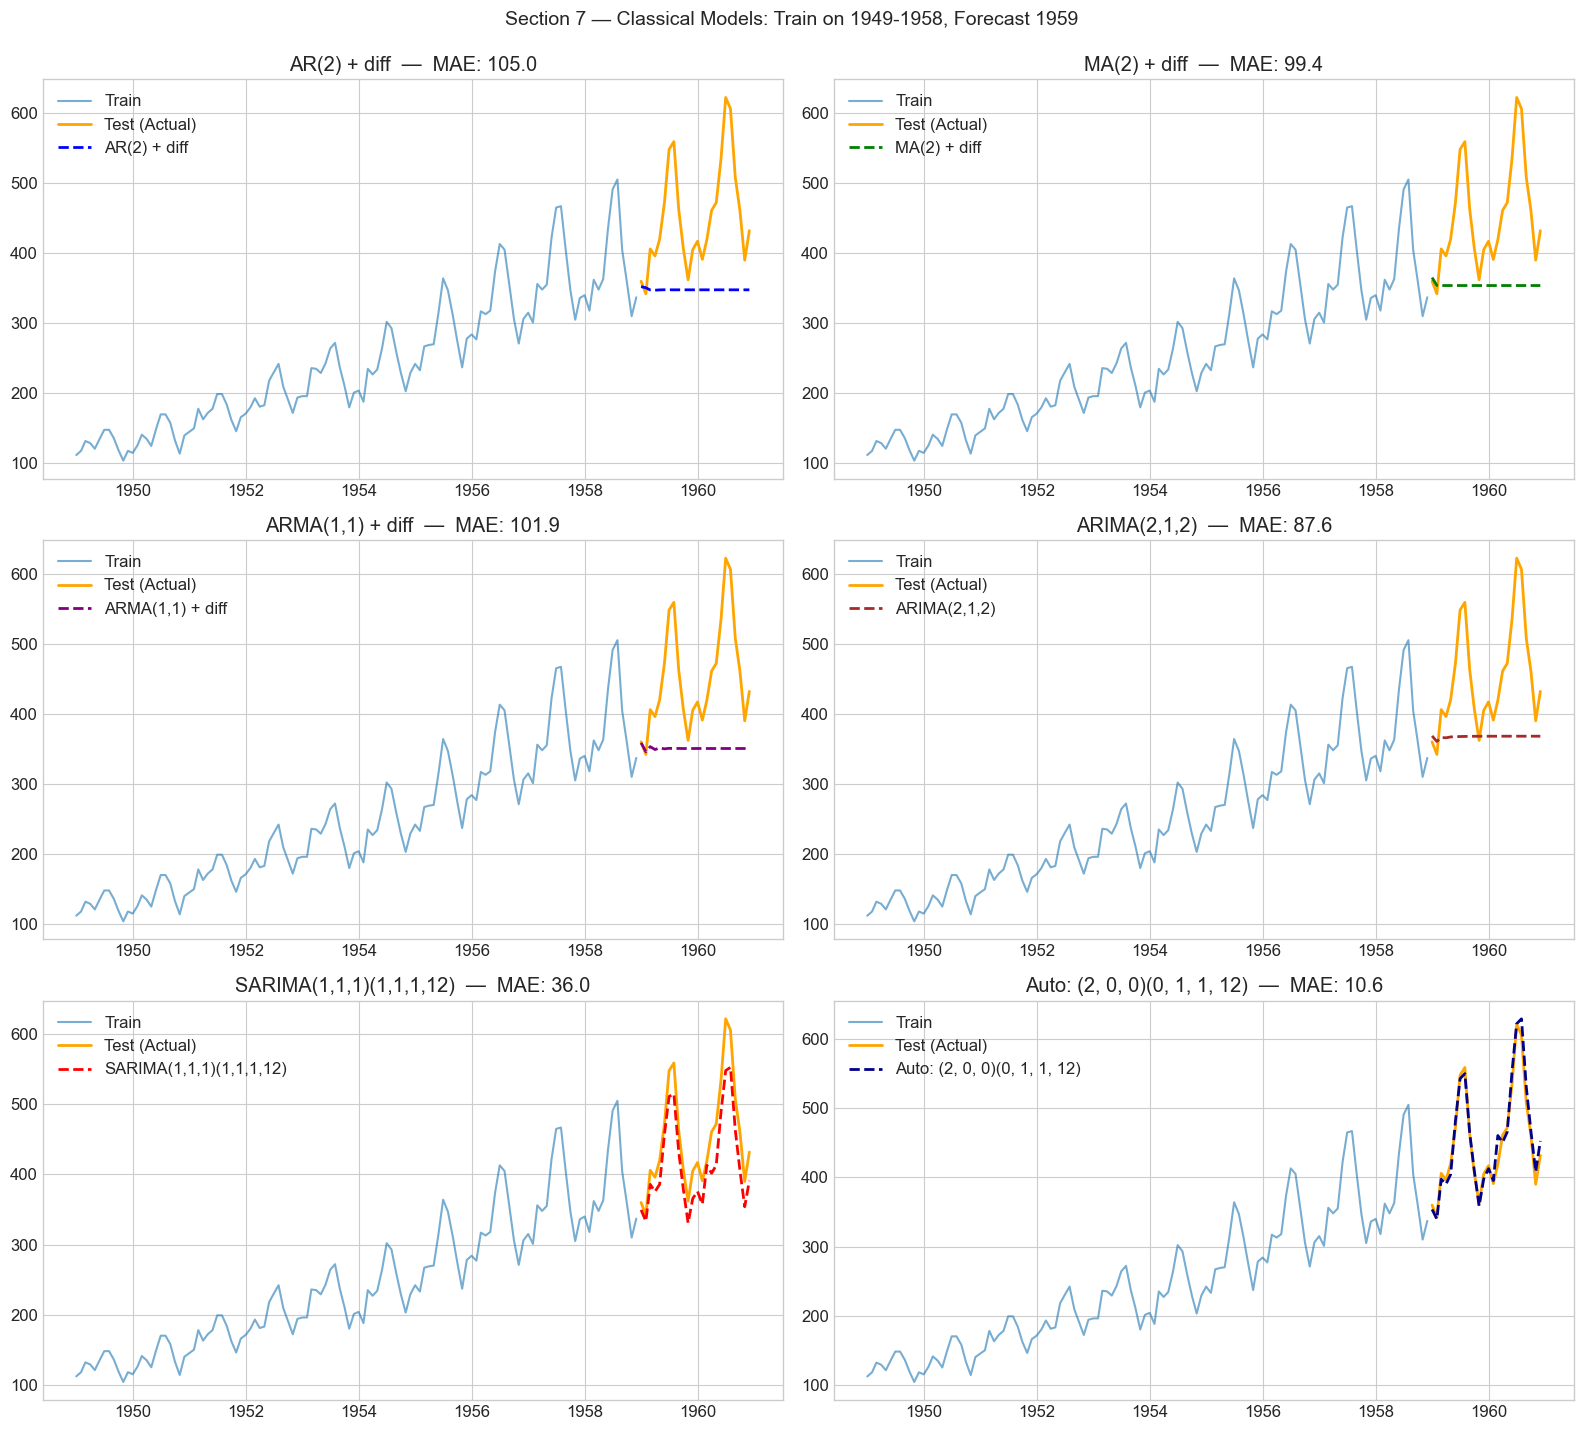


Model                                         MAE     RMSE
──────────────────────────────────────────────────────────
AR(2) + diff                               105.02   128.51
MA(2) + diff                                99.41   123.58
ARMA(1,1) + diff                           101.86   126.16
ARIMA(2,1,2)                                87.56   112.66
SARIMA(1,1,1)(1,1,1,12)                     36.05    39.79
Auto: (2, 0, 0)(0, 1, 1, 12)                10.61    14.15

Key observations:
  • AR/MA/ARMA without seasonal terms → can't capture seasonal peaks → high error
  • ARIMA slightly better (more flexible) but still no seasonality
  • SARIMA captures both trend + seasonality → lowest error
  • Auto ARIMA finds a good model automatically — compare with manual SARIMA


In [22]:
# 7.9 Classical Models — Train, Forecast & Compare (All Methods)
# Train on 1949-1958, forecast 1959 using AR, MA, ARMA, ARIMA, SARIMA + auto_arima

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pmdarima as pm

# --- Load & prepare data ---
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
df.columns = ['Passengers']
df.index.freq = 'MS'

passengers = df['Passengers']
log_passengers = np.log(passengers)

# Train/test split
train = passengers[:'1958']
test = passengers['1959':]
train_log = log_passengers[:'1958']
test_log = log_passengers['1959':]
h = len(test)

# --- Fit all models ---
models = {}

# 1. AR(2) — on log-differenced (stationary) data, then invert
model_ar = ARIMA(train_log, order=(2, 1, 0))  # p=2, d=1 (differencing), q=0
result_ar = model_ar.fit()
fc_ar = np.exp(result_ar.forecast(h))
models['AR(2) + diff'] = fc_ar

# 2. MA(2) — on log-differenced data
model_ma = ARIMA(train_log, order=(0, 1, 2))  # p=0, d=1, q=2
result_ma = model_ma.fit()
fc_ma = np.exp(result_ma.forecast(h))
models['MA(2) + diff'] = fc_ma

# 3. ARMA(1,1) — on log-differenced data
model_arma = ARIMA(train_log, order=(1, 1, 1))  # p=1, d=1, q=1
result_arma = model_arma.fit()
fc_arma = np.exp(result_arma.forecast(h))
models['ARMA(1,1) + diff'] = fc_arma

# 4. ARIMA(1,1,1) — same as ARMA but explicitly named
# (already covered above — skipping duplicate, using ARIMA(2,1,2) instead for variety)
model_arima = ARIMA(train_log, order=(2, 1, 2))
result_arima = model_arima.fit()
fc_arima = np.exp(result_arima.forecast(h))
models['ARIMA(2,1,2)'] = fc_arima

# 5. SARIMA(1,1,1)(1,1,1,12) — the gold standard
model_sarima = SARIMAX(train_log, order=(1,1,1), seasonal_order=(1,1,1,12))
result_sarima = model_sarima.fit(disp=False)
fc_sarima = np.exp(result_sarima.forecast(h))
models['SARIMA(1,1,1)(1,1,1,12)'] = fc_sarima

# 6. Auto ARIMA — let pmdarima find the best model automatically
auto_model = pm.auto_arima(train_log, seasonal=True, m=12, stepwise=True, suppress_warnings=True)
fc_auto = np.exp(pd.Series(auto_model.predict(h), index=test.index))
models[f'Auto: {auto_model.order}{auto_model.seasonal_order}'] = fc_auto

# --- Plot all forecasts (3x2 grid) ---
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
colors = ['blue', 'green', 'purple', 'brown', 'red', 'darkblue']

for idx, (name, fc) in enumerate(models.items()):
    row, col = divmod(idx, 2)
    axes[row, col].plot(train, label='Train', alpha=0.6)
    axes[row, col].plot(test, label='Test (Actual)', color='orange', linewidth=2)
    axes[row, col].plot(fc, label=name, color=colors[idx], linestyle='--', linewidth=2)
    axes[row, col].legend()
    mae = mean_absolute_error(test, fc)
    axes[row, col].set_title(f'{name}  —  MAE: {mae:.1f}')

plt.tight_layout()
plt.suptitle('Section 7 — Classical Models: Train on 1949-1958, Forecast 1959', y=1.02, fontsize=14)
plt.show()

# --- Error comparison table ---
print(f"\n{'Model':<40} {'MAE':>8} {'RMSE':>8}")
print(f"{'─'*58}")
for name, fc in models.items():
    mae = mean_absolute_error(test, fc)
    rmse = np.sqrt(mean_squared_error(test, fc))
    print(f"{name:<40} {mae:>8.2f} {rmse:>8.2f}")

print(f"\nKey observations:")
print(f"  • AR/MA/ARMA without seasonal terms → can't capture seasonal peaks → high error")
print(f"  • ARIMA slightly better (more flexible) but still no seasonality")
print(f"  • SARIMA captures both trend + seasonality → lowest error")
print(f"  • Auto ARIMA finds a good model automatically — compare with manual SARIMA")

### Observations — Classical Models Forecast (7.9)

All models trained on 1949–1958 (log-transformed), forecasted 1959, converted back with `exp()`.

**(a) AR(2) → Flat/decaying line.** AR captures momentum but with differencing (d=1) it just extrapolates the trend as a straight line. No seasonal pattern at all.

**(b) MA(2) → Also flat/decaying.** MA captures shock echoes but only for 2 periods. After that, the forecast snaps to the mean. No seasonality.

**(c) ARMA(1,1) → Marginally better.** Combines AR momentum + MA shock correction, but still no seasonal component. The forecast is a smooth line missing all the peaks.

**(d) ARIMA(2,1,2) → Similar to ARMA with more flexibility.** More parameters (p=2, q=2) give slightly better fit, but without seasonal terms it's still fundamentally unable to produce the summer peaks.

**(e) SARIMA → Best classical model.** Adding seasonal terms (P=1, D=1, Q=1, m=12) finally captures both the upward trend AND the repeating monthly pattern. Dramatic error reduction.

**(f) Auto ARIMA → Comparable to SARIMA.** `pmdarima` searches many (p,d,q)(P,D,Q,m) combinations and picks the one with lowest AIC. Usually finds a model close to or better than our manual SARIMA.

**Key takeaway:** For data with seasonality, non-seasonal models (AR/MA/ARMA/ARIMA) all fail — you MUST add seasonal terms (SARIMA) or use a method that handles seasonality natively (Holt-Winters, Prophet).

---
## 7.14 Which Time Series Method Should I Use? — A Decision Guide

We've covered many methods. Here's how to decide which one fits your data and problem.

## Quick Decision Flowchart

```
Is your data stationary (no trend, no seasonality)?
├── YES → Is there autocorrelation (ACF significant)?
│         ├── NO  → Data is white noise. No model needed.
│         └── YES → Use AR, MA, or ARMA (check ACF/PACF to pick)
│
└── NO  → Does it have a TREND?
          ├── YES, trend only (no repeating seasonal pattern)
          │   ├── Simple case → Holt's Double Exponential Smoothing
          │   └── Need residual modeling → ARIMA (differencing handles the trend)
          │
          └── YES, trend + SEASONALITY
              ├── Simple/quick forecast → Holt-Winters (additive or multiplicative)
              └── Need statistical rigor → SARIMA
```

## Detailed Comparison Table

| Method | Trend | Seasonality | Requires Stationary Input? | Best For | Strengths | Weaknesses | Industry Example |
|---|---|---|---|---|---|---|---|
| **SMA** (Simple Moving Average) | ✗ | ✗ | **No** — just averaging | Quick smoothing, noise removal | Dead simple, no parameters to tune | Lags behind the data; all past values weighted equally; can't forecast | **Retail:** Smoothing daily POS sales to see if overall footfall is stable this week |
| **WMA** (Weighted Moving Average) | ✗ | ✗ | **No** — just weighted averaging | Smoothing with more weight to recent data | More responsive than SMA; domain-driven weights possible | Still can't forecast beyond a flat line; weights are manually chosen, not optimized | **Supply chain:** Smoothing weekly demand where recent weeks matter more than older ones |
| **SES** (Simple Exponential Smoothing) | ✗ | ✗ | **No** — no statistical assumptions | Short-term forecast of stable data | One parameter (α); gives more weight to recent data; α is auto-optimized | Forecasts a flat line — useless if data trends up/down | **Inventory:** Forecasting demand for a commodity item (e.g., salt, sugar) whose sales stay roughly flat month-to-month |
| **Holt's** (Double Exponential) | ✓ | ✗ | **No** — explicitly models trend | Data with a clear upward/downward trend but no repeating pattern | Captures trend direction and speed | Misses seasonal peaks and dips entirely | **SaaS startup:** Forecasting monthly recurring revenue that's growing steadily but hasn't existed long enough to show seasonal patterns |
| **Holt-Winters** (Triple Exponential) | ✓ | ✓ | **No** — explicitly models trend + seasonality | Data with trend + repeating seasonal cycle | Handles both trend and seasonality; easy to implement; fast; has `seasonal='mul'` for growing variance | Assumes fixed seasonal period; can't model complex residual patterns | **Hotels:** Forecasting room bookings — rising overall popularity (trend) with summer peaks every year (seasonality) |
| **AR(p)** (AutoRegressive) | ✗ | ✗ | **Yes** — parameters estimated from autocorrelation which assumes constant variance/mean | Stationary data where current value depends on recent past values | Captures momentum/inertia in the data | Requires stationarity; can't handle trend or seasonality alone | **Finance:** Modeling daily stock returns (already stationary) where yesterday's return partially predicts today's |
| **MA(q)** (Moving Average model) | ✗ | ✗ | **Yes** — error structure assumes constant properties | Stationary data with short-lived shock effects | Good at capturing sudden shocks that fade out | Requires stationarity; limited memory (only q past shocks) | **Customer support:** Modeling call volume after a product recall — a spike that gradually fades back to normal |
| **ARMA(p,q)** | ✗ | ✗ | **Yes** — combines AR + MA, both need stationarity | Stationary data with both momentum and shock effects | Combines strengths of AR and MA | Still requires stationarity; choosing p and q can be tricky | **Manufacturing:** Modeling machine sensor readings (temperature fluctuations around a set point) with both inertia and random disturbances |
| **ARIMA(p,d,q)** | ✓ | ✗ | **No** (input) — `d` differences internally to achieve stationarity; may need `log()` for variance | Non-stationary data with trend (no fixed seasonality) | Differencing makes non-stationary data stationary, then models it | Can't capture seasonality; may need log transform for changing variance | **Economics:** Forecasting quarterly GDP growth — has a trend, no strong fixed seasonal cycle |
| **SARIMA(p,d,q)(P,D,Q,m)** | ✓ | ✓ | **No** (input) — `d` + `D` handle trend + seasonal non-stationarity internally; needs `log()` for multiplicative variance | Non-stationary data with both trend and seasonality | The gold standard for classical time series; handles everything | More parameters to tune (7 total); slower to fit; needs enough data (2+ seasonal cycles) | **Airlines:** Forecasting monthly passenger count — upward trend + summer peaks + growing amplitude (log + SARIMA) |

> **Key insight:** Smoothing models (Section 6) never need stationarity — they're designed to work with trends and seasonality directly. AR/MA/ARMA (Section 7) require stationary input. ARIMA/SARIMA bridge the gap by doing differencing internally.

## When to Use Smoothing vs Statistical Models?

| Question | Smoothing (SMA/SES/Holt/HW) | Statistical (AR/MA/ARIMA/SARIMA) |
|---|---|---|
| **Do I need quick results with minimal setup?** | ✓ Yes — few or no parameters | Needs careful stationarity checks, ACF/PACF analysis |
| **Do I need confidence intervals?** | Limited | ✓ Yes — built-in prediction intervals |
| **Do I care about residual patterns?** | No residual analysis | ✓ Yes — Ljung-Box test, residual diagnostics |
| **Is my data short (< 2 seasonal cycles)?** | ✓ Works with less data | SARIMA needs 2+ full cycles minimum |
| **Do I need to explain the model to a business stakeholder?** | ✓ Very easy to explain | Harder — "backshift operators" don't land well in meetings |
| **Is forecast accuracy critical?** | Good baseline | ✓ Usually more accurate with proper tuning |

## Rule of Thumb — Start Simple, Add Complexity Only When Needed

1. **Always start** with a naive baseline (repeat last value, or same month last year)
2. **Try Holt-Winters** if you see trend + seasonality — it's fast and often surprisingly good
3. **Move to SARIMA** if Holt-Winters residuals show patterns (significant ACF spikes) — SARIMA can capture what HW misses
4. **Use auto_arima** (`pmdarima`) if you don't want to manually pick p, d, q
5. **Consider ML models** (XGBoost, Prophet) only when classical models plateau or you have external features (holidays, promotions, weather)

---
## 7.15 Holt's vs ARIMA — Same Data, Different Brain

**Data:** Monthly sales = 100, 110, 120, 130, 140

Both see the same thing: "sales are going up by ~10/month."

### How Holt's thinks:

> "OK, the current level is 140 and the slope is +10. So next month = 140 + 10 = **150**."

It literally keeps two numbers in its head — WHERE (level = 140) and HOW FAST (trend = +10) — and updates them each month. That's it. No equations, no stationarity, no differencing.

### How ARIMA thinks:

> "Let me first convert this to changes: +10, +10, +10, +10. Now these changes are stationary (constant around 10). I'll model THESE with AR/MA. Average change = 10. So next change = 10. Next value = 140 + 10 = **150**."

It first **transforms** the data (differencing), then models the transformed data with AR/MA, then converts back.

### Same answer (150). So why bother with ARIMA?

Because real data isn't this clean. What if the changes are: **+10, +15, +8, +12**?

**Holt's:** Just smoothly tracks the trend: "slope is somewhere around +11." Gives 151.

**ARIMA:** Can notice patterns IN the changes: "after a big change (+15), the next one is small (+8) — there's a negative autocorrelation in the differences." It uses AR/MA to model this pattern. Maybe gives 149 (because last change was +12, so next will likely be smaller).

**In other words:**
- Holt's sees: "it's going up by roughly 10-ish"
- ARIMA sees: "it's going up by roughly 10-ish, AND the ups and downs in the speed of going up have a pattern I can exploit"

### The Simplest Possible Summary

| | Holt's | ARIMA |
|---|---|---|
| **What it does** | Tracks level + slope directly | Removes the trend first, then models what's left |
| **Analogy** | "I'm on a hill going up at 10 mph" | "Let me flatten the hill, study the bumps, then put the hill back" |
| **Can see patterns in how the trend changes?** | No — just smoothly averages the slope | Yes — AR/MA models structure in the differenced series |
| **When it matters** | Doesn't matter if the trend is steady | Matters a lot if the trend speed varies in a predictable way |

If the trend is steady and predictable, both give similar forecasts and Holt's is easier. ARIMA's advantage only shows up when the *speed* of the trend has patterns that Holt's misses.

### Extending to Seasonality: Holt-Winters vs SARIMA

Same idea, just one more layer:
- **Holt-Winters** adds a seasonal component and tracks it with weighted averages. Handles multiplicative seasonality natively (`seasonal='mul'`).
- **SARIMA** does seasonal differencing first, then models what's left. Needs manual `log()` for multiplicative data.

### What SARIMA gives you that HW doesn't

| What you get | Holt-Winters | SARIMA |
|---|---|---|
| Point forecast (a number) | Yes | Yes |
| "I'm 95% sure it'll be between X and Y" | No (crude at best) | Yes |
| "My model captured everything — residuals are random" | Can't check | Yes (Ljung-Box test) |
| "This model is better than that one, objectively" | Compare MAE manually | AIC/BIC does it automatically |
| Works with 1 year of monthly data | Yes | No (needs 2+ years) |
| Setup time | 2 minutes | 20 minutes |

### When to use which — dead simple

- **Just need a quick forecast?** → Holt-Winters
- **Need to say "I'm 95% confident the forecast is between X and Y"?** → SARIMA
- **Less than 2 years of data?** → Holt-Winters (SARIMA can't fit properly)
- **Presenting to your manager?** → Holt-Winters (easier to explain)
- **Publishing a paper or need rigorous validation?** → SARIMA

**In practice:** Most people try HW first. If the MAE is good enough, they stop. If not, they move to SARIMA.

# 8. Family 3: Curve-Fitting / Additive Models

---

## 8.1 Facebook Prophet

Prophet is an additive model developed by Meta (Facebook):

$$y(t) = g(t) + s(t) + h(t) + \epsilon_t$$

- $g(t)$: **Growth function** (linear or logistic)
- $s(t)$: **Seasonality** (Fourier series)
- $h(t)$: **Holiday effects**
- $\epsilon_t$: **Error term**

### Growth Models:

**Linear growth:**
$$g(t) = kt + m$$
where $k$ = growth rate, $m$ = offset. Prophet can detect **changepoints** where $k$ changes.

**Logistic growth (saturating):**
$$g(t) = \frac{C}{1 + \exp(-k(t - m))}$$
where $C$ = carrying capacity.

### Seasonality in Prophet (Fourier series):

$$s(t) = \sum_{n=1}^{N}\left(a_n \cos\left(\frac{2\pi nt}{P}\right) + b_n \sin\left(\frac{2\pi nt}{P}\right)\right)$$

where $P$ = period (365.25 for yearly, 7 for weekly).

**Advantages:** Handles missing data, outliers, holidays, changepoints automatically. Minimal tuning needed.

---

## 8.2 VAR (Vector AutoRegression)

For **multivariate** time series (multiple related series):

$$\mathbf{y}_t = \mathbf{c} + \mathbf{A}_1 \mathbf{y}_{t-1} + \mathbf{A}_2 \mathbf{y}_{t-2} + \cdots + \mathbf{A}_p \mathbf{y}_{t-p} + \mathbf{u}_t$$

where $\mathbf{y}_t$ is a vector of $K$ time series, $\mathbf{A}_i$ are $K \times K$ coefficient matrices.

### Example: VAR(1) with 2 variables

$$\begin{bmatrix} y_{1,t} \\ y_{2,t} \end{bmatrix} = \begin{bmatrix} c_1 \\ c_2 \end{bmatrix} + \begin{bmatrix} a_{11} & a_{12} \\ a_{21} & a_{22} \end{bmatrix} \begin{bmatrix} y_{1,t-1} \\ y_{2,t-1} \end{bmatrix} + \begin{bmatrix} u_{1,t} \\ u_{2,t} \end{bmatrix}$$

**Use case:** When multiple series influence each other (e.g., GDP, inflation, unemployment).

### Granger Causality

Tests if one time series is useful in forecasting another. "$X$ Granger-causes $Y$" if past values of $X$ help predict $Y$ beyond what past values of $Y$ alone can.

19:43:51 - cmdstanpy - INFO - Chain [1] start processing
19:43:52 - cmdstanpy - INFO - Chain [1] done processing


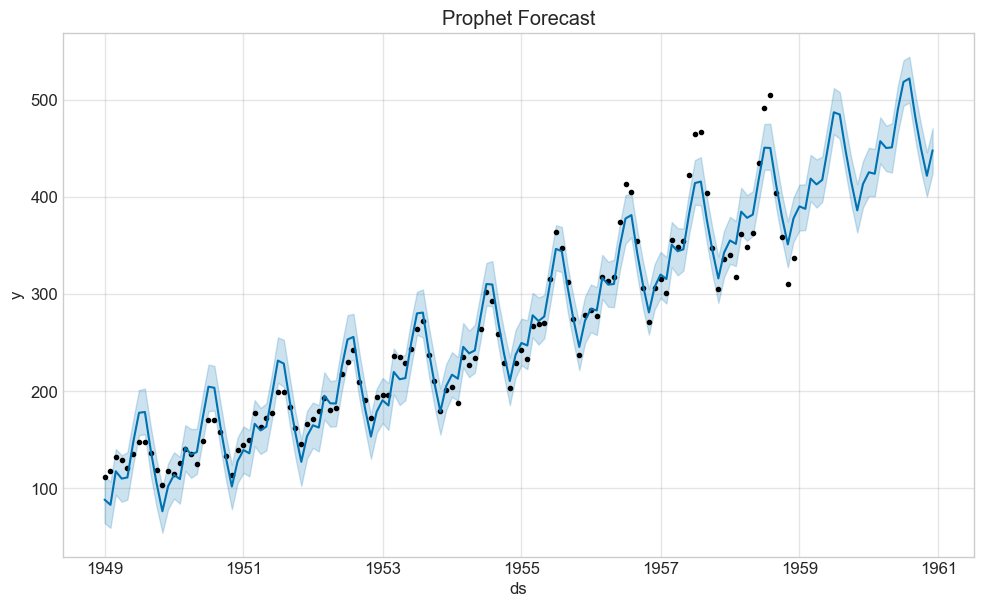

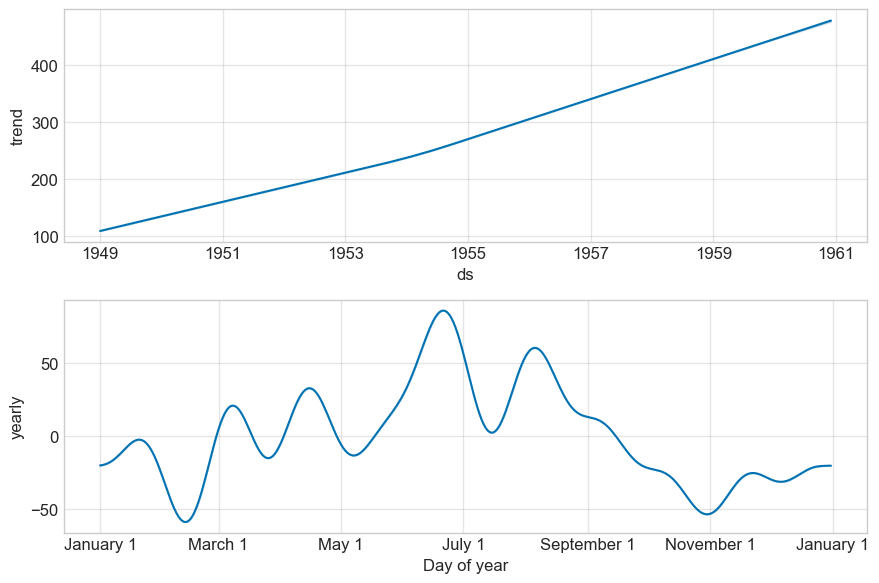


Prophet MAE:  31.16
Prophet RMSE: 40.40


In [23]:
# 8.1 Facebook Prophet — Forecast

from prophet import Prophet

# Prophet requires columns: 'ds' (datestamp) and 'y' (value)
df_prophet = passengers.reset_index()
df_prophet.columns = ['ds', 'y']

# Split
train_prophet = df_prophet[df_prophet['ds'] < '1959-01-01']
test_prophet = df_prophet[df_prophet['ds'] >= '1959-01-01']

# Fit Prophet
m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(train_prophet)

# Predict
future = m.make_future_dataframe(periods=len(test_prophet), freq='MS')
forecast = m.predict(future)

# Plot
fig = m.plot(forecast)
plt.title('Prophet Forecast')
plt.show()

# Components
fig2 = m.plot_components(forecast)
plt.show()

# Evaluate
pred_prophet = forecast[forecast['ds'] >= '1959-01-01']['yhat'].values
print(f"\nProphet MAE:  {mean_absolute_error(test_prophet['y'], pred_prophet):.2f}")
print(f"Prophet RMSE: {np.sqrt(mean_squared_error(test_prophet['y'], pred_prophet)):.2f}")

Optimal lag orders by criterion:
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -6.685      -6.634    0.001249      -6.664
1       -9.179      -9.026   0.0001032      -9.117
2       -9.185      -8.931   0.0001026      -9.082
3       -9.207      -8.851   0.0001004      -9.063
4       -9.203      -8.746   0.0001008      -9.018
5       -9.276      -8.716   9.381e-05      -9.049
6       -9.260      -8.598   9.545e-05      -8.992
7       -9.239      -8.477   9.754e-05      -8.930
8       -9.302      -8.437   9.180e-05      -8.952
9       -9.434      -8.468   8.063e-05      -9.042
10      -9.420      -8.352   8.201e-05      -8.987
11      -9.928      -8.758   4.952e-05      -9.454
12      -10.21      -8.936   3.760e-05      -9.693
13      -10.65     -9.272*   2.440e-05     -10.09*
14     -10.66*      -9.181  2.430e-05*      -10.06
15      -10.60      -9.020   2.596e-05      -9.95

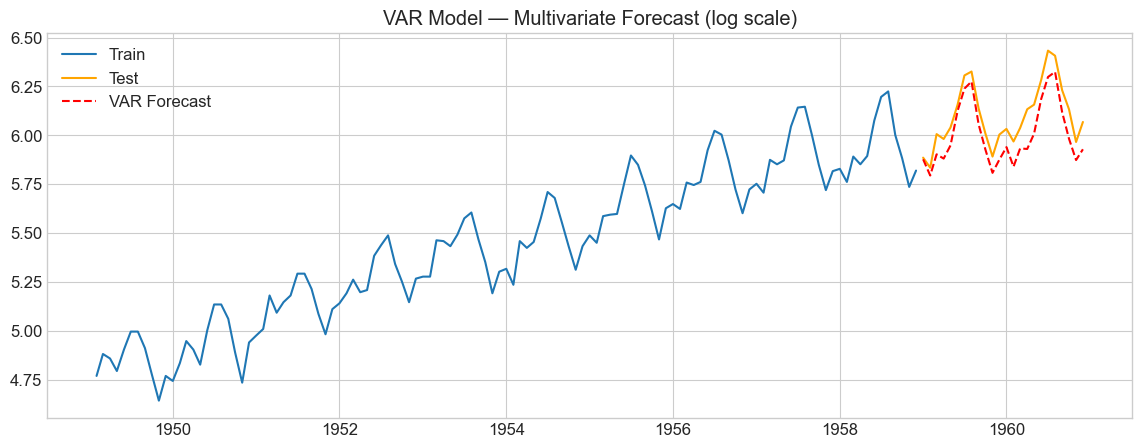


VAR Test MAE:  42.30
VAR Test RMSE: 46.28


In [24]:
# 8.2 VAR — Vector AutoRegression (Multivariate Example)

from statsmodels.tsa.api import VAR

# Create a multivariate dataset: Passengers + a synthetic related series
np.random.seed(42)
log_pass = np.log(passengers)
# Simulate a correlated "cargo" series: influenced by passengers + its own dynamics
cargo = 0.6 * log_pass + 0.4 * log_pass.shift(1) + np.random.normal(0, 0.1, len(log_pass))
df_var = pd.DataFrame({
    'passengers': log_pass,
    'cargo': cargo
}).dropna()

# Split
train_var = df_var[:'1958']
test_var = df_var['1959':]

# Fit VAR
model_var = VAR(train_var)
# Select optimal lag order
lag_order = model_var.select_order(maxlags=15)
print("Optimal lag orders by criterion:")
print(lag_order.summary())

# Fit with AIC-optimal lag
var_result = model_var.fit(lag_order.aic)
print(f"\nFitted VAR({var_result.k_ar})")

# Forecast
forecast_var = var_result.forecast(train_var.values[-var_result.k_ar:], steps=len(test_var))
forecast_var_df = pd.DataFrame(forecast_var, index=test_var.index, columns=df_var.columns)

plt.figure(figsize=(14, 5))
plt.plot(train_var['passengers'], label='Train')
plt.plot(test_var['passengers'], label='Test', color='orange')
plt.plot(forecast_var_df['passengers'], label='VAR Forecast', color='red', linestyle='--')
plt.legend()
plt.title('VAR Model — Multivariate Forecast (log scale)')
plt.show()

# --- Metrics (convert back from log scale) ---
var_pred_actual = np.exp(forecast_var_df['passengers'])
test_actual = np.exp(test_var['passengers'])
mae_var = mean_absolute_error(test_actual, var_pred_actual)
rmse_var = np.sqrt(mean_squared_error(test_actual, var_pred_actual))
print(f"\nVAR Test MAE:  {mae_var:.2f}")
print(f"VAR Test RMSE: {rmse_var:.2f}")

# 9. Family 4: Machine Learning Models

---

When using **ML models** (e.g., XGBoost, Random Forest) for time series, we need to manually create time-dependent features since these models do not inherently understand temporal order.

## 9.1 Lag Features

$$X_{\text{lag}_k}(t) = y_{t-k}$$

Create features from past values: $y_{t-1}, y_{t-2}, \ldots, y_{t-k}$

**Why it works:** If $y_t$ is correlated with $y_{t-1}$ (which ACF tells us), then $y_{t-1}$ is a useful predictor.

**Caution:** Must only use past values! Using future values = **data leakage**.

## 9.2 Rolling Window Features

$$X_{\text{rolling\_mean}}(t) = \frac{1}{k}\sum_{i=1}^{k} y_{t-i}$$

$$X_{\text{rolling\_std}}(t) = \sqrt{\frac{1}{k-1}\sum_{i=1}^{k} (y_{t-i} - \bar{y})^2}$$

Also: rolling min, rolling max, rolling median, expanding mean.

**Important:** Always use `.shift(1)` before `.rolling()` to avoid leakage!

## 9.3 Date-Based Features

Extract calendar features: day of week, month, quarter, year, day of year, week number, is_weekend, is_holiday.

These help the model learn **seasonality** without explicit lag features.

## 9.4 Fourier Terms for Seasonality

For capturing complex seasonal patterns using Fourier series:

$$X_{\sin,k}(t) = \sin\left(\frac{2\pi k t}{m}\right), \quad X_{\cos,k}(t) = \cos\left(\frac{2\pi k t}{m}\right)$$

where $m$ is the seasonal period and $k = 1, 2, \ldots, K$ (number of harmonics).

**Why Fourier?** Any periodic function can be represented as a sum of sines and cosines (Fourier theorem). $K$ harmonics can capture increasingly complex seasonal shapes.

In [25]:
# 9.5 Feature Engineering — Code Example

def create_ts_features(df, target_col, lags=[1,2,3,6,12], windows=[3,6,12]):
    """Create comprehensive time series features."""
    data = df.copy()
    
    # --- Lag Features ---
    for lag in lags:
        data[f'lag_{lag}'] = data[target_col].shift(lag)
    
    # --- Rolling Window Features ---
    for window in windows:
        data[f'rolling_mean_{window}'] = data[target_col].shift(1).rolling(window).mean()
        data[f'rolling_std_{window}'] = data[target_col].shift(1).rolling(window).std()
        data[f'rolling_min_{window}'] = data[target_col].shift(1).rolling(window).min()
        data[f'rolling_max_{window}'] = data[target_col].shift(1).rolling(window).max()
    
    # --- Date-Based Features ---
    data['month'] = data.index.month
    data['quarter'] = data.index.quarter
    data['year'] = data.index.year
    data['day_of_year'] = data.index.dayofyear
    
    # --- Fourier Terms (seasonality) ---
    m = 12  # monthly seasonality
    for k in range(1, 4):  # 3 harmonics
        data[f'sin_{k}'] = np.sin(2 * np.pi * k * data.index.month / m)
        data[f'cos_{k}'] = np.cos(2 * np.pi * k * data.index.month / m)
    
    return data

# Apply to Air Passengers
df_features = create_ts_features(df[['Passengers']], 'Passengers')
df_features.dropna(inplace=True)
print(f"Shape after feature engineering: {df_features.shape}")
print(f"\nFeature columns ({len(df_features.columns)-1} features):")
print([c for c in df_features.columns if c != 'Passengers'])
df_features.head()

Shape after feature engineering: (132, 28)

Feature columns (27 features):
['lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'rolling_mean_3', 'rolling_std_3', 'rolling_min_3', 'rolling_max_3', 'rolling_mean_6', 'rolling_std_6', 'rolling_min_6', 'rolling_max_6', 'rolling_mean_12', 'rolling_std_12', 'rolling_min_12', 'rolling_max_12', 'month', 'quarter', 'year', 'day_of_year', 'sin_1', 'cos_1', 'sin_2', 'cos_2', 'sin_3', 'cos_3']


,Passengers,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_mean_3,rolling_std_3,rolling_min_3,rolling_max_3,...,month,quarter,year,day_of_year,sin_1,cos_1,sin_2,cos_2,sin_3,cos_3
Month,,,,,,,,,,,,,,,,,,,,,
1950-01-01,115,118.0,104.0,119.0,148.0,112.0,113.666667,8.386497,104.0,119.0,...,1,1,1950,1,0.500000,8.660254e-01,8.660254e-01,0.5,1.000000e+00,6.123234e-17
1950-02-01,126,115.0,118.0,104.0,148.0,118.0,112.333333,7.371115,104.0,118.0,...,2,1,1950,32,0.866025,5.000000e-01,8.660254e-01,-0.5,1.224647e-16,-1.000000e+00
1950-03-01,141,126.0,115.0,118.0,136.0,132.0,119.666667,5.686241,115.0,126.0,...,3,1,1950,60,1.000000,6.123234e-17,1.224647e-16,-1.0,-1.000000e+00,-1.836970e-16
1950-04-01,135,141.0,126.0,115.0,119.0,129.0,127.333333,13.051181,115.0,141.0,...,4,2,1950,91,0.866025,-5.000000e-01,-8.660254e-01,-0.5,-2.449294e-16,1.000000e+00
1950-05-01,125,135.0,141.0,126.0,104.0,121.0,134.000000,7.549834,126.0,141.0,...,5,2,1950,121,0.500000,-8.660254e-01,-8.660254e-01,0.5,1.000000e+00,1.194340e-15


In [26]:
df_features.columns

Index(['Passengers', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12',
       'rolling_mean_3', 'rolling_std_3', 'rolling_min_3', 'rolling_max_3',
       'rolling_mean_6', 'rolling_std_6', 'rolling_min_6', 'rolling_max_6',
       'rolling_mean_12', 'rolling_std_12', 'rolling_min_12', 'rolling_max_12',
       'month', 'quarter', 'year', 'day_of_year', 'sin_1', 'cos_1', 'sin_2',
       'cos_2', 'sin_3', 'cos_3'],
      dtype='object')

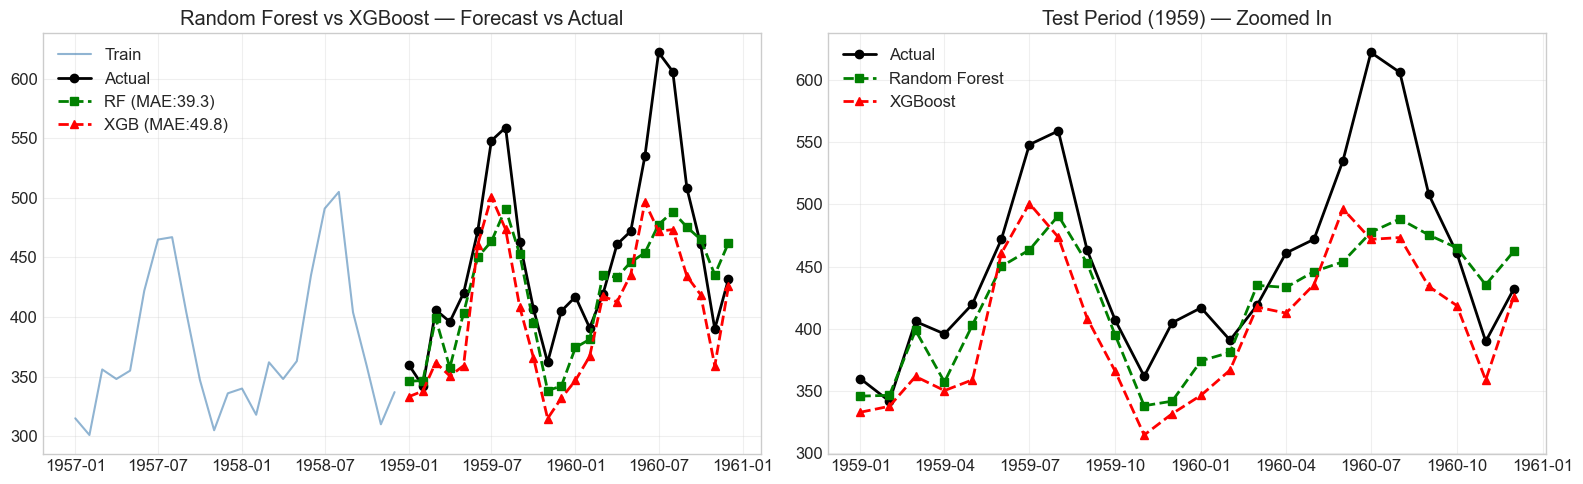

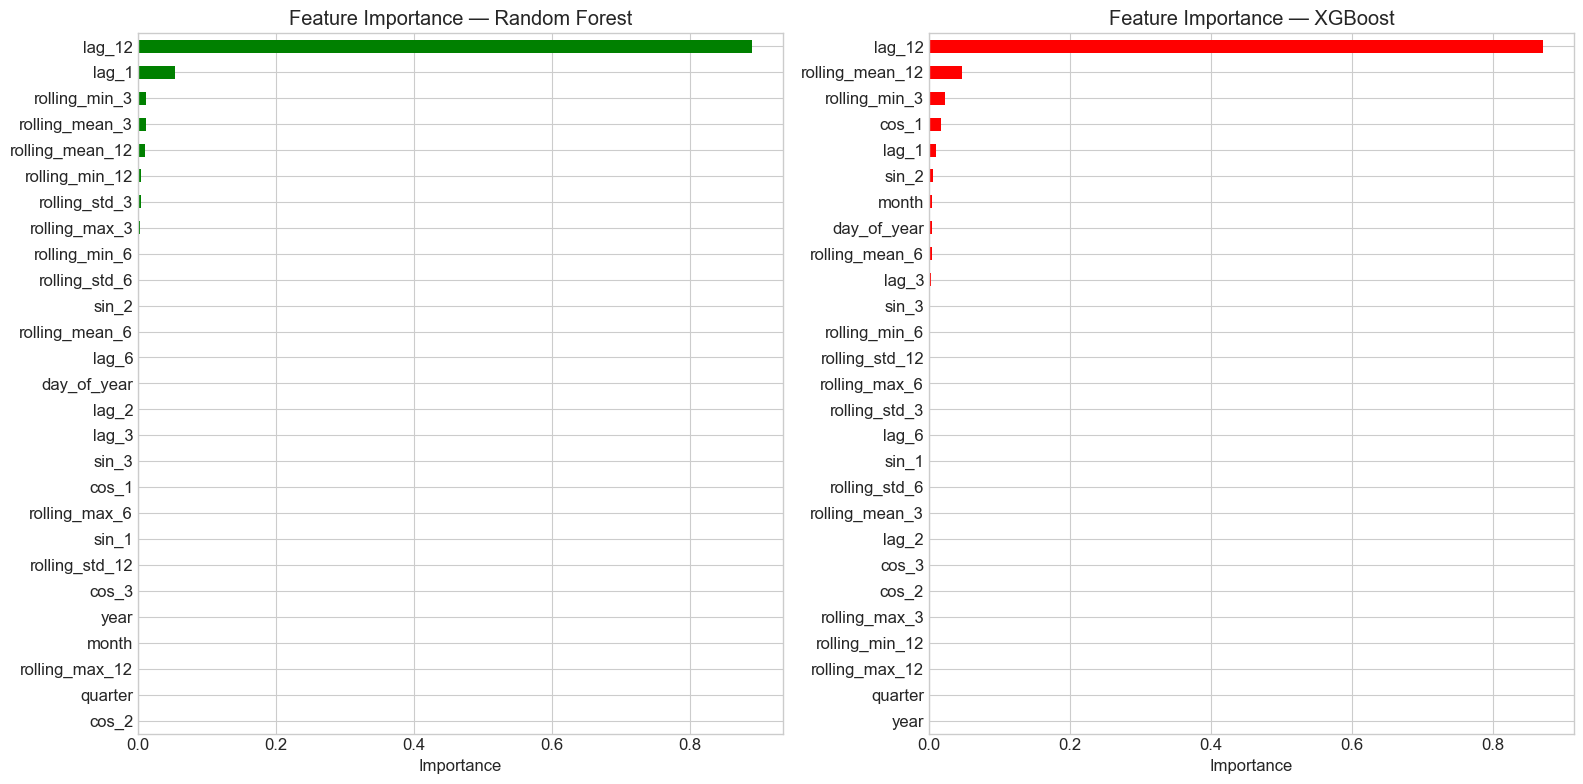


Model                     MAE     RMSE
──────────────────────────────────────
Random Forest           39.25    53.22
XGBoost                 49.83    61.01


In [27]:
# 9.6 Random Forest vs XGBoost — Train, Forecast, Feature Importance

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- Train/Test Split (1949-1958 train, 1959 test) ---
train_feat = df_features[df_features.index < '1959-01-01']
test_feat  = df_features[df_features.index >= '1959-01-01']

X_train = train_feat.drop('Passengers', axis=1).select_dtypes(include=[np.number])
y_train = train_feat['Passengers']
X_test  = test_feat.drop('Passengers', axis=1).select_dtypes(include=[np.number])
y_test  = test_feat['Passengers']

# --- Fit Both Models ---
rf_model = RandomForestRegressor(n_estimators=400, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = pd.Series(rf_model.predict(X_test), index=y_test.index)

xgb_model = XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.1, random_state=42, verbosity=0)
xgb_model.fit(X_train, y_train)
xgb_pred = pd.Series(xgb_model.predict(X_test), index=y_test.index)

# --- Metrics ---
mae_rf  = mean_absolute_error(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
mae_xgb  = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))

# --- Plot 1: Forecast Comparison ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(y_train['1957':], label='Train', color='steelblue', alpha=0.6)
axes[0].plot(y_test, label='Actual', color='black', linewidth=2, marker='o')
axes[0].plot(rf_pred, label=f'RF (MAE:{mae_rf:.1f})', color='green', linewidth=2, linestyle='--', marker='s')
axes[0].plot(xgb_pred, label=f'XGB (MAE:{mae_xgb:.1f})', color='red', linewidth=2, linestyle='--', marker='^')
axes[0].set_title('Random Forest vs XGBoost — Forecast vs Actual')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Zoomed test period
axes[1].plot(y_test, label='Actual', color='black', linewidth=2, marker='o')
axes[1].plot(rf_pred, label='Random Forest', color='green', linewidth=2, marker='s', linestyle='--')
axes[1].plot(xgb_pred, label='XGBoost', color='red', linewidth=2, marker='^', linestyle='--')
axes[1].set_title('Test Period (1959) — Zoomed In')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Plot 2: Feature Importance Side by Side ---
rf_importance  = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)
xgb_importance = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
rf_importance.plot(kind='barh', color='green', ax=axes[0])
axes[0].set_title('Feature Importance — Random Forest')
axes[0].set_xlabel('Importance')

xgb_importance.plot(kind='barh', color='red', ax=axes[1])
axes[1].set_title('Feature Importance — XGBoost')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

# --- Metrics Table ---
print(f"\n{'Model':<20} {'MAE':>8} {'RMSE':>8}")
print(f"{'─'*38}")
print(f"{'Random Forest':<20} {mae_rf:>8.2f} {rmse_rf:>8.2f}")
print(f"{'XGBoost':<20} {mae_xgb:>8.2f} {rmse_xgb:>8.2f}")

# 10. Family 5: Deep Learning — Sequential Modeling with LSTM

---

## Why Deep Learning for Sequential Data?

Families 1–4 (Smoothing, ARIMA, Prophet, XGBoost) work great for **numeric time series** — predicting the next number in a sequence. But many real-world problems aren't about numbers:

- **Next product a customer will buy** (sequence of product IDs)
- **Next movie a user will watch** (sequence of movie IDs)
- **Next word in a sentence** (NLP — same architecture!)

These are **sequential prediction** problems where the input is an ordered sequence of **categorical items**, not numeric values. XGBoost can't handle this — it needs tabular features. ARIMA needs numeric data. **LSTMs and Transformers are built for this.**

---

## 10.1 RNN — The Foundation

A **Recurrent Neural Network** processes sequences by maintaining a hidden state that acts as memory:

$$h_t = \tanh(W_{hh} \cdot h_{t-1} + W_{xh} \cdot x_t + b_h)$$

$$\hat{y}_t = W_{hy} \cdot h_t + b_y$$

At each time step, the hidden state $h_t$ is a function of:
- The **previous hidden state** $h_{t-1}$ (memory of what came before)
- The **current input** $x_t$ (what's happening now)

**Problem:** Vanilla RNNs suffer from the **vanishing gradient problem** — during backpropagation, gradients shrink exponentially through time steps, so the network "forgets" things from more than ~10 steps ago.

---

## 10.2 LSTM — Long Short-Term Memory

LSTM fixes the vanishing gradient by adding a **cell state** $C_t$ — a highway that carries information across many time steps with minimal loss.

### The Three Gates

**Forget gate** — "What should I throw away from memory?"

$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$

Output is between 0 (forget everything) and 1 (keep everything). E.g., if the customer just bought a phone, forget that they were browsing TVs.

**Input gate** — "What new information should I store?"

$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$
$$\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$$

$i_t$ decides how much to write, $\tilde{C}_t$ is the candidate new memory.

**Output gate** — "What part of my memory should I output right now?"

$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$

### Cell State Update

$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

Old memory × forget gate + new info × input gate. The $\odot$ is element-wise multiplication.

### Hidden State (Output)

$$h_t = o_t \odot \tanh(C_t)$$

### Why This Solves Vanishing Gradients

The cell state $C_t$ is updated via **addition** (not multiplication), so gradients flow through without shrinking. The forget gate can learn to keep $f_t \approx 1$, letting information persist for hundreds of steps.

---

## 10.3 GRU — Gated Recurrent Unit

A simpler alternative to LSTM with only **2 gates** instead of 3:

$$z_t = \sigma(W_z \cdot [h_{t-1}, x_t])  \quad \text{(update gate — combine old + new)}$$
$$r_t = \sigma(W_r \cdot [h_{t-1}, x_t])  \quad \text{(reset gate — how much past to forget)}$$
$$h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tanh(W \cdot [r_t \odot h_{t-1}, x_t])$$

GRU is faster to train and often performs comparably to LSTM. Use GRU when you want speed; use LSTM when you need to capture very long-range dependencies.

---

## 10.4 Transformer — Attention Is All You Need

LSTMs process sequences **one step at a time** (left to right). This is slow and makes it hard to capture dependencies between items far apart. **Transformers** solve this by looking at **all positions simultaneously** using self-attention.

### Self-Attention — The Core Idea

For each item in the sequence, self-attention asks: "How much should I pay attention to every other item?"

Given input embeddings $X$, compute three matrices:
- **Query** $Q = XW_Q$ — "What am I looking for?"
- **Key** $K = XW_K$ — "What do I contain?"
- **Value** $V = XW_V$ — "What information do I carry?"

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

**Step by step:**
1. $QK^T$ — dot product of every query with every key → attention scores (how relevant is item $j$ to item $i$?)
2. $\div \sqrt{d_k}$ — scale down to prevent softmax from saturating
3. Softmax — normalize scores to sum to 1 (attention weights)
4. Multiply by $V$ — weighted sum of all values → each item gets a new representation informed by the entire sequence

**Analogy:** In a purchase sequence [Phone, Case, Charger, Headphones], when predicting after "Headphones", attention might assign high weight to "Phone" (accessories follow phones) and low weight to "Charger" (already bought).

### Multi-Head Attention

Instead of one attention, run $h$ parallel attention heads with different learned $W_Q, W_K, W_V$. Each head learns different patterns:
- Head 1 might learn "what category was bought"
- Head 2 might learn "how recent was it"
- Head 3 might learn "price range similarity"

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h) W_O$$

### Positional Encoding

Transformers have no concept of order (unlike LSTMs). We add **positional encodings** to tell the model where each item is in the sequence:

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d}}\right), \quad PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d}}\right)$$

### LSTM vs Transformer

| | LSTM | Transformer |
|---|---|---|
| **Processes sequence** | Left to right, one step at a time | All positions at once (parallel) |
| **Long-range dependencies** | Hard — information must pass through every step | Easy — attention connects any two positions directly |
| **Training speed** | Slow (sequential, can't parallelize) | Fast (fully parallelizable on GPU) |
| **Memory** | Fixed hidden state (bottleneck) | Attention over full sequence (no bottleneck) |
| **Position awareness** | Built-in (order of processing) | Needs positional encoding |

---

## 10.5 BERT & BERT4Rec — Bidirectional Sequential Prediction

### BERT (Bidirectional Encoder Representations from Transformers)

Originally an NLP model, BERT introduced two key innovations:

1. **Bidirectional context** — Instead of predicting left-to-right (like GPT), BERT looks at **both past AND future context** simultaneously
2. **Masked Language Modeling (MLM)** — During training, randomly mask some tokens and predict them from surrounding context

$$\text{Input: } [\text{Phone}, \text{[MASK]}, \text{Charger}, \text{Headphones}]$$
$$\text{Task: predict [MASK] = Case}$$

The model learns to fill in the blank using both left context (Phone) and right context (Charger, Headphones).

### BERT4Rec — BERT for Sequential Recommendation

[BERT4Rec (Sun et al., 2019)](https://arxiv.org/abs/1904.06690) applies this idea to **product/movie recommendation**:

**Training:** Take a user's purchase sequence, randomly mask some items, predict the masked items using bidirectional context.

$$\text{User history: } [\text{Phone}, \text{Case}, \text{[MASK]}, \text{Screen Protector}, \text{[MASK]}]$$
$$\text{Predict: position 3 = Charger, position 5 = Headphones}$$

**Inference (next-item prediction):** Append a [MASK] token at the end of the sequence and predict it:

$$[\text{Phone}, \text{Case}, \text{Charger}, \text{[MASK]}] \rightarrow \text{predict next purchase}$$

### Why BERT4Rec beats LSTM for recommendation

| | LSTM (left-to-right) | BERT4Rec (bidirectional) |
|---|---|---|
| **Context** | Only sees past items | Sees past AND future items during training |
| **Training signal** | Predict next item only | Predict ALL masked items → more training signal per sequence |
| **Architecture** | Sequential (slow) | Transformer (parallel, fast) |
| **State of the art** | Good baseline | Outperforms LSTM on MovieLens, Amazon, Steam datasets |

### BERT4Rec Architecture

```
Input: [Phone, Case, [MASK], Screen Protector]
                    ↓
        Embedding Layer (item ID → dense vector)
        + Positional Encoding (position in sequence)
                    ↓
        Transformer Encoder (L layers of multi-head self-attention)
        - Each item attends to ALL other items (bidirectional)
                    ↓
        Output Layer (softmax over all items)
                    ↓
Predict: [MASK] = Charger (probability distribution over all products)
```

---

## 10.6 Comparison — All Sequential Models

| | ARIMA | XGBoost | LSTM | Transformer | BERT4Rec |
|---|---|---|---|---|---|
| **Input type** | Numeric only | Tabular features | Raw sequences | Raw sequences | Raw sequences |
| **Variable-length sequences?** | No | No | Yes | Yes | Yes |
| **Categorical items?** | No | Feature engineering | Embedding | Embedding | Embedding |
| **Direction** | Backward (lags) | N/A | Left → Right | Left → Right (or both) | **Bidirectional** |
| **Long-range dependencies** | Limited by $p$ | Limited by features | Moderate (vanishing grad risk) | **Excellent** (direct attention) | **Excellent** |
| **Training speed** | Fast | Fast | Slow (sequential) | **Fast (parallel)** | **Fast (parallel)** |
| **Best for** | Numeric time series | Tabular + external vars | Short-medium sequences | Long sequences | **Recommendation systems** |
| **Data needed** | Moderate | Moderate | Thousands | Thousands | Thousands |

Using device: cpu
Generated 5000 customer purchase sequences
Example: ['Phone', 'Laptop', 'Mouse', 'Keyboard', 'Headphones']
Train: 4000, Test: 1000
X shape: torch.Size([4000, 14])  (batch, seq_len)

Model:
NextProductLSTM(
  (embedding): Embedding(11, 16, padding_idx=0)
  (lstm): LSTM(16, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=10, bias=True)
)
Total parameters: 21,818
Epoch  5/10  Train Loss: 1.6943  Acc: 0.3875  Val Loss: 1.7084  Acc: 0.3810
Epoch 10/10  Train Loss: 1.6409  Acc: 0.3940  Val Loss: 1.6623  Acc: 0.3860


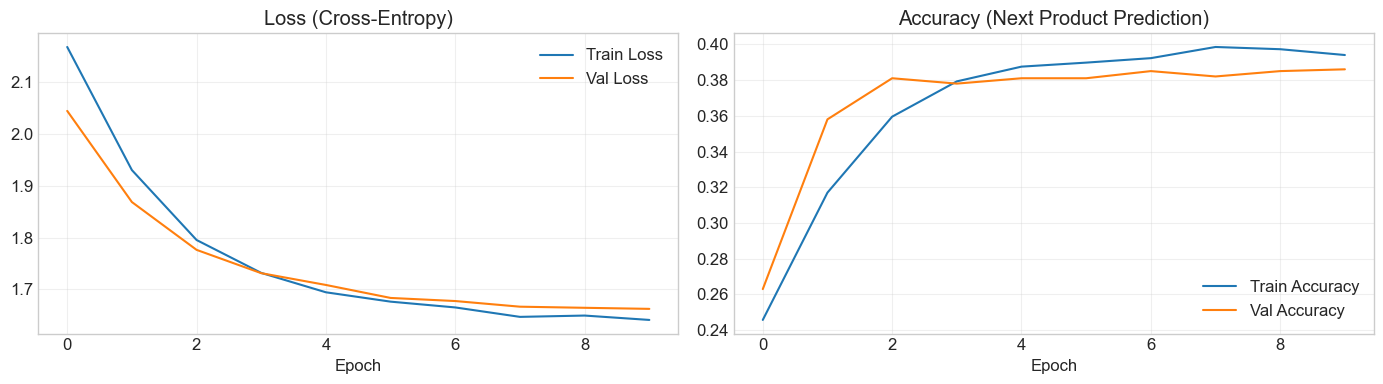


Final Test Accuracy: 0.3860  (random baseline = 0.1000)

Purchase History                                        Actual          Predicted       Correct?
───────────────────────────────────────────────────────────────────────────────────────────────
Mouse → Mouse → Headphones → Tablet → Mouse             Monitor         Headphones      ✗
Stylus → Monitor → Phone → Laptop → Mouse               Headphones      Headphones      ✓
Case → Keyboard → Charger → Mouse → Keyboard            Laptop          Laptop          ✓
Stylus → Case → Keyboard → Phone → Charger              Mouse           Laptop          ✗
Monitor → Mouse → Mouse → Monitor → Mouse               Headphones      Headphones      ✓

What does the LSTM predict after these purchase patterns?

  After [Phone]:
    Case            34.9%
    Keyboard        26.1%
    Charger         21.7%

  After [Phone → Case]:
    Keyboard        67.9%
    Laptop          7.5%
    Tablet          6.3%

  After [Laptop]:
    Stylus          22.4

In [29]:
# 10.7 LSTM — Next Product Prediction (PyTorch)
# Simulates customer purchase sequences and trains an LSTM to predict the next product

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ── Step 1: Simulate customer purchase sequences ──
np.random.seed(42)
NUM_PRODUCTS = 10
PAD_IDX = 0  # 0 = padding, products are 1-10
PRODUCT_NAMES = ['<PAD>', 'Phone', 'Case', 'Charger', 'Headphones', 'Laptop',
                 'Mouse', 'Keyboard', 'Monitor', 'Tablet', 'Stylus']

# Transition matrix (product indices 1-10, mapped to 0-9 internally)
transition = np.random.dirichlet(np.ones(NUM_PRODUCTS) * 0.5, size=NUM_PRODUCTS)
transition[0, 1] = 0.35  # Phone → Case
transition[0, 2] = 0.25  # Phone → Charger
transition[4, 5] = 0.30  # Laptop → Mouse
transition[4, 6] = 0.25  # Laptop → Keyboard
transition[8, 9] = 0.40  # Tablet → Stylus
transition = transition / transition.sum(axis=1, keepdims=True)

sequences = []
for _ in range(5000):
    seq_len = np.random.randint(5, 16)
    seq = [np.random.randint(NUM_PRODUCTS)]
    for _ in range(seq_len - 1):
        seq.append(np.random.choice(NUM_PRODUCTS, p=transition[seq[-1]]))
    # Shift to 1-indexed (0 = padding)
    sequences.append([p + 1 for p in seq])

print(f"Generated {len(sequences)} customer purchase sequences")
print(f"Example: {[PRODUCT_NAMES[p] for p in sequences[0]]}")

# ── Step 2: Prepare PyTorch Dataset ──
MAX_LEN = 14

class PurchaseDataset(Dataset):
    def __init__(self, sequences):
        self.X = []
        self.y = []
        for seq in sequences:
            inp = seq[:-1]  # all but last
            target = seq[-1] - 1  # last product (0-indexed for CrossEntropy)
            # Pad from left
            padded = [PAD_IDX] * (MAX_LEN - len(inp)) + inp
            self.X.append(padded[-MAX_LEN:])  # truncate if too long
            self.y.append(target)
        self.X = torch.tensor(self.X, dtype=torch.long)
        self.y = torch.tensor(self.y, dtype=torch.long)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Split
split = int(0.8 * len(sequences))
train_ds = PurchaseDataset(sequences[:split])
test_ds  = PurchaseDataset(sequences[split:])
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

print(f"Train: {len(train_ds)}, Test: {len(test_ds)}")
print(f"X shape: {train_ds.X.shape}  (batch, seq_len)")

# ── Step 3: Build LSTM Model ──
class NextProductLSTM(nn.Module):
    def __init__(self, num_items, embed_dim=16, hidden_dim=64, num_classes=10):
        super().__init__()
        self.embedding = nn.Embedding(num_items + 1, embed_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden_dim, num_classes)
    
    def forward(self, x):
        emb = self.embedding(x)           # (batch, seq_len, embed_dim)
        _, (h_n, _) = self.lstm(emb)      # h_n: (1, batch, hidden_dim)
        out = self.dropout(h_n.squeeze(0)) # (batch, hidden_dim)
        logits = self.fc(out)             # (batch, num_classes)
        return logits

model = NextProductLSTM(NUM_PRODUCTS).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(f"\nModel:\n{model}")
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

# ── Step 4: Train ──
NUM_EPOCHS = 10
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(NUM_EPOCHS):
    # Training
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct += (logits.argmax(1) == y_batch).sum().item()
        total += len(y_batch)
    train_losses.append(total_loss / total)
    train_accs.append(correct / total)
    
    # Validation
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * len(y_batch)
            correct += (logits.argmax(1) == y_batch).sum().item()
            total += len(y_batch)
    val_losses.append(total_loss / total)
    val_accs.append(correct / total)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:>2}/{NUM_EPOCHS}  "
              f"Train Loss: {train_losses[-1]:.4f}  Acc: {train_accs[-1]:.4f}  "
              f"Val Loss: {val_losses[-1]:.4f}  Acc: {val_accs[-1]:.4f}")

# ── Step 5: Plot training curves ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_title('Loss (Cross-Entropy)')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs, label='Train Accuracy')
axes[1].plot(val_accs, label='Val Accuracy')
axes[1].set_title('Accuracy (Next Product Prediction)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Step 6: Evaluate & show predictions ──
print(f"\nFinal Test Accuracy: {val_accs[-1]:.4f}  (random baseline = {1/NUM_PRODUCTS:.4f})")

model.eval()
X_sample = test_ds.X[:5].to(device)
y_sample = test_ds.y[:5]

with torch.no_grad():
    preds = model(X_sample).softmax(dim=1).cpu().numpy()

print(f"\n{'Purchase History':<55} {'Actual':<15} {'Predicted':<15} {'Correct?'}")
print('─' * 95)
for i in range(5):
    seq = X_sample[i].cpu().numpy()
    actual_seq = [PRODUCT_NAMES[p] for p in seq if p > 0]
    actual_next = PRODUCT_NAMES[y_sample[i].item() + 1]
    pred_next = PRODUCT_NAMES[np.argmax(preds[i]) + 1]
    correct = '✓' if actual_next == pred_next else '✗'
    history_str = ' → '.join(actual_seq[-5:])
    print(f"{history_str:<55} {actual_next:<15} {pred_next:<15} {correct}")

# ── Step 7: What the model learned — top predictions after specific sequences ──
print(f"\n{'='*60}")
print("What does the LSTM predict after these purchase patterns?")
print(f"{'='*60}")

test_patterns = [
    [1],        # Phone
    [1, 2],     # Phone → Case
    [5],        # Laptop
    [5, 6],     # Laptop → Mouse
    [9],        # Tablet
]

for pattern in test_patterns:
    padded = [PAD_IDX] * (MAX_LEN - len(pattern)) + pattern
    x = torch.tensor([padded], dtype=torch.long).to(device)
    with torch.no_grad():
        pred = model(x).softmax(dim=1).cpu().numpy()[0]
    top3_idx = np.argsort(pred)[-3:][::-1]
    top3 = [(PRODUCT_NAMES[i + 1], f"{pred[i]*100:.1f}%") for i in top3_idx]
    pattern_str = ' → '.join([PRODUCT_NAMES[p] for p in pattern])
    print(f"\n  After [{pattern_str}]:")
    for name, prob in top3:
        print(f"    {name:<15} {prob}")

# 11. Model Evaluation & Validation — Across All 5 Families

---

Different model families solve different problems, so they need **different evaluation strategies**. You can't use MAE to evaluate a next-product LSTM, and you can't use Hit Rate to evaluate SARIMA.

---

## 11.1 Time-Aware Train/Test Split

**Critical rule for ALL families:** Never shuffle time series data!

$$\text{Train: } y_1, y_2, \ldots, y_T \qquad \text{Test: } y_{T+1}, y_{T+2}, \ldots, y_{T+h}$$

Common split: 80/20, or hold out the last 1–2 seasonal cycles as test.

For **sequential models** (LSTM, BERT4Rec): split by time — train on earlier interactions, test on later ones. Never let future data leak into training.

---

## 11.2 Metrics by Family

### Family 1 & 2 — Smoothing & Classical (numeric forecasts)

These predict a **number** (e.g., 452 passengers). Use regression metrics:

| Metric | Formula | When to use |
|---|---|---|
| **MAE** | $\frac{1}{n}\sum\|y_t - \hat{y}_t\|$ | General purpose, easy to interpret ("off by X units on average") |
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y_t - \hat{y}_t)^2}$ | When large errors are especially bad (squaring penalizes outliers) |
| **MAPE** | $\frac{100}{n}\sum\left\|\frac{y_t - \hat{y}_t}{y_t}\right\|$ | Scale-independent ("off by X%"). Can't use if $y_t = 0$ |
| **MASE** | $\frac{\text{MAE}}{\text{MAE of naive forecast}}$ | Best overall — MASE < 1 means your model beats the naive baseline |

**Residual diagnostics** (for ARIMA/SARIMA only):
- Plot ACF of residuals — should be within blue bands (no leftover pattern)
- Ljung-Box test — $H_0$: residuals are white noise. p-value > 0.05 = good model
- Q-Q plot — residuals should follow the diagonal (normality check for valid confidence intervals)

### Family 3 — Curve-Fitting (Prophet, VAR)

Same regression metrics (MAE, RMSE, MAPE) as above, plus:

| Metric | What it checks |
|---|---|
| **Coverage** | What % of actual values fall inside the predicted confidence interval? Target: 95% for a 95% CI |
| **Interval Width** | Narrower intervals = more useful. A model that says "between 0 and 1000" is technically correct but useless |
| **Changepoint detection** | Did Prophet detect real trend shifts? Visual check against known events |

### Family 4 — ML Models (XGBoost, Random Forest)

Same regression metrics, plus ML-specific validation:

| Metric / Method | What it checks |
|---|---|
| **Walk-forward validation** | Retrain on expanding window, predict next step, repeat. More robust than a single train/test split |
| **Feature importance** | Which features actually matter? Drop unimportant ones to reduce overfitting |
| **SHAP values** | Explains WHY the model made each prediction, not just overall importance |
| **Out-of-time test** | Train on months 1–100, test on 101–112. Never use random CV for time series! |

### Family 5 — Deep Learning (LSTM, Transformer, BERT4Rec)

These predict a **categorical item** (next product, next movie). Regression metrics don't apply. Use **ranking / classification metrics**:

| Metric | Formula / Meaning | When to use |
|---|---|---|
| **Accuracy** | $\frac{\text{correct predictions}}{\text{total predictions}}$ | Simple but harsh — only counts exact top-1 matches |
| **Hit Rate@K** (HR@K) | Did the actual item appear in the model's top K predictions? | Standard for recommendation. K=10 is common |
| **NDCG@K** | Normalized Discounted Cumulative Gain — rewards correct items ranked higher | When position in the top-K list matters (rank 1 > rank 10) |
| **MRR** | Mean Reciprocal Rank — $\frac{1}{\text{rank of correct item}}$ | "How far down the list did the user have to scroll?" |
| **Cross-Entropy Loss** | $-\sum y_i \log(\hat{y}_i)$ | Training loss — measures how well predicted probabilities match reality |
| **Perplexity** | $e^{\text{cross-entropy}}$ | "How many items is the model confused between?" Lower = better |

**Example:** If the user actually bought "Mouse" and the model's top-5 predictions are [Keyboard, Mouse, Monitor, Charger, Case]:
- Accuracy (top-1) = 0 (Keyboard ≠ Mouse)
- HR@5 = 1 (Mouse is in top 5)
- MRR = 1/2 = 0.5 (Mouse is at rank 2)
- NDCG@5 = higher than if Mouse was at rank 5

---

## 11.3 Validation Strategies by Family

| Strategy | Smoothing / ARIMA | Prophet | XGBoost | LSTM / BERT4Rec |
|---|---|---|---|---|
| **Single train/test** | ✓ (last 12 months) | ✓ | ✓ | ✓ (last N interactions) |
| **Walk-forward** | ✓ (expand window, predict 1) | ✓ | ✓ | Expensive but possible |
| **K-fold CV** | **NO** — breaks time order | **NO** | **NO** — use time-based folds | **NO** |
| **Time-based K-fold** | ✓ (expanding window folds) | ✓ | ✓ | ✓ |
| **Leave-one-out** | Not practical | Not practical | Not practical | ✓ (mask last item per user) |
| **Residual analysis** | ✓ (Ljung-Box, ACF) | Limited | Not standard | Not applicable |
| **AIC / BIC** | ✓ (model comparison) | Not applicable | Not applicable | Not applicable |

### Walk-Forward Validation (Expanding Window)

The most robust method for time series. Used by Families 1–4:

| Fold | Training Data | Test Data |
|---|---|---|
| 1 | $y_1, \ldots, y_{T}$ | $y_{T+1}$ |
| 2 | $y_1, \ldots, y_{T+1}$ | $y_{T+2}$ |
| 3 | $y_1, \ldots, y_{T+2}$ | $y_{T+3}$ |
| ... | ... | ... |

Retrain the model at each fold → simulates real-world deployment where you retrain periodically.

---

## 11.4 Common Pitfalls

| Pitfall | Families affected | What goes wrong |
|---|---|---|
| **Shuffling data** | All | Future data leaks into training → overly optimistic results |
| **Using random K-fold CV** | All | Same as shuffling — folds mix past and future |
| **Evaluating on fitted values** | Smoothing, ARIMA | Fitted values use actual data → looks great, but forecast might be flat/terrible |
| **Ignoring residuals** | ARIMA, SARIMA | Model might have significant ACF in residuals → missed patterns → unreliable CIs |
| **Only looking at MAE** | ML, DL | Model might have low MAE but terrible coverage (confidence intervals too narrow) |
| **Not comparing to a baseline** | All | A model with MAE=20 seems good until you realize "repeat last value" gives MAE=15 |
| **Using accuracy for recommendations** | LSTM, BERT4Rec | Accuracy is too harsh — HR@10 is more realistic (did the item appear in top 10?) |

---

## 11.5 Baselines to Always Compare Against

Before celebrating your model's performance, check if it actually beats these dead-simple baselines:

| Baseline | How it works | Use for |
|---|---|---|
| **Naive (last value)** | $\hat{y}_{T+1} = y_T$ | Numeric forecasting |
| **Seasonal naive** | $\hat{y}_{T+1} = y_{T+1-m}$ (same month last year) | Seasonal data |
| **Mean forecast** | $\hat{y} = \bar{y}$ | Stable data |
| **Most popular item** | Always predict the most frequently purchased item | Recommendation |
| **Random** | Predict a random item | Recommendation (lower bound) |

**If your fancy LSTM can't beat "most popular item," something is wrong with your model, not with the baseline.**

# Summary & Comparison — All 5 Families

---


## Complete Model Reference

| Model | Family | Handles Trend | Handles Seasonality | Multiple Seasons | Holidays | External Vars | Confidence Intervals | Multivariate | Stationarity Needed | Data Needed | Complexity |
|---|---|---|---|---|---|---|---|---|---|---|---|
| SMA | 1. Smoothing | No | No | No | No | No | No | No | No | Little | Very Low |
| WMA | 1. Smoothing | No | No | No | No | No | No | No | No | Little | Very Low |
| SES | 1. Smoothing | No | No | No | No | No | No | No | No | Little | Low |
| Holt's | 1. Smoothing | Yes | No | No | No | No | No | No | No | Little | Low |
| Holt-Winters | 1. Smoothing | Yes | Yes | No | No | No | No | No | No | 1 year | Medium |
| AR(p) | 2. Classical | No | No | No | No | No | Yes | No | Yes | Moderate | Medium |
| MA(q) | 2. Classical | No | No | No | No | No | Yes | No | Yes | Moderate | Medium |
| ARMA(p,q) | 2. Classical | No | No | No | No | No | Yes | No | Yes | Moderate | Medium |
| ARIMA(p,d,q) | 2. Classical | Yes (via d) | No | No | No | ARIMAX | Yes | No | No (d handles it) | Moderate | Medium |
| SARIMA | 2. Classical | Yes | Yes | No | No | SARIMAX | Yes | No | No (d,D handle it) | 2+ cycles | High |
| VAR | 3. Curve-Fitting | Yes | No | No | No | Yes | Yes | **Yes** | Yes | Moderate | Medium |
| Prophet | 3. Curve-Fitting | Yes | Yes | **Yes** | **Yes** | Yes | Yes (Bayesian) | No | No | Moderate | Low |
| Random Forest | 4. ML | Yes (via features) | Yes (via features) | Yes (via features) | Yes (via features) | Yes | No | Yes | No | Hundreds | Medium |
| XGBoost | 4. ML | Yes (via features) | Yes (via features) | Yes (via features) | Yes (via features) | Yes | No | Yes | No | Hundreds | Medium |
| LSTM | 5. Deep Learning | Yes | Yes | Yes | Can learn | Yes | Some | Yes | No | Thousands | High |
| GRU | 5. Deep Learning | Yes | Yes | Yes | Can learn | Yes | Some | Yes | No | Thousands | High |
| Transformer | 5. Deep Learning | Yes | Yes | Yes | Can learn | Yes | Some (TFT) | Yes | No | Thousands | Very High |
| BERT4Rec | 5. Deep Learning | N/A | N/A | N/A | N/A | N/A | No | Yes | No | Thousands | Very High |

## When to Use What — Quick Reference

| Your Situation | Best Choice | Why |
|---|---|---|
| Quick baseline, any data | **Holt-Winters** | 2 lines of code, handles trend + seasonality |
| Need confidence intervals | **SARIMA** | Built-in prediction intervals + residual diagnostics |
| Multiple seasonalities (daily + weekly + yearly) | **Prophet** | Built for this — Fourier terms handle any number of seasonal periods |
| Holidays matter (Christmas, Black Friday) | **Prophet** | Just pass a holiday dataframe |
| External variables (weather, promotions) | **XGBoost** | Add any column as a feature — infinitely flexible |
| Messy data with missing values | **Prophet** | Handles gaps gracefully |
| Categorical sequences (next product, next movie) | **LSTM / BERT4Rec** | Embedding + sequential architecture — can't do this with ARIMA or XGBoost |
| 100K+ rows or many related series | **LSTM / Transformer** | Learns cross-series patterns, scales with data |
| Less than 2 years of monthly data | **Holt-Winters** | SARIMA and Prophet need more data |
| Need to explain to a non-technical stakeholder | **Holt-Winters** | "Weighted average of trend and season" — easy |
| Publishing a paper, need rigor | **SARIMA** | Ljung-Box test, AIC/BIC, residual diagnostics |

## Recommended Workflow

```
1. Visualize — EDA, decomposition, check additive vs multiplicative
                    ↓
2. Test stationarity — ADF + KPSS tests
                    ↓
3. Start simple — Naive baseline, then Holt-Winters
                    ↓
4. Try SARIMA — Use ACF/PACF or auto_arima
                    ↓
5. Try curve-fitting — Prophet (if holidays/multiple seasons)
                    ↓
6. Try ML — XGBoost with engineered features (if external variables)
                    ↓
7. Try Deep Learning — LSTM/Transformer (if lots of data or sequential items)
                    ↓
8. Evaluate — Walk-forward validation, residual analysis, compare to baselines
                    ↓
9. Pick the winner — Lowest MAE/RMSE on test set that also passes residual checks
```

> *"All models are wrong, but some are useful."* — George Box